# Análisis Exploratorio de Datos (EDA) - Dataset OLIST

## Sistema de Recomendación Item-to-Item para E-Commerce

**Proyecto:** VERTEX INSIGHTS - Sistema de recomendación para marketplace brasileño Olist  
**Historia de Usuario:** HU-05 - Realizar el análisis exploratorio de datos sobre Olist  
**Fecha:** Junio 2026  
**Responsable:** Data Analyst  

---

## Objetivo del EDA

Realizar un análisis exploratorio profundo del dataset OLIST consolidado para:

1. **Identificar patrones** en el comportamiento de clientes y productos
2. **Detectar problemas de calidad** en los datos (nulos, outliers, inconsistencias)
3. **Analizar sparsity** de la matriz cliente-producto (crítico para arquitectura item-to-item)
4. **Evaluar viabilidad** de los dos canales de recomendación:
   - Canal A: Productos similares (content-based)
   - Canal B: Productos comprados juntos (collaborative filtering)
5. **Documentar hallazgos** que informen decisiones de feature engineering (HU-07)

---

## Estructura del Análisis

Este notebook sigue las 10 fases definidas en el plan de EDA:

- **Fase 1:** Configuración y carga inicial
- **Fase 2:** Inspección inicial de datos
- **Fase 3:** Análisis univariable
- **Fase 4:** Análisis bivariable
- **Fase 5:** Análisis multivariable y temporal
- **Fase 6:** Análisis crítico de sparsity (mandatorio)
- **Fase 7:** Análisis para collaborative filtering
- **Fase 8:** Análisis para content-based filtering
- **Fase 9:** Consolidación de problemas de calidad
- **Fase 10:** Documentación de hallazgos

---

## FASE 1: Configuración y Carga Inicial

⏱️ **Tiempo estimado:** 30 minutos

Configuración del entorno de análisis y carga del dataset consolidado.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from pathlib import Path
from datetime import datetime

# Configuración de visualizaciones
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración de Plotly
import plotly.io as pio
pio.templates.default = "plotly_white"

print("✓ Librerías importadas correctamente")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ NumPy version: {np.__version__}")

✓ Librerías importadas correctamente
✓ Pandas version: 2.3.3
✓ NumPy version: 2.4.6


In [2]:
# Configuración de rutas
PROJECT_ROOT = Path.cwd().parent
DATA_FILE = PROJECT_ROOT / "olist_consolidated.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"

# Verificar que existe el archivo de datos
if not DATA_FILE.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {DATA_FILE}")

print(f"✓ Archivo de datos encontrado: {DATA_FILE}")
print(f"✓ Carpeta de figuras: {FIGURES_DIR}")

✓ Archivo de datos encontrado: c:\Users\juanc\OneDrive\Documentos\JUAN CARLOS\ESTUDIOS\CIENCIA DE DATOS\PROYECTO FINAL VERTEX INSIGHT\MLops_Pipeline_VERTEX\olist_consolidated.csv
✓ Carpeta de figuras: c:\Users\juanc\OneDrive\Documentos\JUAN CARLOS\ESTUDIOS\CIENCIA DE DATOS\PROYECTO FINAL VERTEX INSIGHT\MLops_Pipeline_VERTEX\reports\figures\eda


In [3]:
# Cargar el dataset consolidado
print("Cargando dataset consolidado...")
df = pd.read_csv(DATA_FILE)

# Validación inicial
EXPECTED_ORDERS = 99441
actual_orders = len(df)

print(f"\n{'='*70}")
print(f"DATASET CARGADO CORRECTAMENTE")
print(f"{'='*70}")
print(f"  Órdenes esperadas: {EXPECTED_ORDERS:,}")
print(f"  Órdenes cargadas:  {actual_orders:,}")
print(f"  Columnas:          {len(df.columns)}")
print(f"  Tamaño en memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# Verificar integridad
if actual_orders == EXPECTED_ORDERS:
    print(f"\n✓ Integridad validada: {actual_orders:,} órdenes únicas")
else:
    print(f"\n⚠️ Advertencia: Se esperaban {EXPECTED_ORDERS:,} órdenes, se cargaron {actual_orders:,}")

print(f"{'='*70}\n")

Cargando dataset consolidado...

DATASET CARGADO CORRECTAMENTE
  Órdenes esperadas: 99,441
  Órdenes cargadas:  99,441
  Columnas:          58
  Tamaño en memoria: 186.91 MB

✓ Integridad validada: 99,441 órdenes únicas



## FASE 2: Inspección Inicial de Datos

⏱️ **Tiempo estimado:** 1 hora

Análisis de la estructura, tipos de datos y calidad inicial del dataset.

### 2.1. Dimensiones y Tipos de Datos

In [4]:
# Vista general del dataset
print("="*70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*70)
print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria total: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB\n")

# Información de tipos de datos
print("\nTIPOS DE DATOS:")
print("-"*70)
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"  {dtype}: {count} columnas")

# Mostrar primeras filas
print("\n" + "="*70)
print("PRIMERAS 5 FILAS DEL DATASET")
print("="*70)
df.head()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 99,441 filas × 58 columnas
Memoria total: 186.91 MB


TIPOS DE DATOS:
----------------------------------------------------------------------
  float64: 28 columnas
  object: 23 columnas
  int64: 7 columnas

PRIMERAS 5 FILAS DEL DATASET


,order_id,customer_id,customer_unique_id,primary_product_id,primary_seller_id,review_score,bad_review,has_review,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,late_delivery,approval_to_carrier_days,transit_days,purchase_month,purchase_year,purchase_weekday,total_items,unique_products,unique_sellers,total_price,avg_item_price,min_item_price,max_item_price,price_per_item,total_freight,avg_freight,freight_percentage,total_payment_value,primary_payment_type,num_payment_methods,avg_installments,uses_installments,customer_zip,customer_city,customer_state,product_category,product_category_english,product_name_length,product_description_length,product_photos_qty,product_weight_grams,product_length_cm,product_height_cm,product_width_cm,seller_zip,seller_city,seller_state,review_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,4.00,0.00,1,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.00,-8.00,0,2.00,6.00,10,2017,0,1.00,1.00,1.00,29.99,29.99,29.99,29.99,29.99,8.72,8.72,22.53,38.71,voucher,3.00,1.00,0,3149,sao paulo,SP,utilidades_domesticas,housewares,40.00,268.00,4.00,500.00,19.00,8.00,13.00,9350.00,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,4.00,0.00,1,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.00,-6.00,0,0.00,12.00,7,2018,1,1.00,1.00,1.00,118.70,118.70,118.70,118.70,118.70,22.76,22.76,16.09,141.46,boleto,1.00,1.00,0,47813,barreiras,BA,perfumaria,perfumery,29.00,178.00,1.00,400.00,19.00,13.00,19.00,31570.00,belo horizonte,SP,8d5266042046a06655c8db133d120ba5,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,5.00,0.00,1,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.00,-18.00,0,0.00,9.00,8,2018,2,1.00,1.00,1.00,159.90,159.90,159.90,159.90,159.90,19.22,19.22,10.73,179.12,credit_card,1.00,3.00,1,75265,vianopolis,GO,automotivo,auto,46.00,232.00,1.00,420.00,24.00,19.00,21.00,14840.00,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,5.00,0.00,1,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.00,-13.00,0,3.00,9.00,11,2017,5,1.00,1.00,1.00,45.00,45.00,45.00,45.00,45.00,27.20,27.20,37.67,72.20,credit_card,1.00,1.00,0,59296,sao goncalo do amarante,RN,pet_shop,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,31842.00,belo horizonte,MG,359d03e676b3c069f62cadba8dd3f6e8,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,5.00,0.00,1,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.00,-10.00,0,0.00,1.00,2,2018,1,1.00,1.00,1.00,19.90,19.90,19.90,19.90,19.90,8.72,8.72,30.47,28.62,credit_card,1.00,1.00,0,9195,santo andre,SP,papelaria,stationery,38.00,316.00,4.00,250.00,51.00,15.0

### 2.2. Análisis de Valores Faltantes

**Crítico para rúbrica:** Identificar y cuantificar problemas de calidad de datos.

In [5]:
# Calcular porcentaje de valores faltantes
missing_data = pd.DataFrame({
    'columna': df.columns,
    'nulos': df.isnull().sum(),
    'porcentaje': (df.isnull().sum() / len(df)) * 100
})

# Filtrar solo columnas con valores faltantes
missing_data = missing_data[missing_data['nulos'] > 0].sort_values('porcentaje', ascending=False)

print("="*70)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*70)
print(f"\nColumnas con valores faltantes: {len(missing_data)}/{len(df.columns)}")
print(f"Total de valores faltantes: {df.isnull().sum().sum():,}")
print(f"Porcentaje global de nulos: {(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%\n")

if len(missing_data) > 0:
    print("\nTop 20 columnas con más valores faltantes:")
    print("-"*70)
    display(missing_data.head(20))
else:
    print("\n✓ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

Columnas con valores faltantes: 43/58
Total de valores faltantes: 192,552
Porcentaje global de nulos: 3.34%


Top 20 columnas con más valores faltantes:
----------------------------------------------------------------------


,columna,nulos,porcentaje
review_comment_title,review_comment_title,87890,88.38
review_comment_message,review_comment_message,58656,58.99
transit_days,transit_days,2966,2.98
delivery_delay_days,delivery_delay_days,2965,2.98
delivery_days,delivery_days,2965,2.98
order_delivered_customer_date,order_delivered_customer_date,2965,2.98
product_category_english,product_category_english,2217,2.23
product_category,product_category,2195,2.21
product_photos_qty,product_photos_qty,2195,2.21
product_description_length,product_description_length,2195,2.21


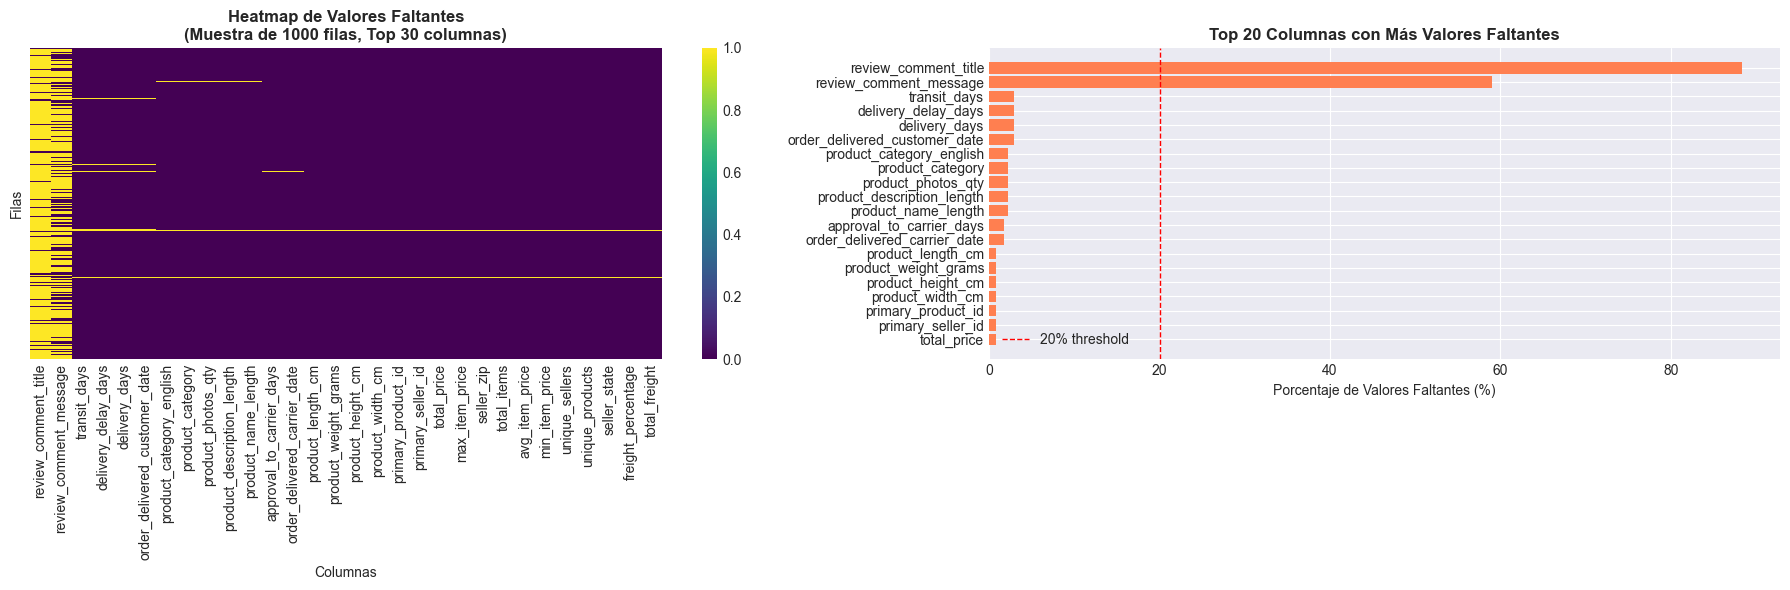


✓ Visualización guardada: 01_valores_faltantes.png


In [6]:
# Visualización: Heatmap de valores faltantes (primeras 1000 filas para visualización)
if len(missing_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Heatmap de nulos (muestra de 1000 filas)
    sample_size = min(1000, len(df))
    cols_with_nulls = missing_data['columna'].tolist()[:30]  # Top 30 columnas con nulos
    
    if cols_with_nulls:
        sns.heatmap(df[cols_with_nulls].head(sample_size).isnull(), 
                    cmap='viridis', 
                    cbar=True, 
                    yticklabels=False,
                    ax=axes[0])
        axes[0].set_title(f'Heatmap de Valores Faltantes\n(Muestra de {sample_size} filas, Top 30 columnas)', 
                         fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Columnas')
        axes[0].set_ylabel('Filas')
    
    # Gráfico de barras: Top 20 columnas con más nulos
    top_20_missing = missing_data.head(20)
    axes[1].barh(top_20_missing['columna'], top_20_missing['porcentaje'], color='coral')
    axes[1].set_xlabel('Porcentaje de Valores Faltantes (%)', fontsize=10)
    axes[1].set_title('Top 20 Columnas con Más Valores Faltantes', fontsize=12, fontweight='bold')
    axes[1].axvline(x=20, color='red', linestyle='--', linewidth=1, label='20% threshold')
    axes[1].legend()
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_valores_faltantes.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 01_valores_faltantes.png")
else:
    print("No hay valores faltantes para visualizar")

### 2.3. Verificación de Duplicados

In [7]:
# Verificar unicidad de order_id (debe ser 100% único por diseño)
print("="*70)
print("ANÁLISIS DE DUPLICADOS")
print("="*70)

order_id_unique = df['order_id'].nunique()
order_id_total = len(df)
order_id_duplicates = order_id_total - order_id_unique

print(f"\n1. order_id (PK del dataset consolidado):")
print(f"   Total registros: {order_id_total:,}")
print(f"   Valores únicos: {order_id_unique:,}")
print(f"   Duplicados: {order_id_duplicates:,}")

if order_id_duplicates == 0:
    print("   ✓ Sin duplicados - Integridad confirmada")
else:
    print(f"   ⚠️ Advertencia: {order_id_duplicates:,} órdenes duplicadas")

# Verificar customer_unique_id (esperado: mayoría con 1 sola compra)
customer_orders = df['customer_unique_id'].value_counts()
customers_total = df['customer_unique_id'].nunique()
customers_one_order = (customer_orders == 1).sum()
customers_recurrent = (customer_orders > 1).sum()

print(f"\n2. customer_unique_id (Comportamiento de clientes):")
print(f"   Total clientes únicos: {customers_total:,}")
print(f"   Clientes con 1 sola compra: {customers_one_order:,} ({customers_one_order/customers_total*100:.1f}%)")
print(f"   Clientes recurrentes (>1 compra): {customers_recurrent:,} ({customers_recurrent/customers_total*100:.1f}%)")
print(f"   Máximo de compras por cliente: {customer_orders.max()}")

print("\n" + "="*70)

ANÁLISIS DE DUPLICADOS

1. order_id (PK del dataset consolidado):
   Total registros: 99,441
   Valores únicos: 99,441
   Duplicados: 0
   ✓ Sin duplicados - Integridad confirmada

2. customer_unique_id (Comportamiento de clientes):
   Total clientes únicos: 96,096
   Clientes con 1 sola compra: 93,099 (96.9%)
   Clientes recurrentes (>1 compra): 2,997 (3.1%)
   Máximo de compras por cliente: 17



## FASE 3: Análisis Univariable

⏱️ **Tiempo estimado:** 3 horas

Análisis detallado de distribuciones y características individuales de cada tipo de variable.

### 3.1. Variables Numéricas Clave

**Enfoque:** Distribuciones, centralidad, dispersión, outliers.  
**Relevancia para recomendación:** Entender rangos de precio, frecuencia de compra, satisfacción.

In [8]:
# Seleccionar variables numéricas clave para análisis
numeric_cols = [
    'total_items',           # Cantidad de ítems por orden
    'total_price',           # Precio total de la orden
    'total_freight',         # Costo de envío
    'total_payment_value',   # Pago total
    'review_score',          # Satisfacción (1-5)
    'delivery_days',         # Días de entrega
    'delivery_delay_days',   # Retraso en días
    'product_weight_grams',  # Peso del producto principal
    'product_length_cm',     # Dimensiones
    'product_height_cm',
    'product_width_cm'
]

# Verificar cuáles existen en el dataset
numeric_cols_available = [col for col in numeric_cols if col in df.columns]

print("="*70)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS CLAVE")
print("="*70)
print(f"\nVariables analizadas: {len(numeric_cols_available)}\n")

# Estadísticas detalladas
stats = df[numeric_cols_available].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
display(stats.round(2))

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS CLAVE

Variables analizadas: 11



,total_items,total_price,total_freight,total_payment_value,review_score,delivery_days,delivery_delay_days,product_weight_grams,product_length_cm,product_height_cm,product_width_cm
count,98666.00,98666.00,98666.00,99440.00,98673.00,96476.00,96476.00,98650.00,98650.00,98650.00,98650.00
mean,1.14,137.75,22.82,160.99,4.09,12.09,-11.88,2101.18,30.10,16.48,23.02
std,0.54,210.65,21.65,221.95,1.35,9.55,10.18,3763.20,16.13,13.31,11.75
min,1.00,0.85,0.00,0.00,1.00,0.00,-147.00,0.00,7.00,2.00,6.00
1%,1.00,11.98,7.39,22.38,1.00,1.00,-36.00,75.00,16.00,2.00,11.00
5%,1.00,19.00,7.88,32.38,1.00,3.00,-26.00,125.00,16.00,3.00,11.00
25%,1.00,45.90,13.85,62.01,4.00,6.00,-17.00,300.00,18.00,8.00,15.00
50%,1.00,86.90,17.17,105.29,5.00,10.00,-12.00,700.00,25.00,13.00,20.00
75%,1.00,149.90,24.04,176.97,5.00,15.00,-7.00,1800.00,38.00,20.00,30.00
95%,2.00,399.90,54.96,452.99,5.00,29.00,3.00,9750.00,62.00,44.00,45.00


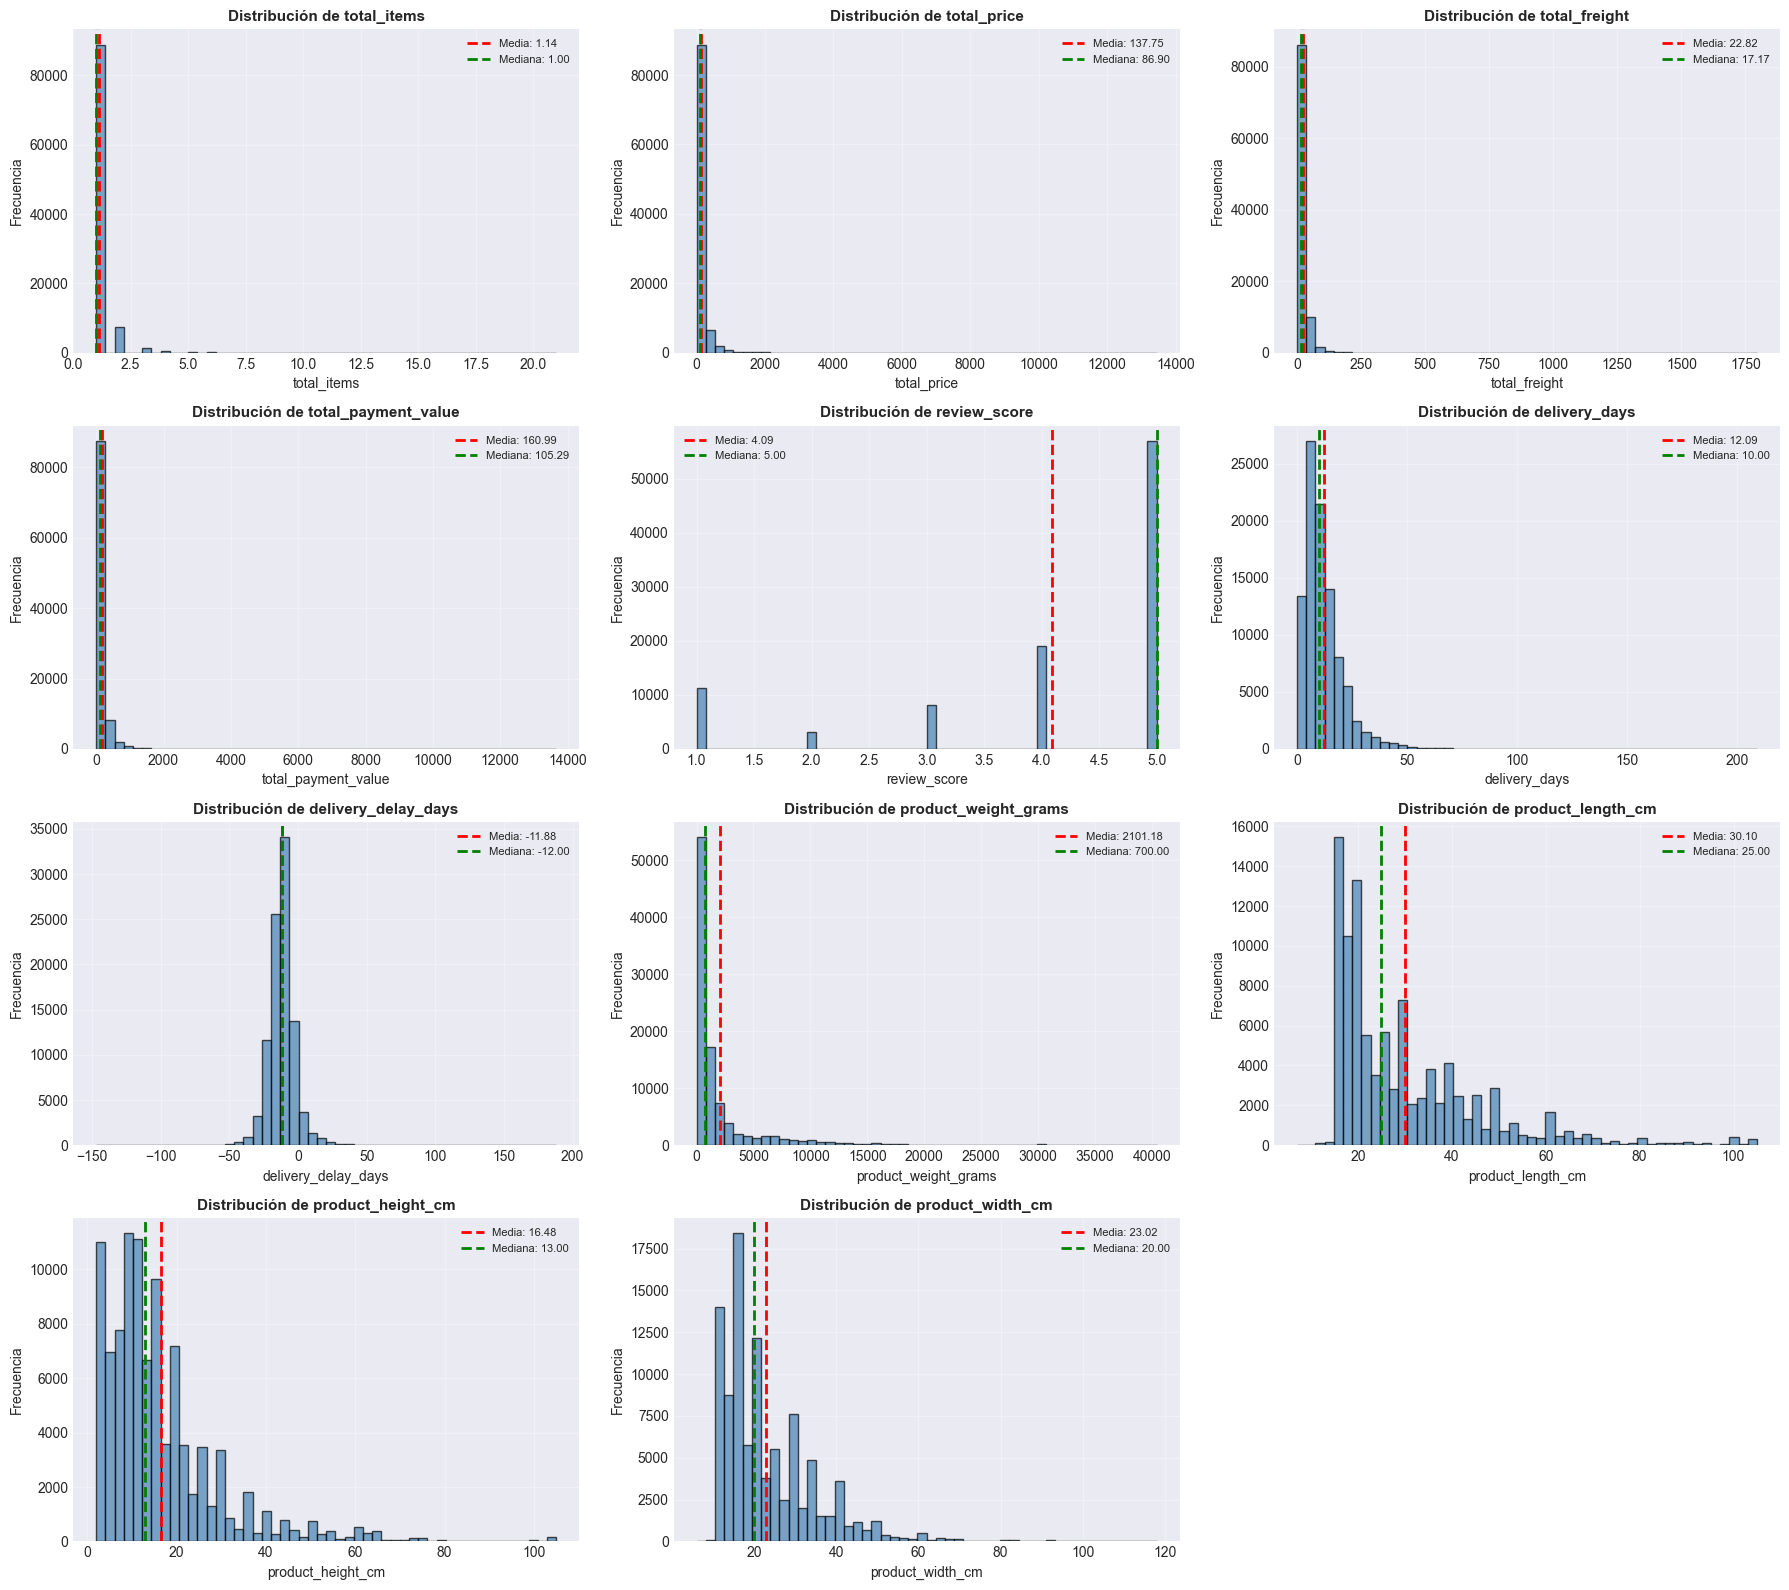


✓ Visualización guardada: 02_histogramas_numericas.png


In [9]:
# Visualización: Histogramas de variables numéricas clave
n_cols = 3
n_rows = (len(numeric_cols_available) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, col in enumerate(numeric_cols_available):
    ax = axes[idx]
    
    # Datos sin nulos
    data = df[col].dropna()
    
    # Histograma con KDE
    ax.hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
    
    # Añadir estadísticas
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes
for idx in range(len(numeric_cols_available), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_histogramas_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: 02_histogramas_numericas.png")

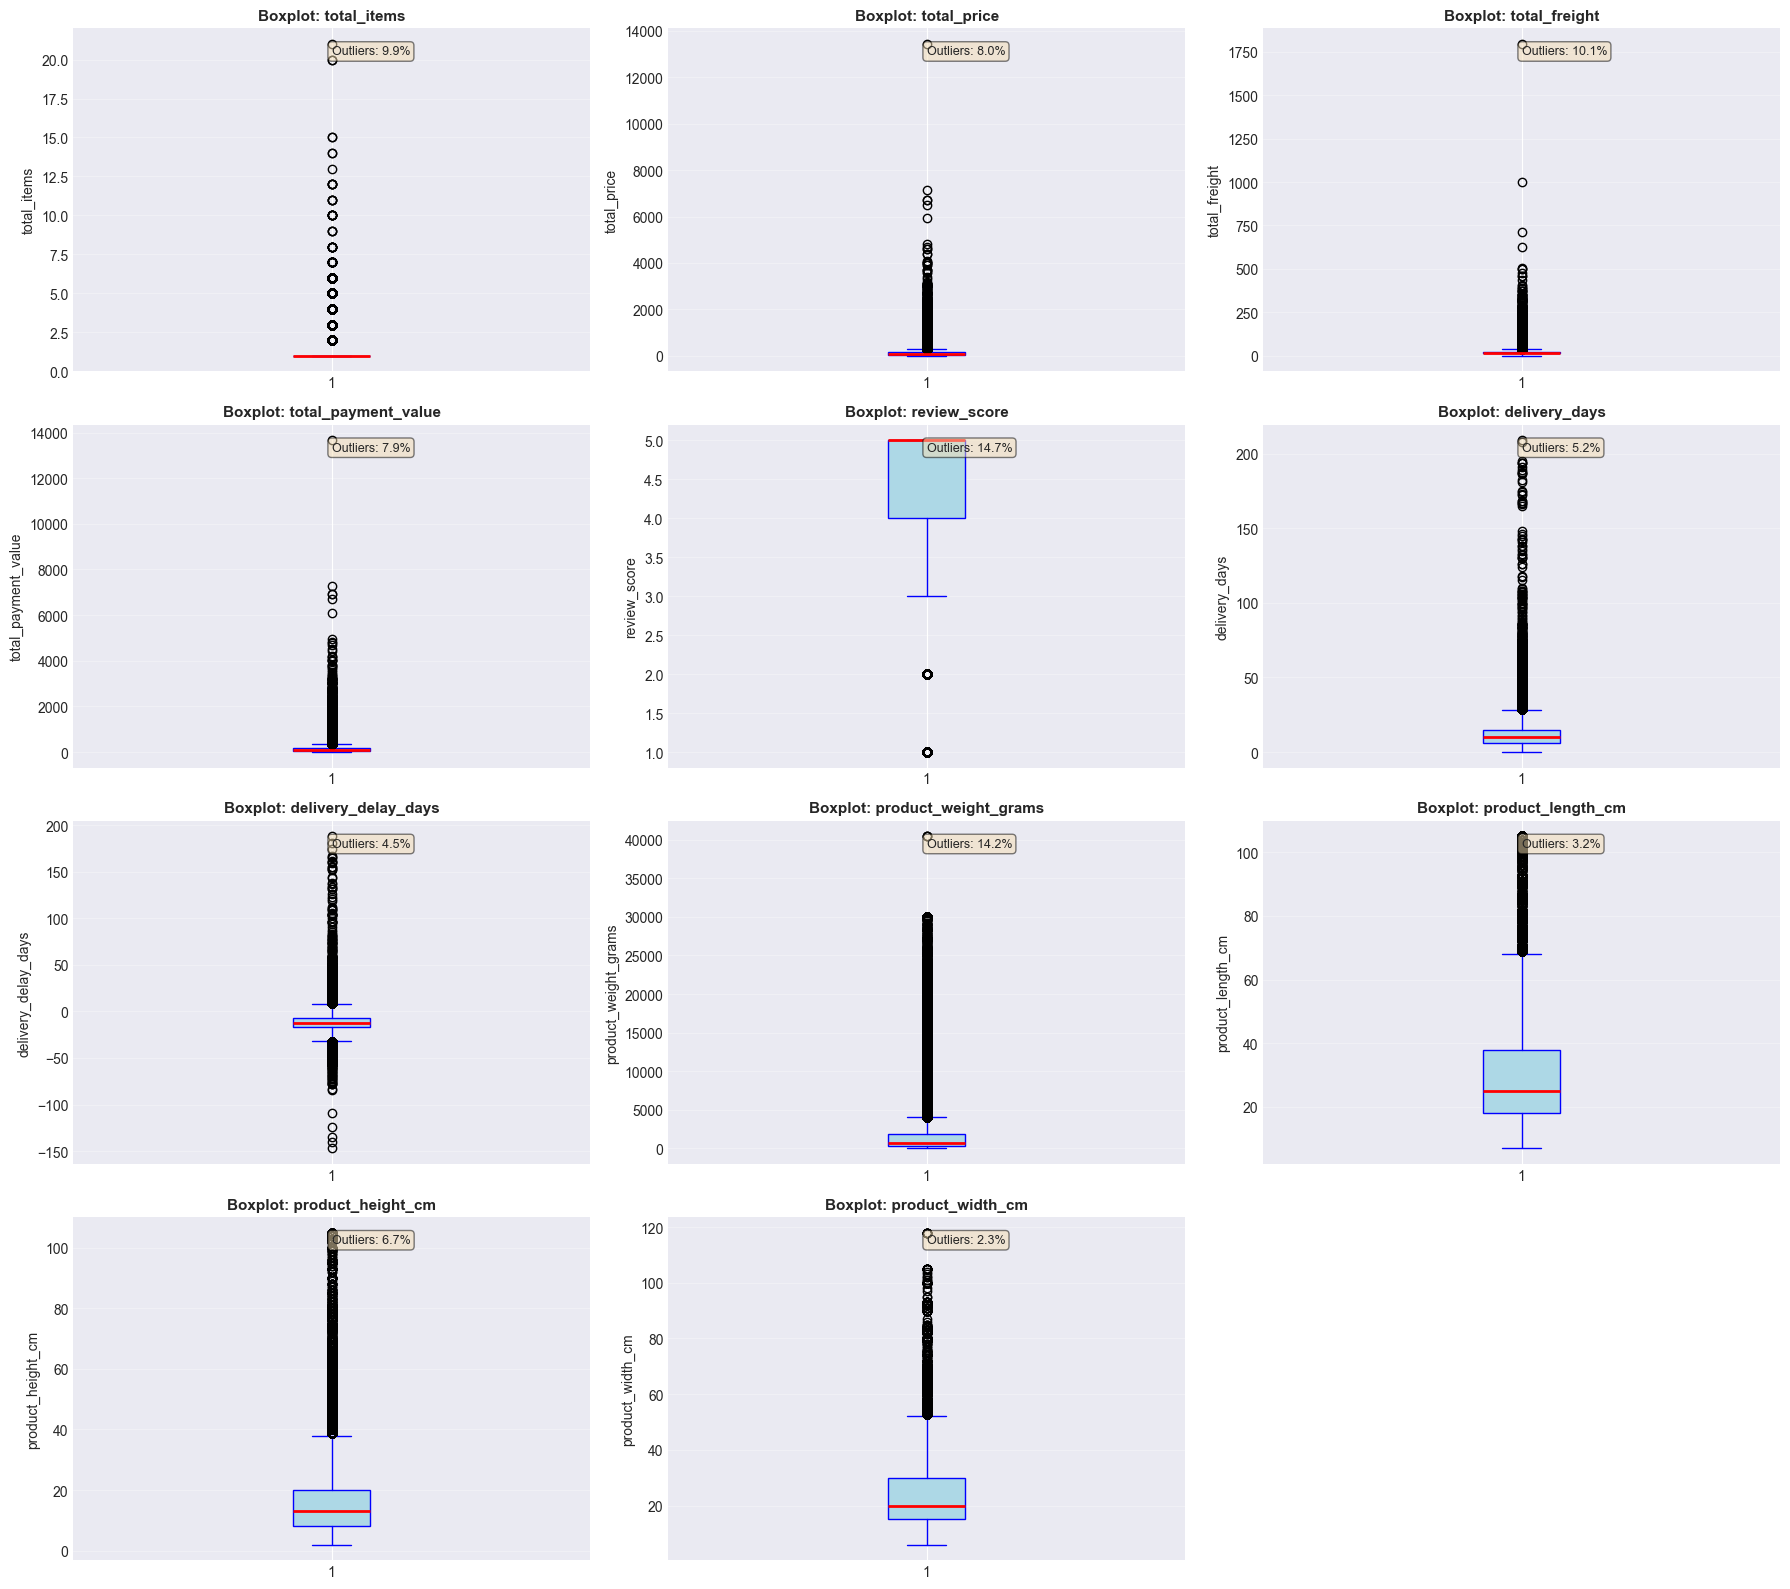


✓ Visualización guardada: 03_boxplots_numericas.png


In [10]:
# Visualización: Boxplots para detectar outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, col in enumerate(numeric_cols_available):
    ax = axes[idx]
    
    # Datos sin nulos
    data = df[col].dropna()
    
    # Boxplot
    bp = ax.boxplot(data, vert=True, patch_artist=True, 
                    boxprops=dict(facecolor='lightblue', color='blue'),
                    whiskerprops=dict(color='blue'),
                    capprops=dict(color='blue'),
                    medianprops=dict(color='red', linewidth=2))
    
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    
    # Calcular porcentaje de outliers
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_pct = (len(outliers) / len(data)) * 100
    
    ax.text(0.5, 0.95, f'Outliers: {outlier_pct:.1f}%', 
            transform=ax.transAxes, fontsize=9, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Ocultar ejes sobrantes
for idx in range(len(numeric_cols_available), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_boxplots_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: 03_boxplots_numericas.png")

### 3.2. Variables Categóricas Clave

**Enfoque:** Frecuencias, distribuciones, concentración.  
**Relevancia para recomendación:** Identificar categorías populares, métodos de pago comunes, patrones geográficos.

In [11]:
# Seleccionar variables categóricas clave
categorical_cols = [
    'product_category_english',  # Categoría del producto principal
    'order_status',                    # Estado de la orden
    'primary_payment_type',            # Método de pago más usado
    'customer_state',                  # Estado del cliente
    'seller_state'                     # Estado del vendedor
]

# Verificar cuáles existen
categorical_cols_available = [col for col in categorical_cols if col in df.columns]

print("="*70)
print("ANÁLISIS DE FRECUENCIAS - VARIABLES CATEGÓRICAS CLAVE")
print("="*70)

for col in categorical_cols_available:
    print(f"\n{'='*70}")
    print(f"Variable: {col}")
    print(f"{'='*70}")
    
    # Value counts
    value_counts = df[col].value_counts()
    value_counts_pct = df[col].value_counts(normalize=True) * 100
    
    # Crear tabla combinada (Top 15)
    freq_table = pd.DataFrame({
        'Frecuencia': value_counts.head(15),
        'Porcentaje (%)': value_counts_pct.head(15).round(2)
    })
    
    print(f"Total de categorías únicas: {df[col].nunique()}")
    print(f"Valores nulos: {df[col].isnull().sum()} ({df[col].isnull().sum()/len(df)*100:.2f}%)")
    print(f"\nTop 15 más frecuentes:")
    display(freq_table)
    
    # Concentración (Top 5, Top 10, Top 20)
    top5_pct = value_counts_pct.head(5).sum()
    top10_pct = value_counts_pct.head(10).sum()
    top20_pct = value_counts_pct.head(20).sum()
    
    print(f"\nConcentración:")
    print(f"  - Top 5: {top5_pct:.2f}%")
    print(f"  - Top 10: {top10_pct:.2f}%")
    print(f"  - Top 20: {top20_pct:.2f}%")

ANÁLISIS DE FRECUENCIAS - VARIABLES CATEGÓRICAS CLAVE

Variable: product_category_english
Total de categorías únicas: 71
Valores nulos: 2217 (2.23%)

Top 15 más frecuentes:


,Frecuencia,Porcentaje (%)
product_category_english,,
bed_bath_table,9301,9.57
health_beauty,8803,9.05
sports_leisure,7681,7.90
computers_accessories,6659,6.85
furniture_decor,6358,6.54
housewares,5820,5.99
watches_gifts,5607,5.77
telephony,4189,4.31
auto,3878,3.99



Concentración:
  - Top 5: 39.91%
  - Top 10: 63.92%
  - Top 20: 88.38%

Variable: order_status
Total de categorías únicas: 8
Valores nulos: 0 (0.00%)

Top 15 más frecuentes:


,Frecuencia,Porcentaje (%)
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00



Concentración:
  - Top 5: 99.69%
  - Top 10: 100.00%
  - Top 20: 100.00%

Variable: primary_payment_type
Total de categorías únicas: 5
Valores nulos: 1 (0.00%)

Top 15 más frecuentes:


...


Concentración:
  - Top 5: 100.00%
  - Top 10: 100.00%
  - Top 20: 100.00%

Variable: customer_state
Total de categorías únicas: 27
Valores nulos: 0 (0.00%)

Top 15 más frecuentes:


,Frecuencia,Porcentaje (%)
customer_state,,
SP,41746,41.98
RJ,12852,12.92
MG,11635,11.70
RS,5466,5.50
PR,5045,5.07
SC,3637,3.66
BA,3380,3.40
DF,2140,2.15
ES,2033,2.04



Concentración:
  - Top 5: 77.18%
  - Top 10: 90.46%
  - Top 20: 98.77%

Variable: seller_state
Total de categorías únicas: 23
Valores nulos: 775 (0.78%)

Top 15 más frecuentes:


,Frecuencia,Porcentaje (%)
seller_state,,
SP,69972,70.92
MG,7862,7.97
PR,7593,7.70
RJ,4299,4.36
SC,3611,3.66
RS,1969,2.00
DF,820,0.83
BA,567,0.57
GO,461,0.47



Concentración:
  - Top 5: 94.60%
  - Top 10: 98.88%
  - Top 20: 99.99%


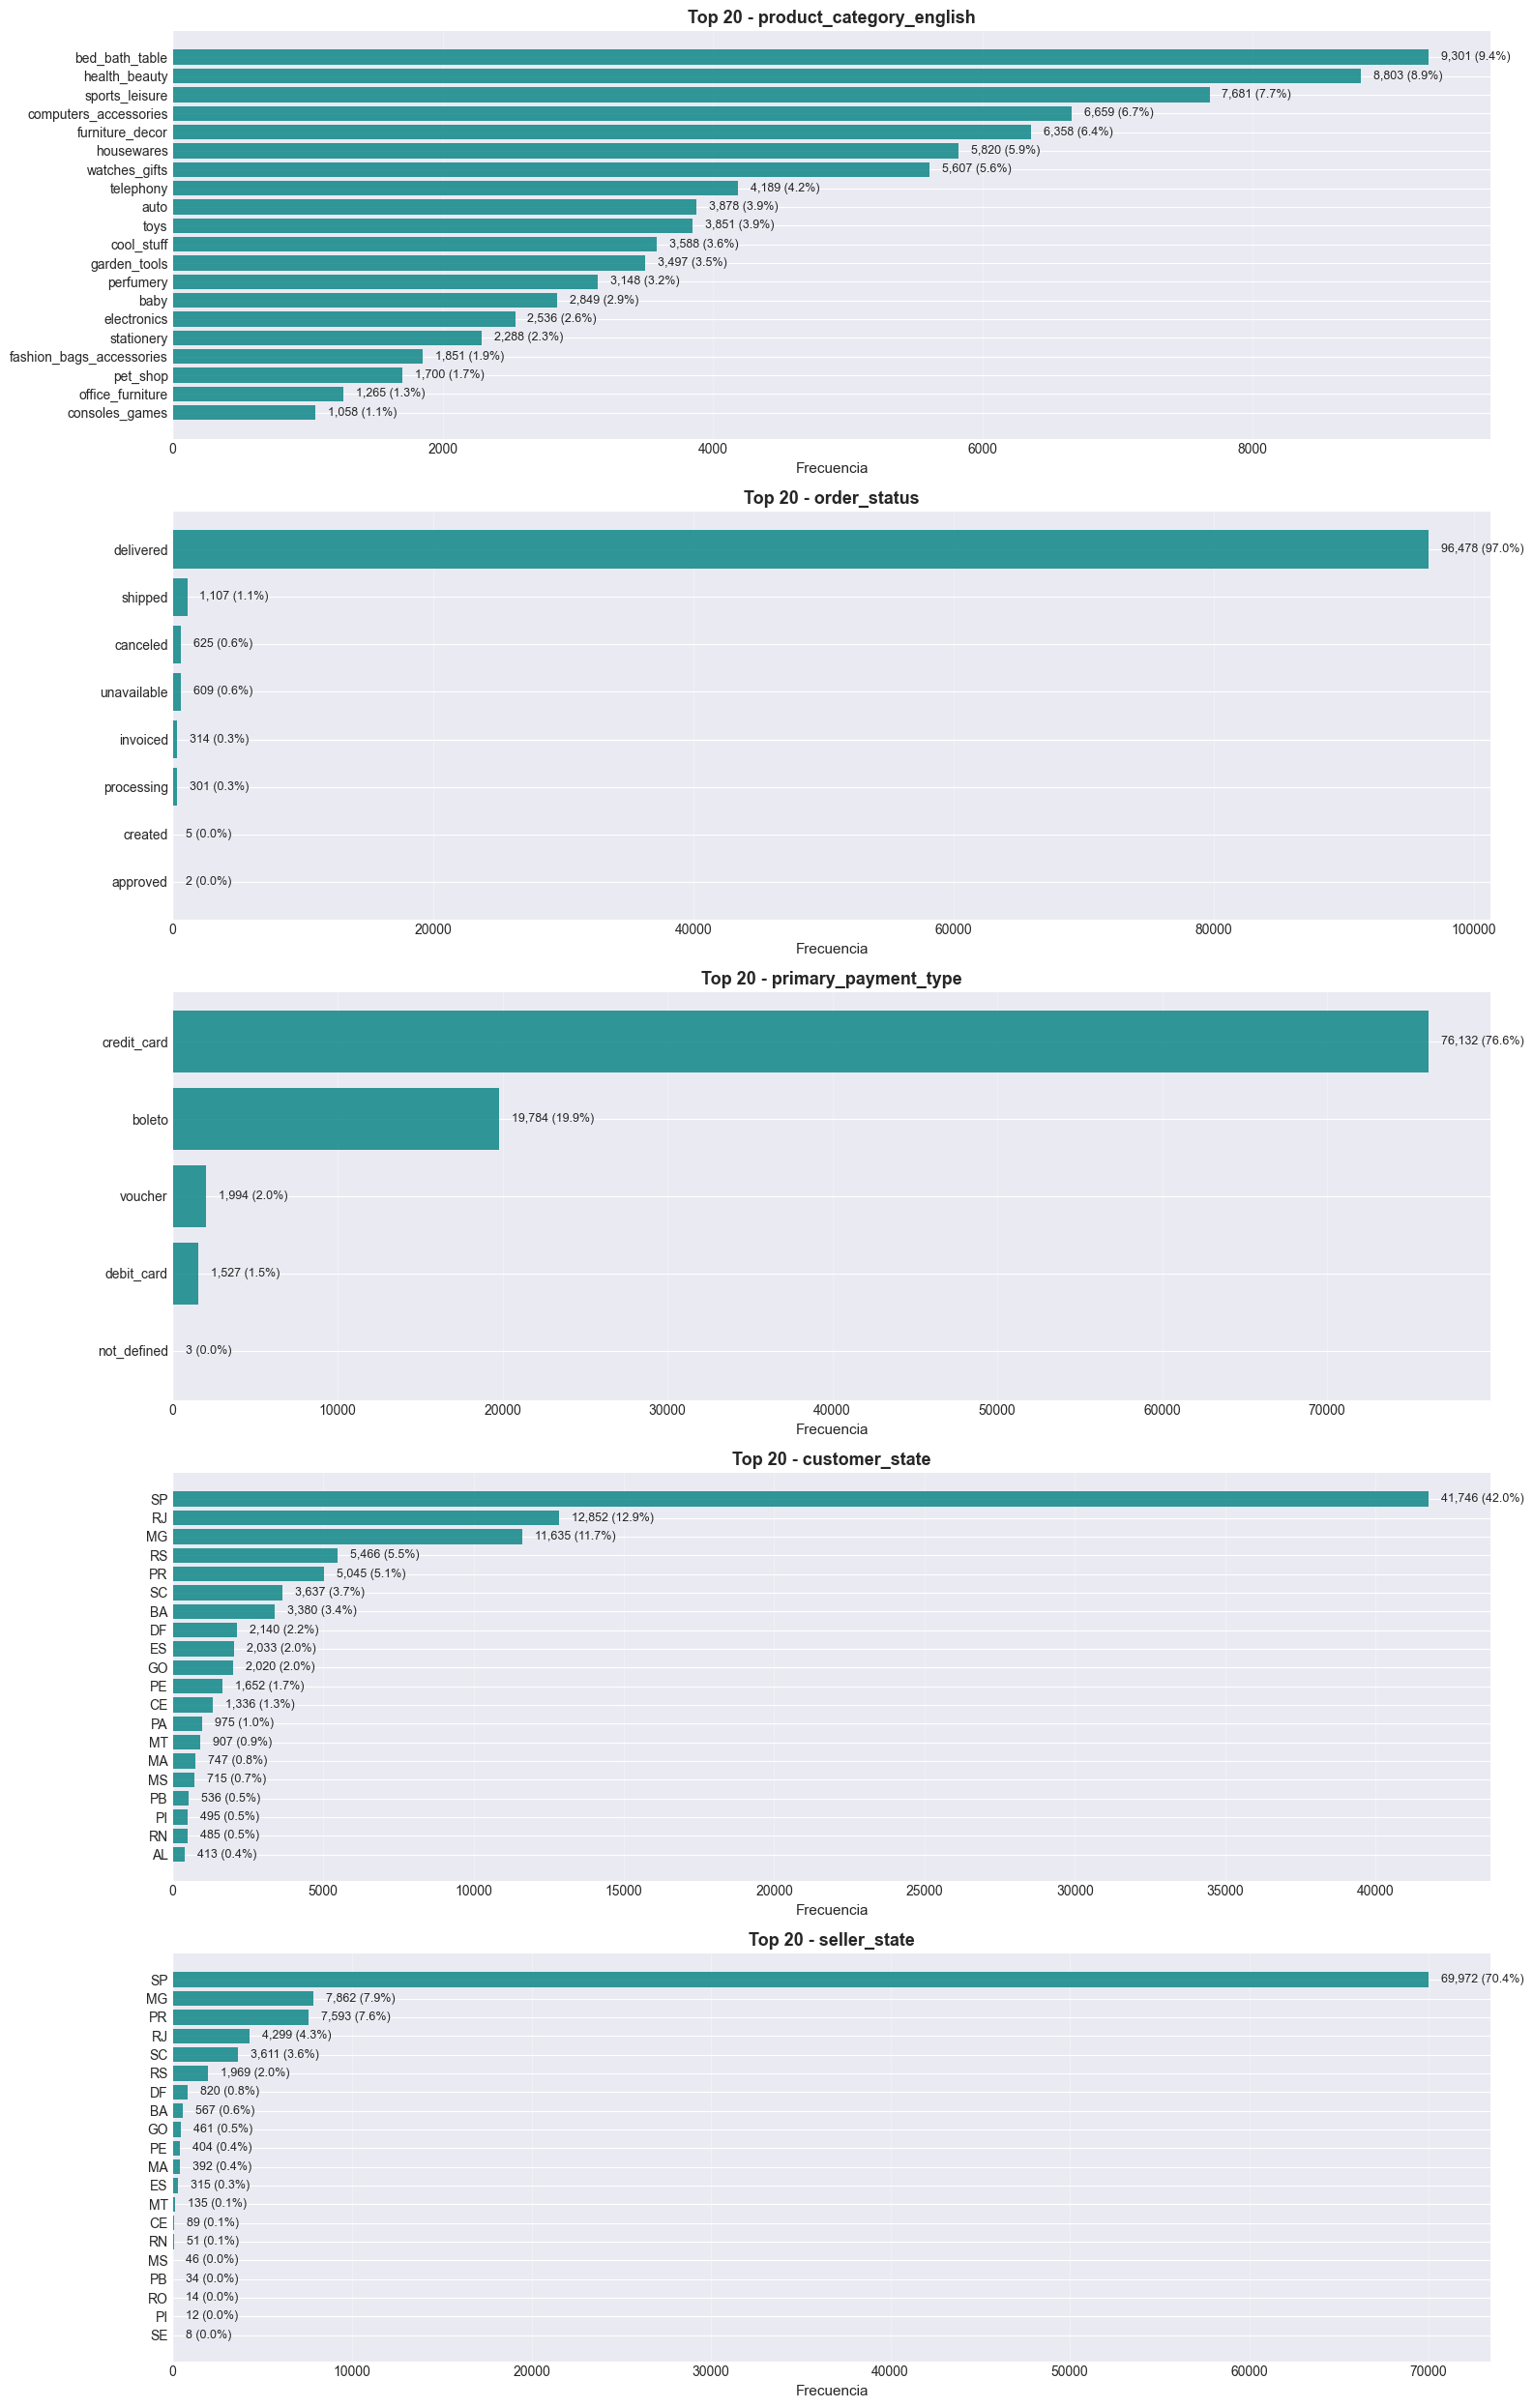


✓ Visualización guardada: 04_barplots_categoricas.png


In [12]:
# Visualización: Barplots para variables categóricas (Top 20)
n_vars = len(categorical_cols_available)
fig, axes = plt.subplots(n_vars, 1, figsize=(16, n_vars*5))

if n_vars == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols_available):
    ax = axes[idx]
    
    # Top 20 categorías
    top_20 = df[col].value_counts().head(20)
    
    # Barplot horizontal
    bars = ax.barh(range(len(top_20)), top_20.values, color='teal', alpha=0.8)
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20.index, fontsize=10)
    ax.set_xlabel('Frecuencia', fontsize=11)
    ax.set_title(f'Top 20 - {col}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, (bar, value) in enumerate(zip(bars, top_20.values)):
        pct = (value / len(df)) * 100
        ax.text(bar.get_width() + max(top_20.values)*0.01, bar.get_y() + bar.get_height()/2, 
                f'{value:,} ({pct:.1f}%)', 
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_barplots_categoricas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualización guardada: 04_barplots_categoricas.png")

### 3.3. Variables Temporales

**Enfoque:** Tendencias, estacionalidad, patrones de compra.  
**Relevancia para recomendación:** Identificar períodos de alta demanda, comportamiento temporal.

In [13]:
# Preparar variables temporales
# Buscar columna de fecha de compra
date_cols = [col for col in df.columns if 'purchase' in col.lower() or 'order_purchase' in col.lower()]

if len(date_cols) > 0:
    date_col = date_cols[0]
    print(f"Columna de fecha identificada: {date_col}")
    
    # Convertir a datetime si no lo está
    if df[date_col].dtype == 'object':
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # Crear variables temporales derivadas
    df['purchase_year'] = df[date_col].dt.year
    df['purchase_month'] = df[date_col].dt.month
    df['purchase_month_name'] = df[date_col].dt.month_name()
    df['purchase_weekday'] = df[date_col].dt.dayofweek  # 0=Lunes, 6=Domingo
    df['purchase_weekday_name'] = df[date_col].dt.day_name()
    df['purchase_date'] = df[date_col].dt.date
    
    print("\n✓ Variables temporales creadas:")
    print("  - purchase_year")
    print("  - purchase_month")
    print("  - purchase_month_name")
    print("  - purchase_weekday")
    print("  - purchase_weekday_name")
    print("  - purchase_date")
    
    # Análisis de rango temporal
    print(f"\n{'='*70}")
    print("ANÁLISIS TEMPORAL")
    print(f"{'='*70}")
    print(f"Fecha mínima: {df[date_col].min()}")
    print(f"Fecha máxima: {df[date_col].max()}")
    print(f"Rango: {(df[date_col].max() - df[date_col].min()).days} días")
    print(f"Años cubiertos: {df['purchase_year'].nunique()}")
    
else:
    print("⚠️ No se encontró columna de fecha de compra. Verificar nombres de columnas.")

Columna de fecha identificada: order_purchase_timestamp

✓ Variables temporales creadas:
  - purchase_year
  - purchase_month
  - purchase_month_name
  - purchase_weekday
  - purchase_weekday_name
  - purchase_date

ANÁLISIS TEMPORAL
Fecha mínima: 2016-09-04 21:15:19
Fecha máxima: 2018-10-17 17:30:18
Rango: 772 días
Años cubiertos: 3


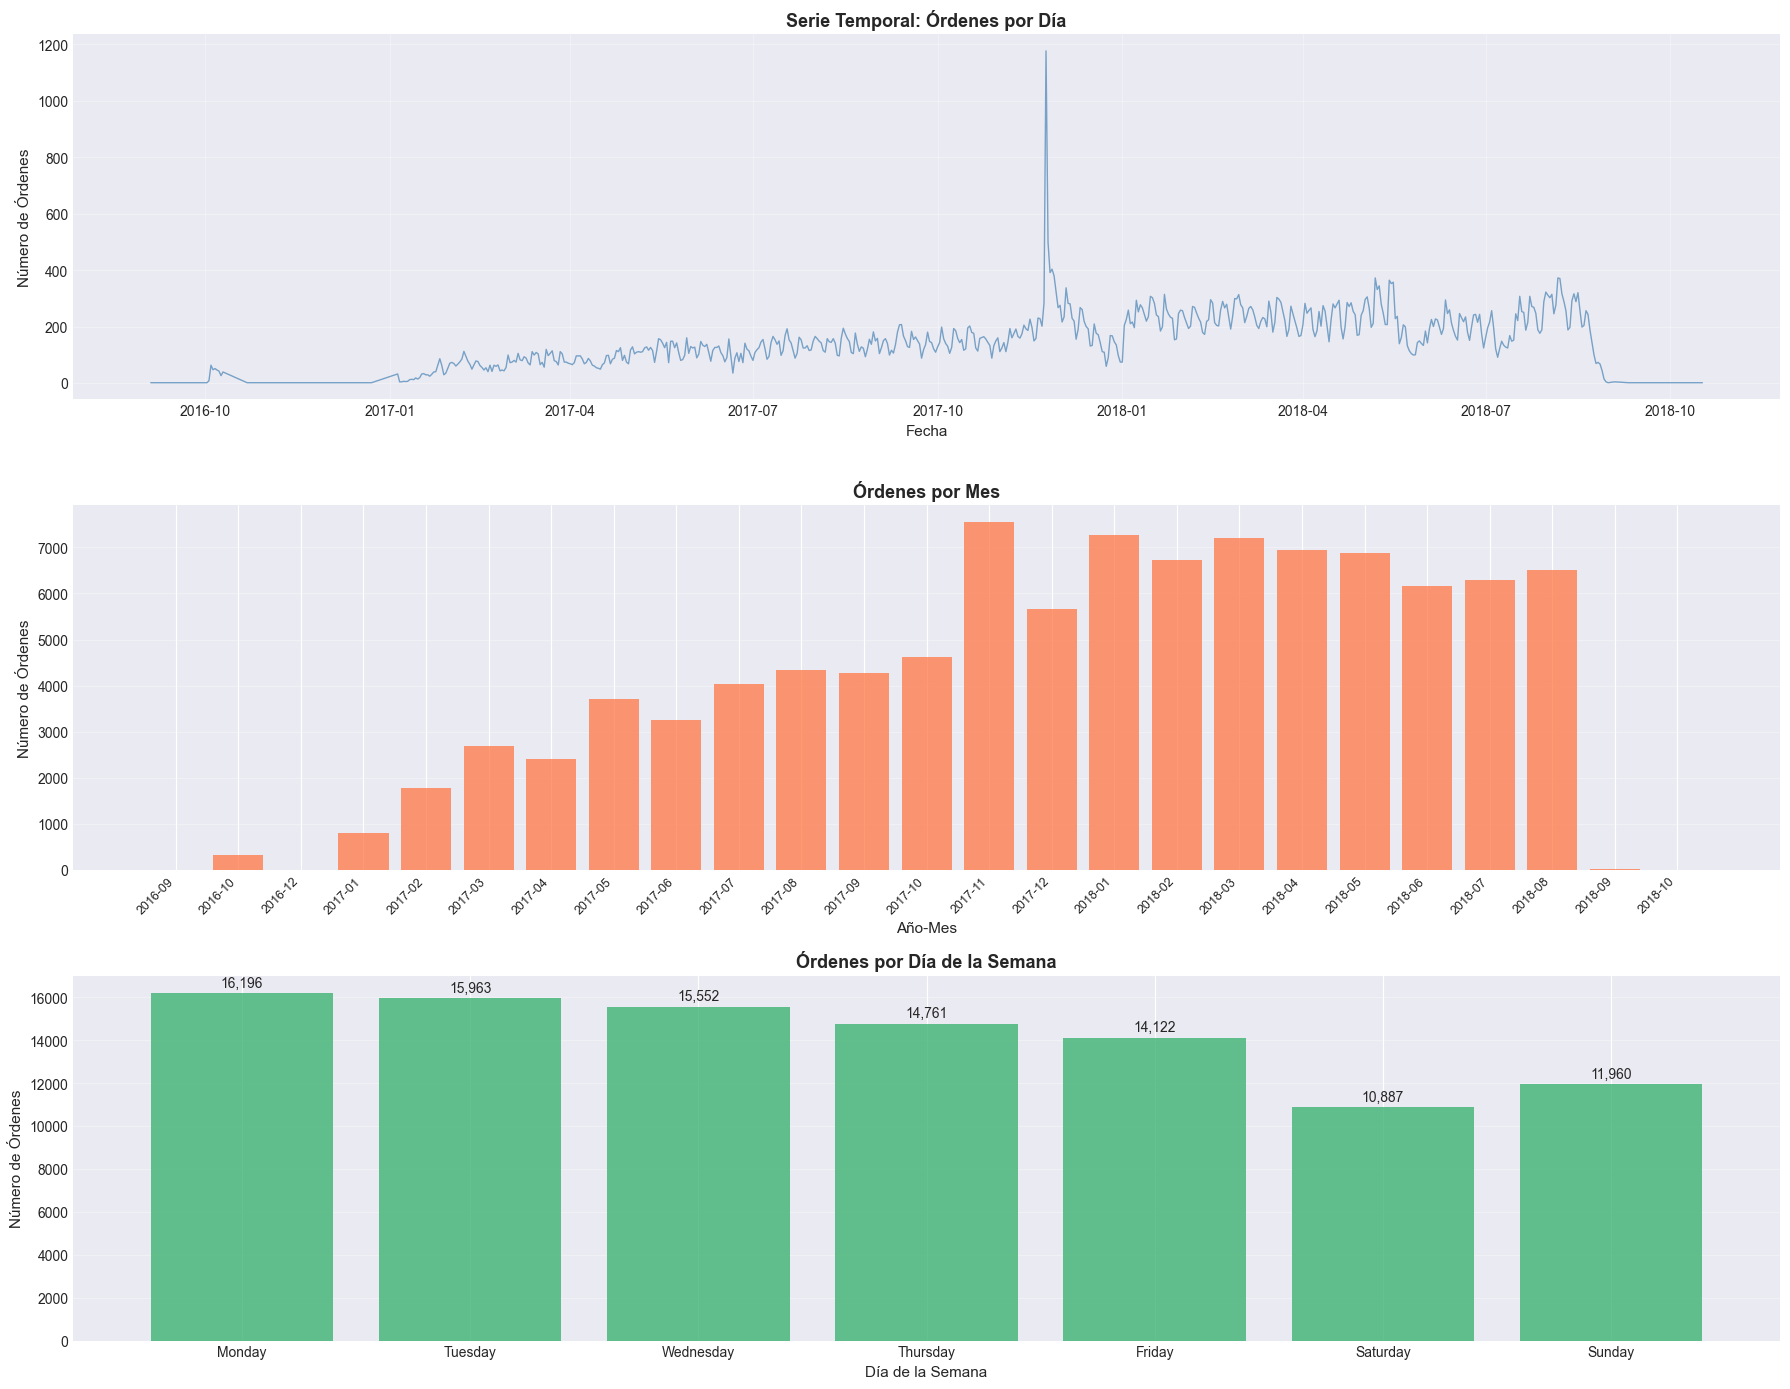


✓ Visualización guardada: 05_series_temporales.png


In [14]:
# Visualización: Series temporales
if 'purchase_date' in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(18, 14))
    
    # 1. Serie de tiempo: Órdenes por día
    orders_by_date = df.groupby('purchase_date').size().reset_index(name='orders')
    orders_by_date['purchase_date'] = pd.to_datetime(orders_by_date['purchase_date'])
    orders_by_date = orders_by_date.sort_values('purchase_date')
    
    axes[0].plot(orders_by_date['purchase_date'], orders_by_date['orders'], 
                 color='steelblue', linewidth=1, alpha=0.7)
    axes[0].set_xlabel('Fecha', fontsize=11)
    axes[0].set_ylabel('Número de Órdenes', fontsize=11)
    axes[0].set_title('Serie Temporal: Órdenes por Día', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # 2. Órdenes por mes
    orders_by_month = df.groupby(['purchase_year', 'purchase_month']).size().reset_index(name='orders')
    orders_by_month['year_month'] = orders_by_month['purchase_year'].astype(str) + '-' + orders_by_month['purchase_month'].astype(str).str.zfill(2)
    
    axes[1].bar(range(len(orders_by_month)), orders_by_month['orders'], 
                color='coral', alpha=0.8)
    axes[1].set_xticks(range(len(orders_by_month)))
    axes[1].set_xticklabels(orders_by_month['year_month'], rotation=45, ha='right', fontsize=9)
    axes[1].set_xlabel('Año-Mes', fontsize=11)
    axes[1].set_ylabel('Número de Órdenes', fontsize=11)
    axes[1].set_title('Órdenes por Mes', fontsize=13, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
    
    # 3. Órdenes por día de la semana
    weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    orders_by_weekday = df['purchase_weekday_name'].value_counts().reindex(weekday_order)
    
    axes[2].bar(orders_by_weekday.index, orders_by_weekday.values, 
                color='mediumseagreen', alpha=0.8)
    axes[2].set_xlabel('Día de la Semana', fontsize=11)
    axes[2].set_ylabel('Número de Órdenes', fontsize=11)
    axes[2].set_title('Órdenes por Día de la Semana', fontsize=13, fontweight='bold')
    axes[2].grid(alpha=0.3, axis='y')
    
    # Añadir valores en las barras
    for i, (day, value) in enumerate(zip(orders_by_weekday.index, orders_by_weekday.values)):
        axes[2].text(i, value + max(orders_by_weekday.values)*0.01, 
                     f'{value:,}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '05_series_temporales.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 05_series_temporales.png")
else:
    print("No se pueden crear visualizaciones temporales")

---

## FASE 4: Análisis Bivariable

⏱️ **Tiempo estimado:** 2 horas

Análisis de relaciones entre pares de variables para identificar patrones y asociaciones relevantes para el sistema de recomendación.

### 4.1. Precio vs Categoría de Producto

**Pregunta clave:** ¿Existen diferencias significativas de precio entre categorías?  
**Relevancia:** Identificar categorías premium vs económicas para segmentación en recomendaciones.

In [15]:
# Análisis: Precio promedio por categoría (Top 20)
if 'product_category_english' in df.columns and 'total_price' in df.columns:
    
    # Calcular precio promedio por categoría
    price_by_category = df.groupby('product_category_english')['total_price'].agg([
        'mean', 'median', 'count', 'std'
    ]).round(2)
    
    price_by_category = price_by_category.sort_values('mean', ascending=False)
    
    print("="*70)
    print("PRECIO PROMEDIO POR CATEGORÍA")
    print("="*70)
    print(f"\nTop 10 categorías más caras:")
    display(price_by_category.head(10))
    
    print(f"\nTop 10 categorías más económicas (con al menos 50 órdenes):")
    price_by_category_filtered = price_by_category[price_by_category['count'] >= 50]
    display(price_by_category_filtered.tail(10))
    
else:
    print("⚠️ Columnas necesarias no encontradas")

PRECIO PROMEDIO POR CATEGORÍA

Top 10 categorías más caras:


,mean,median,count,std
product_category_english,,,,
computers,1230.96,1200.00,180,726.76
small_appliances_home_oven_and_coffee,632.61,640.99,75,614.31
home_appliances_2,484.44,229.99,234,545.57
agro_industry_and_commerce,398.52,344.90,182,598.07
musical_instruments,306.66,119.80,625,465.88
small_appliances,302.62,104.90,626,496.79
fixed_telephony,276.31,60.00,215,1084.59
construction_tools_safety,248.69,139.79,163,374.25
air_conditioning,218.31,139.00,252,257.60



Top 10 categorías más económicas (con al menos 50 órdenes):


,mean,median,count,std
product_category_english,,,,
books_imported,88.84,67.00,52,104.16
fashion_bags_accessories,82.41,49.90,1851,110.28
fashion_underwear_beach,78.86,59.90,121,53.47
telephony,77.53,29.99,4189,148.11
drinks,76.80,47.49,293,179.11
books_technical,74.05,57.89,259,65.97
christmas_supplies,68.88,57.95,128,80.37
food_drink,67.47,40.80,223,78.76
food,65.79,56.97,445,47.18


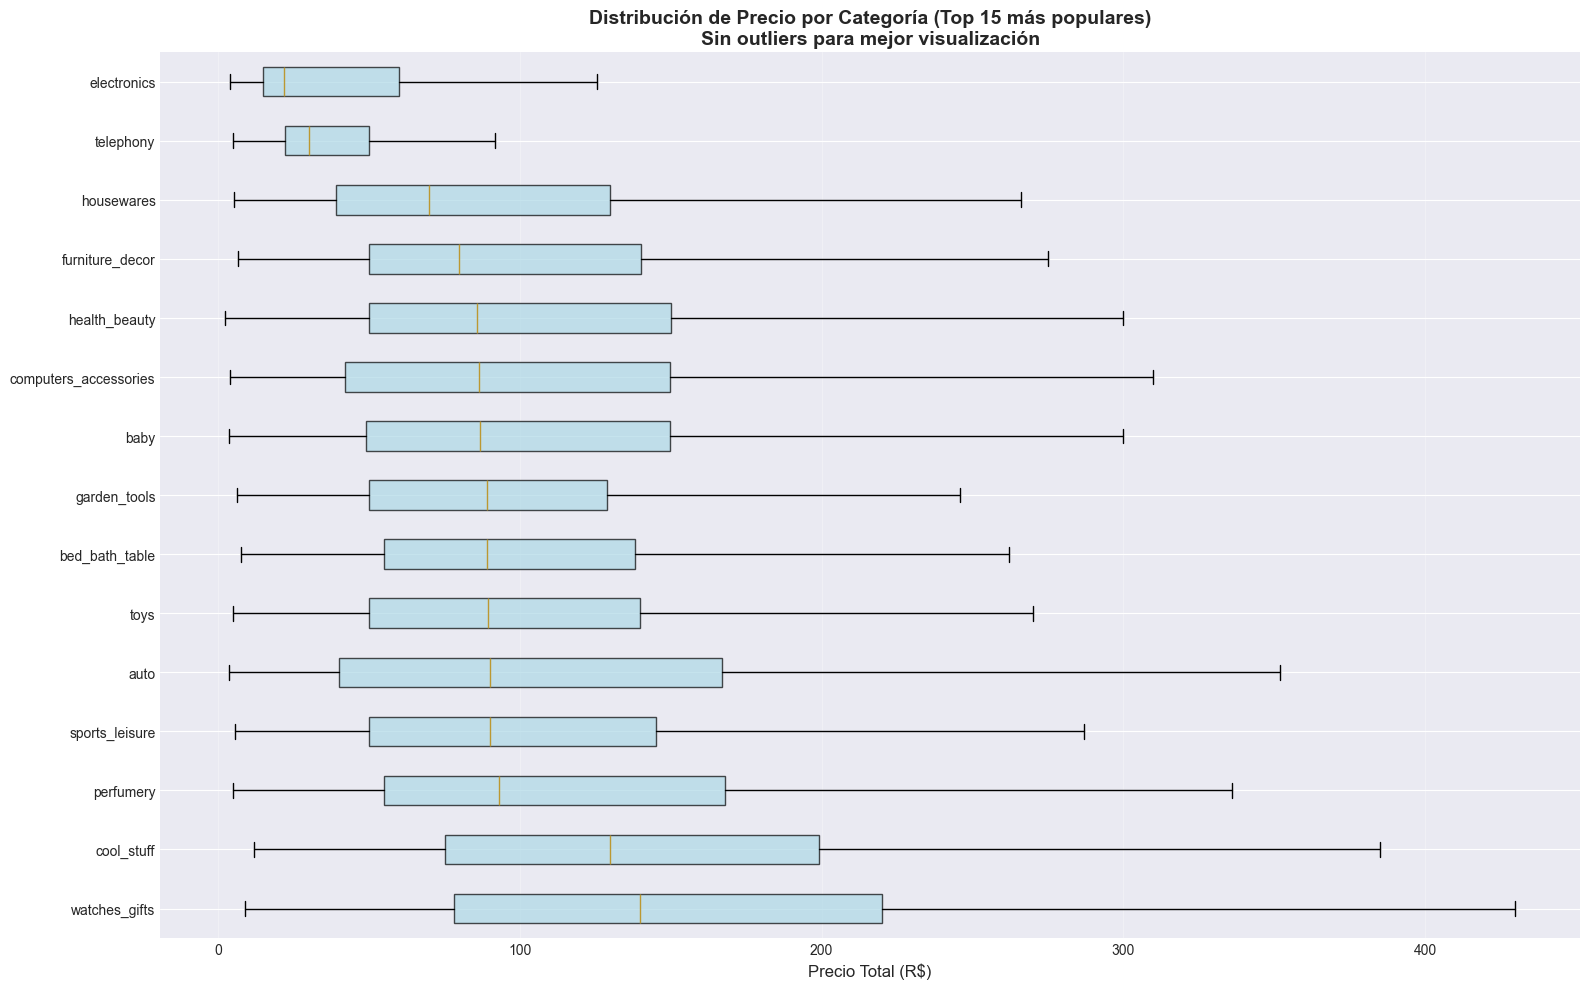


✓ Visualización guardada: 06_precio_por_categoria.png


In [16]:
# Visualización: Boxplots de precio para Top 15 categorías más populares
if 'product_category_english' in df.columns and 'total_price' in df.columns:
    
    # Top 15 categorías por volumen
    top_15_categories = df['product_category_english'].value_counts().head(15).index
    df_top_15 = df[df['product_category_english'].isin(top_15_categories)]
    
    # Ordenar por precio mediano
    category_order = df_top_15.groupby('product_category_english')['total_price'].median().sort_values(ascending=False).index
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Boxplot horizontal
    bp = ax.boxplot([df_top_15[df_top_15['product_category_english'] == cat]['total_price'].dropna() 
                      for cat in category_order],
                     vert=False,
                     labels=category_order,
                     patch_artist=True,
                     showfliers=False)  # Sin outliers para mejor visualización
    
    # Colorear cajas
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    ax.set_xlabel('Precio Total (R$)', fontsize=12)
    ax.set_title('Distribución de Precio por Categoría (Top 15 más populares)\nSin outliers para mejor visualización', 
                 fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '06_precio_por_categoria.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 06_precio_por_categoria.png")

### 4.2. Satisfacción (Review Score) vs Días de Entrega

**Pregunta clave:** ¿Los retrasos en la entrega afectan la satisfacción del cliente?  
**Relevancia:** Validar calidad de experiencia para mejorar recomendaciones futuras.

In [17]:
# Análisis: Días de entrega por nivel de satisfacción
if 'review_score' in df.columns and 'delivery_days' in df.columns:
    
    # Filtrar datos válidos
    df_review_delivery = df[['review_score', 'delivery_days']].dropna()
    
    # Estadísticas por review score
    stats_by_score = df_review_delivery.groupby('review_score')['delivery_days'].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ]).round(2)
    
    print("="*70)
    print("DÍAS DE ENTREGA POR NIVEL DE SATISFACCIÓN")
    print("="*70)
    display(stats_by_score)
    
    # Correlación
    corr = df_review_delivery['review_score'].corr(df_review_delivery['delivery_days'])
    print(f"\nCorrelación Pearson (review_score vs delivery_days): {corr:.4f}")
    
    if corr < -0.3:
        print("→ Correlación negativa moderada-fuerte: más días = menor satisfacción")
    elif corr < -0.1:
        print("→ Correlación negativa débil: posible impacto de entregas lentas")
    else:
        print("→ Correlación débil o inexistente")
        
else:
    print("⚠️ Columnas necesarias no encontradas")

DÍAS DE ENTREGA POR NIVEL DE SATISFACCIÓN


,count,mean,median,std,min,max
review_score,,,,,,
1.00,9347,20.86,16.00,16.08,0.00,195.00
2.00,2923,16.20,13.00,12.50,1.00,208.00
3.00,7909,13.79,12.00,9.94,0.00,188.00
4.00,18893,11.84,10.00,8.29,0.00,194.00
5.00,56758,10.22,9.00,6.82,0.00,187.00



Correlación Pearson (review_score vs delivery_days): -0.3340
→ Correlación negativa moderada-fuerte: más días = menor satisfacción


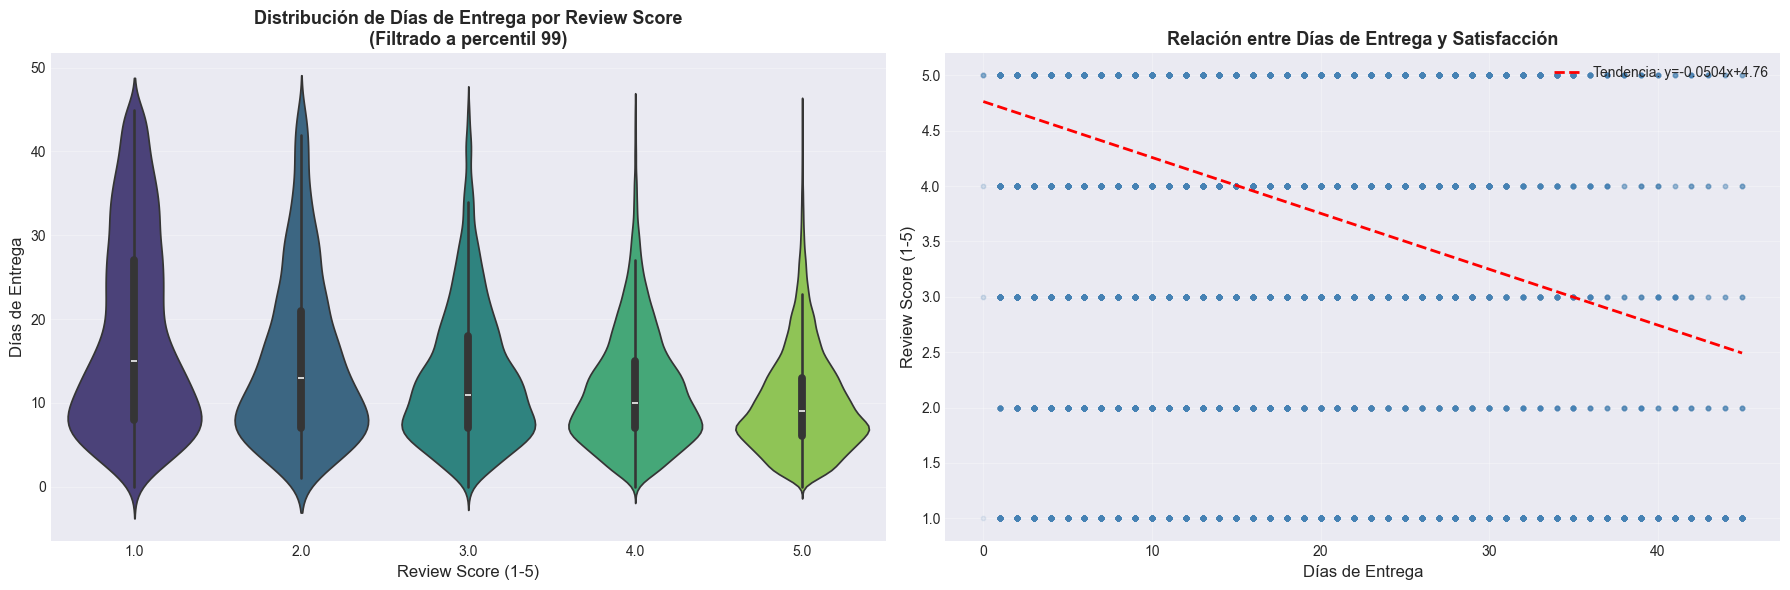


✓ Visualización guardada: 07_satisfaccion_vs_entrega.png


In [18]:
# Visualización: Violinplot + Scatterplot con densidad
if 'review_score' in df.columns and 'delivery_days' in df.columns:
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Violinplot: Distribución de días de entrega por review score
    df_review_delivery = df[['review_score', 'delivery_days']].dropna()
    
    # Filtrar outliers extremos (percentil 99) para mejor visualización
    p99 = df_review_delivery['delivery_days'].quantile(0.99)
    df_filtered = df_review_delivery[df_review_delivery['delivery_days'] <= p99]
    
    sns.violinplot(data=df_filtered, x='review_score', y='delivery_days', 
                   ax=axes[0], palette='viridis')
    axes[0].set_xlabel('Review Score (1-5)', fontsize=12)
    axes[0].set_ylabel('Días de Entrega', fontsize=12)
    axes[0].set_title('Distribución de Días de Entrega por Review Score\n(Filtrado a percentil 99)', 
                      fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='y')
    
    # 2. Scatterplot con transparencia
    axes[1].scatter(df_filtered['delivery_days'], df_filtered['review_score'], 
                    alpha=0.1, s=10, color='steelblue')
    
    # Línea de tendencia
    z = np.polyfit(df_filtered['delivery_days'], df_filtered['review_score'], 1)
    p = np.poly1d(z)
    axes[1].plot(df_filtered['delivery_days'].sort_values(), 
                 p(df_filtered['delivery_days'].sort_values()), 
                 "r--", linewidth=2, label=f'Tendencia: y={z[0]:.4f}x+{z[1]:.2f}')
    
    axes[1].set_xlabel('Días de Entrega', fontsize=12)
    axes[1].set_ylabel('Review Score (1-5)', fontsize=12)
    axes[1].set_title('Relación entre Días de Entrega y Satisfacción', 
                      fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '07_satisfaccion_vs_entrega.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 07_satisfaccion_vs_entrega.png")

### 4.3. Análisis Geográfico: Cliente vs Vendedor

**Pregunta clave:** ¿Las transacciones son mayormente locales o interestatales?  
**Relevancia:** Entender logística y tiempos de entrega para personalización regional.

In [19]:
# Análisis: Transacciones locales vs interestatales
if 'customer_state' in df.columns and 'seller_state' in df.columns:
    
    # Crear indicador de transacción local
    df['is_local'] = df['customer_state'] == df['seller_state']
    
    local_count = df['is_local'].sum()
    interstate_count = (~df['is_local']).sum()
    local_pct = (local_count / len(df)) * 100
    
    print("="*70)
    print("ANÁLISIS GEOGRÁFICO: LOCAL VS INTERESTATAL")
    print("="*70)
    print(f"\nTransacciones locales (mismo estado): {local_count:,} ({local_pct:.2f}%)")
    print(f"Transacciones interestatales: {interstate_count:,} ({100-local_pct:.2f}%)")
    
    # Análisis de entregas por tipo
    if 'delivery_days' in df.columns:
        delivery_local = df[df['is_local']]['delivery_days'].dropna()
        delivery_interstate = df[~df['is_local']]['delivery_days'].dropna()
        
        print(f"\n{'='*70}")
        print("IMPACTO EN TIEMPOS DE ENTREGA")
        print(f"{'='*70}")
        print(f"\nEntrega LOCAL:")
        print(f"  - Promedio: {delivery_local.mean():.2f} días")
        print(f"  - Mediana: {delivery_local.median():.2f} días")
        
        print(f"\nEntrega INTERESTATAL:")
        print(f"  - Promedio: {delivery_interstate.mean():.2f} días")
        print(f"  - Mediana: {delivery_interstate.median():.2f} días")
        
        diff = delivery_interstate.mean() - delivery_local.mean()
        print(f"\n→ Diferencia: +{diff:.2f} días para entregas interestatales")
    
    # Top 10 pares de estados más frecuentes
    print(f"\n{'='*70}")
    print("TOP 10 PARES CLIENTE-VENDEDOR MÁS FRECUENTES")
    print(f"{'='*70}")
    top_pairs = df.groupby(['customer_state', 'seller_state']).size().sort_values(ascending=False).head(10)
    for (customer, seller), count in top_pairs.items():
        pct = (count / len(df)) * 100
        local_label = "🏠 LOCAL" if customer == seller else "✈️ INTERESTATAL"
        print(f"{customer} → {seller}: {count:,} ({pct:.2f}%) {local_label}")
        
else:
    print("⚠️ Columnas necesarias no encontradas")

ANÁLISIS GEOGRÁFICO: LOCAL VS INTERESTATAL

Transacciones locales (mismo estado): 35,478 (35.68%)
Transacciones interestatales: 63,963 (64.32%)

IMPACTO EN TIEMPOS DE ENTREGA

Entrega LOCAL:
  - Promedio: 7.48 días
  - Mediana: 6.00 días

Entrega INTERESTATAL:
  - Promedio: 14.68 días
  - Mediana: 12.00 días

→ Diferencia: +7.20 días para entregas interestatales

TOP 10 PARES CLIENTE-VENDEDOR MÁS FRECUENTES
SP → SP: 31,410 (31.59%) 🏠 LOCAL
RJ → SP: 8,428 (8.48%) ✈️ INTERESTATAL
MG → SP: 7,558 (7.60%) ✈️ INTERESTATAL
RS → SP: 3,648 (3.67%) ✈️ INTERESTATAL
PR → SP: 3,169 (3.19%) ✈️ INTERESTATAL
SP → PR: 2,982 (3.00%) ✈️ INTERESTATAL
SP → MG: 2,606 (2.62%) ✈️ INTERESTATAL
BA → SP: 2,383 (2.40%) ✈️ INTERESTATAL
SC → SP: 2,366 (2.38%) ✈️ INTERESTATAL
MG → MG: 1,561 (1.57%) 🏠 LOCAL


### 4.4. Matriz de Correlación - Variables Numéricas

**Pregunta clave:** ¿Qué variables numéricas están correlacionadas?  
**Relevancia:** Identificar multicolinealidad y relaciones para feature engineering.

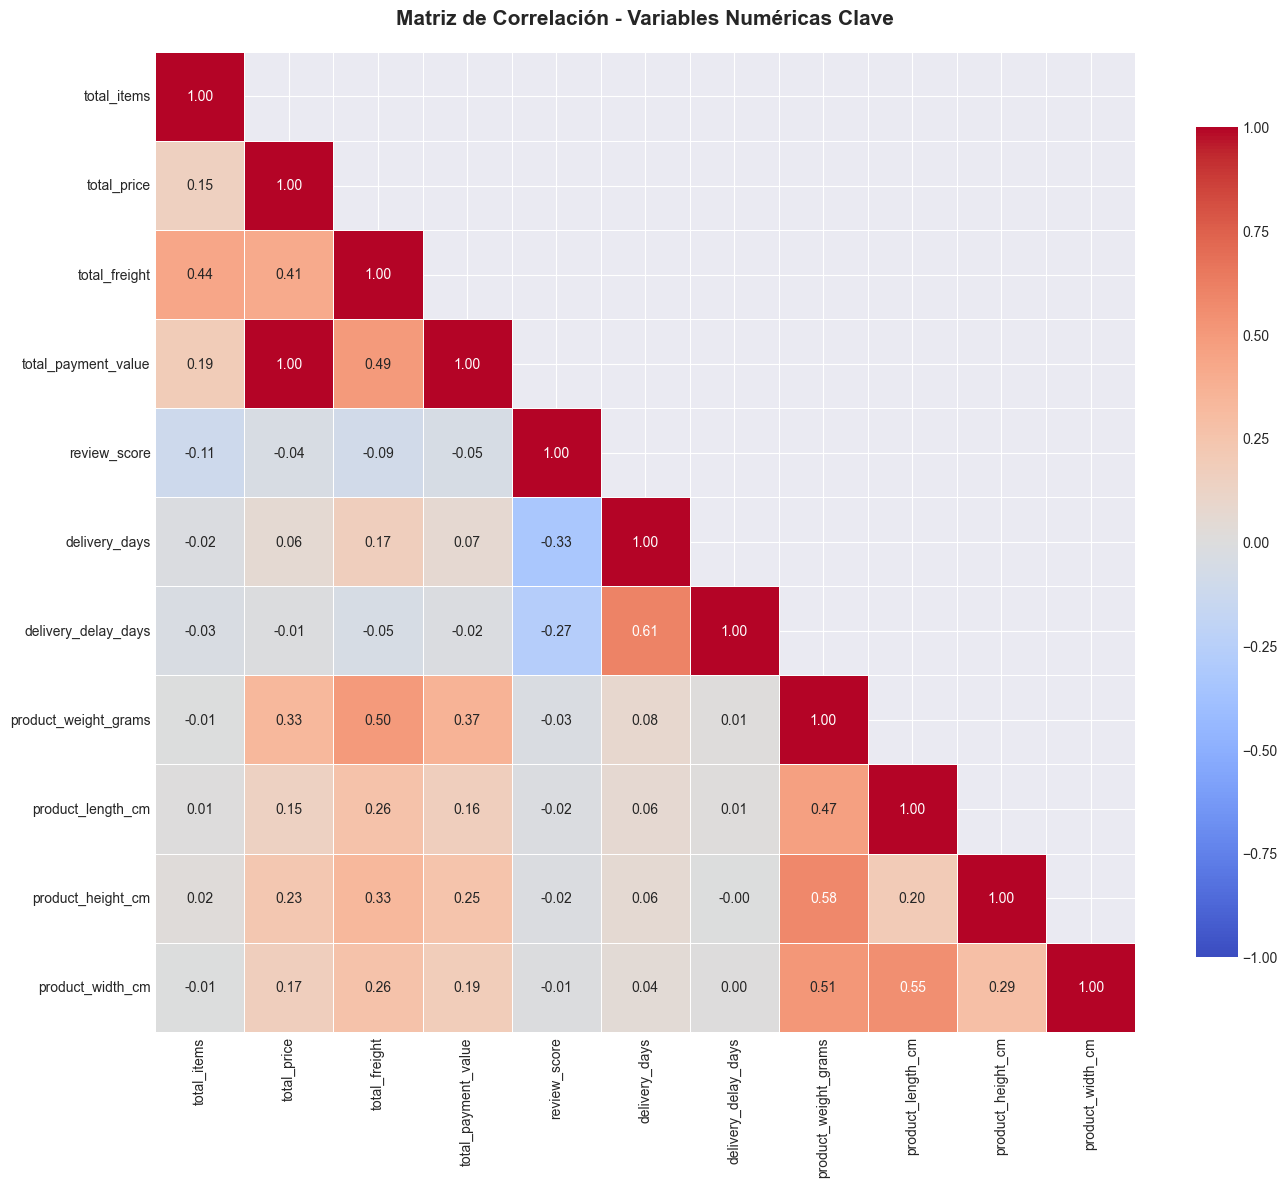


✓ Visualización guardada: 08_matriz_correlacion.png

CORRELACIONES FUERTES (|r| > 0.5)


,Variable 1,Variable 2,Correlación
0,total_price,total_payment_value,1.00
1,delivery_days,delivery_delay_days,0.61
2,product_weight_grams,product_height_cm,0.58
4,product_length_cm,product_width_cm,0.55
3,product_weight_grams,product_width_cm,0.51


In [20]:
# Calcular matriz de correlación para variables numéricas clave
correlation_cols = [
    'total_items', 'total_price', 'total_freight', 'total_payment_value',
    'review_score', 'delivery_days', 'delivery_delay_days',
    'product_weight_grams', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]

# Filtrar columnas que existen
correlation_cols_available = [col for col in correlation_cols if col in df.columns]

if len(correlation_cols_available) > 0:
    
    # Calcular matriz de correlación
    corr_matrix = df[correlation_cols_available].corr()
    
    # Visualización: Heatmap de correlación
    fig, ax = plt.subplots(figsize=(14, 12))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Máscara triangular superior
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=True, 
                fmt='.2f', 
                cmap='coolwarm', 
                center=0,
                vmin=-1, vmax=1,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                ax=ax)
    
    ax.set_title('Matriz de Correlación - Variables Numéricas Clave', 
                 fontsize=15, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '08_matriz_correlacion.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 08_matriz_correlacion.png")
    
    # Identificar correlaciones fuertes (|r| > 0.5, excluyendo diagonal)
    print(f"\n{'='*70}")
    print("CORRELACIONES FUERTES (|r| > 0.5)")
    print(f"{'='*70}")
    
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                strong_corr.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlación': corr_val
                })
    
    if strong_corr:
        strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlación', 
                                                                key=abs, 
                                                                ascending=False)
        display(strong_corr_df)
    else:
        print("\nNo se encontraron correlaciones fuertes (|r| > 0.5) entre las variables analizadas")
        
else:
    print("⚠️ No hay variables numéricas disponibles para correlación")

### 4.5. Relación: Precio Total vs Pago Total

**Pregunta clave:** ¿El pago total coincide con el precio total (productos + flete)?  
**Relevancia:** Validar integridad de datos transaccionales.

In [21]:
# Análisis: Coherencia entre precio y pago
if 'total_price' in df.columns and 'total_payment_value' in df.columns and 'total_freight' in df.columns:
    
    # Calcular precio esperado (productos + flete)
    df['expected_payment'] = df['total_price'] + df['total_freight']
    
    # Diferencia entre pago real y esperado
    df['payment_diff'] = df['total_payment_value'] - df['expected_payment']
    
    # Estadísticas
    print("="*70)
    print("ANÁLISIS: PAGO TOTAL VS PRECIO ESPERADO")
    print("="*70)
    
    # Casos con diferencias significativas (>1% del precio esperado)
    df['payment_diff_pct'] = (df['payment_diff'] / df['expected_payment']) * 100
    
    exact_match = (df['payment_diff'].abs() < 0.01).sum()
    small_diff = (df['payment_diff'].abs() < 1).sum()  # Diferencia < 1 real
    
    print(f"\nÓrdenes con coincidencia exacta (<0.01 R$): {exact_match:,} ({exact_match/len(df)*100:.2f}%)")
    print(f"Órdenes con diferencia pequeña (<1 R$): {small_diff:,} ({small_diff/len(df)*100:.2f}%)")
    
    # Estadísticas de diferencia
    print(f"\nEstadísticas de diferencia (Pago - Esperado):")
    print(f"  Media: {df['payment_diff'].mean():.2f} R$")
    print(f"  Mediana: {df['payment_diff'].median():.2f} R$")
    print(f"  Desv. Estándar: {df['payment_diff'].std():.2f} R$")
    print(f"  Rango: [{df['payment_diff'].min():.2f}, {df['payment_diff'].max():.2f}] R$")
    
    # Casos con diferencias grandes
    large_diff = df[df['payment_diff'].abs() > 10]
    print(f"\nÓrdenes con diferencia > 10 R$: {len(large_diff):,} ({len(large_diff)/len(df)*100:.2f}%)")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

ANÁLISIS: PAGO TOTAL VS PRECIO ESPERADO

Órdenes con coincidencia exacta (<0.01 R$): 98,287 (98.84%)
Órdenes con diferencia pequeña (<1 R$): 98,415 (98.97%)

Estadísticas de diferencia (Pago - Esperado):
  Media: 0.03 R$
  Mediana: 0.00 R$
  Desv. Estándar: 1.13 R$
  Rango: [-51.62, 182.81] R$

Órdenes con diferencia > 10 R$: 98 (0.10%)


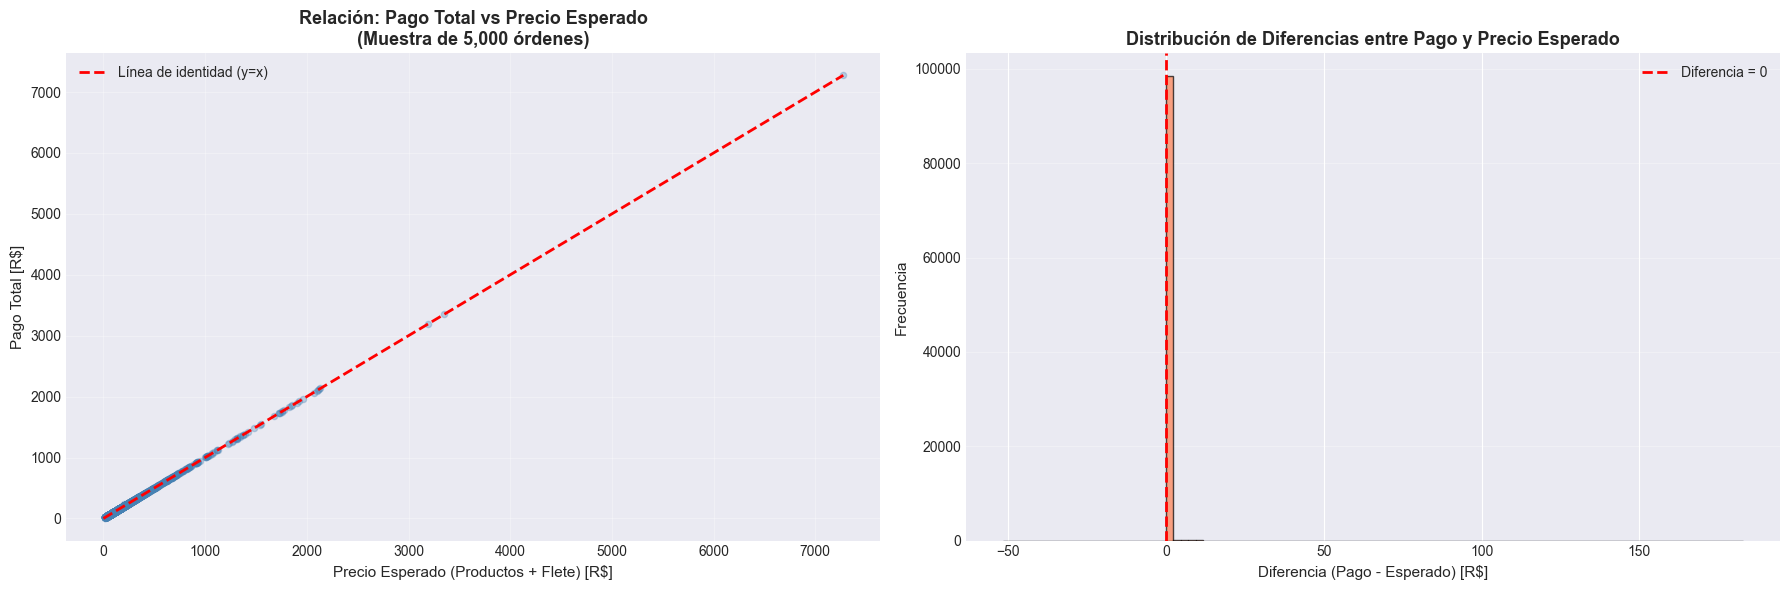


✓ Visualización guardada: 09_pago_vs_precio.png


In [22]:
# Visualización: Scatterplot pago vs precio esperado
if 'expected_payment' in df.columns and 'total_payment_value' in df.columns:
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. Scatterplot con línea de identidad
    sample_size = min(5000, len(df))  # Muestra para mejor visualización
    df_sample = df.sample(n=sample_size, random_state=42)
    
    axes[0].scatter(df_sample['expected_payment'], 
                    df_sample['total_payment_value'], 
                    alpha=0.3, s=20, color='steelblue')
    
    # Línea de identidad (y=x)
    max_val = max(df_sample['expected_payment'].max(), df_sample['total_payment_value'].max())
    axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Línea de identidad (y=x)')
    
    axes[0].set_xlabel('Precio Esperado (Productos + Flete) [R$]', fontsize=11)
    axes[0].set_ylabel('Pago Total [R$]', fontsize=11)
    axes[0].set_title(f'Relación: Pago Total vs Precio Esperado\n(Muestra de {sample_size:,} órdenes)', 
                      fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 2. Histograma de diferencias
    axes[1].hist(df['payment_diff'], bins=100, color='coral', alpha=0.7, edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Diferencia = 0')
    axes[1].set_xlabel('Diferencia (Pago - Esperado) [R$]', fontsize=11)
    axes[1].set_ylabel('Frecuencia', fontsize=11)
    axes[1].set_title('Distribución de Diferencias entre Pago y Precio Esperado', 
                      fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '09_pago_vs_precio.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 09_pago_vs_precio.png")

---

## FASE 5: Análisis Multivariable

⏱️ **Tiempo estimado:** 2.5 horas

Análisis de interacciones entre múltiples variables para identificar segmentos de clientes, patrones complejos y comportamientos multidimensionales relevantes para el sistema de recomendación.

### 5.1. Segmentación de Clientes (RFM Simplificado)

**Pregunta clave:** ¿Existen diferentes perfiles de clientes según su comportamiento de compra?  
**Relevancia:** Segmentar usuarios para personalizar recomendaciones por perfil.

In [23]:
# Segmentación de clientes por comportamiento de compra
if 'customer_unique_id' in df.columns and 'total_payment_value' in df.columns:
    
    # Agregar por cliente
    customer_behavior = df.groupby('customer_unique_id').agg({
        'order_id': 'count',                    # Frecuencia (F)
        'total_payment_value': 'sum',           # Valor monetario (M)
        'order_purchase_timestamp': 'max'       # Recencia (R)
    }).rename(columns={
        'order_id': 'num_orders',
        'total_payment_value': 'total_spent',
        'order_purchase_timestamp': 'last_purchase'
    })
    
    # Calcular recencia en días desde la última compra
    max_date = df['order_purchase_timestamp'].max()
    customer_behavior['recency_days'] = (max_date - customer_behavior['last_purchase']).dt.days
    
    # Definir segmentos simplificados
    # Frecuencia: 1 compra = One-time, >1 = Recurrente
    customer_behavior['frequency_segment'] = customer_behavior['num_orders'].apply(
        lambda x: 'One-time' if x == 1 else 'Recurrent'
    )
    
    # Valor monetario: Cuartiles
    customer_behavior['monetary_segment'] = pd.qcut(
        customer_behavior['total_spent'], 
        q=4, 
        labels=['Low-Value', 'Medium-Value', 'High-Value', 'VIP']
    )
    
    # Recencia: Cuartiles (días desde última compra)
    customer_behavior['recency_segment'] = pd.qcut(
        customer_behavior['recency_days'], 
        q=4, 
        labels=['Very-Recent', 'Recent', 'Inactive', 'Lost'],
        duplicates='drop'
    )
    
    print("="*70)
    print("SEGMENTACIÓN DE CLIENTES")
    print("="*70)
    
    print(f"\nTotal clientes analizados: {len(customer_behavior):,}")
    print(f"\n1. SEGMENTACIÓN POR FRECUENCIA:")
    print(customer_behavior['frequency_segment'].value_counts())
    print(f"\n   Porcentajes:")
    print((customer_behavior['frequency_segment'].value_counts(normalize=True) * 100).round(2))
    
    print(f"\n2. SEGMENTACIÓN POR VALOR MONETARIO:")
    print(customer_behavior['monetary_segment'].value_counts().sort_index())
    
    print(f"\n3. SEGMENTACIÓN POR RECENCIA:")
    print(customer_behavior['recency_segment'].value_counts().sort_index())
    
    # Perfil combinado más relevante
    customer_behavior['customer_profile'] = (
        customer_behavior['frequency_segment'] + ' + ' + 
        customer_behavior['monetary_segment'].astype(str)
    )
    
    print(f"\n4. PERFILES COMBINADOS (Top 10):")
    print(customer_behavior['customer_profile'].value_counts().head(10))
    
else:
    print("⚠️ Columnas necesarias no encontradas")

SEGMENTACIÓN DE CLIENTES

Total clientes analizados: 96,096

1. SEGMENTACIÓN POR FRECUENCIA:
frequency_segment
One-time     93099
Recurrent     2997
Name: count, dtype: int64

   Porcentajes:
frequency_segment
One-time    96.88
Recurrent    3.12
Name: proportion, dtype: float64

2. SEGMENTACIÓN POR VALOR MONETARIO:
monetary_segment
Low-Value       24026
Medium-Value    24037
High-Value      24012
VIP             24021
Name: count, dtype: int64

3. SEGMENTACIÓN POR RECENCIA:
recency_segment
Very-Recent    24064
Recent         24011
Inactive       24067
Lost           23954
Name: count, dtype: int64

4. PERFILES COMBINADOS (Top 10):
customer_profile
One-time + Low-Value        23971
One-time + Medium-Value     23729
One-time + High-Value       23263
One-time + VIP              22136
Recurrent + VIP              1885
Recurrent + High-Value        749
Recurrent + Medium-Value      308
Recurrent + Low-Value          55
Name: count, dtype: int64


### 5.2. Precio vs Satisfacción por Categoría

**Pregunta clave:** ¿La relación precio-satisfacción varía entre categorías de productos?  
**Relevancia:** Identificar categorías donde el precio influye más en la satisfacción del cliente.

CORRELACIÓN PRECIO-SATISFACCIÓN POR CATEGORÍA

Top 10 categorías más populares:



,Categoría,Correlación,N
8,auto,-0.13,3858
4,furniture_decor,-0.09,6309
2,sports_leisure,-0.07,7630
3,computers_accessories,-0.06,6619
7,telephony,-0.05,4158
0,bed_bath_table,-0.04,9197
5,housewares,-0.04,5780
6,watches_gifts,0.00,5559
9,toys,-0.00,3818
1,health_beauty,0.00,8738


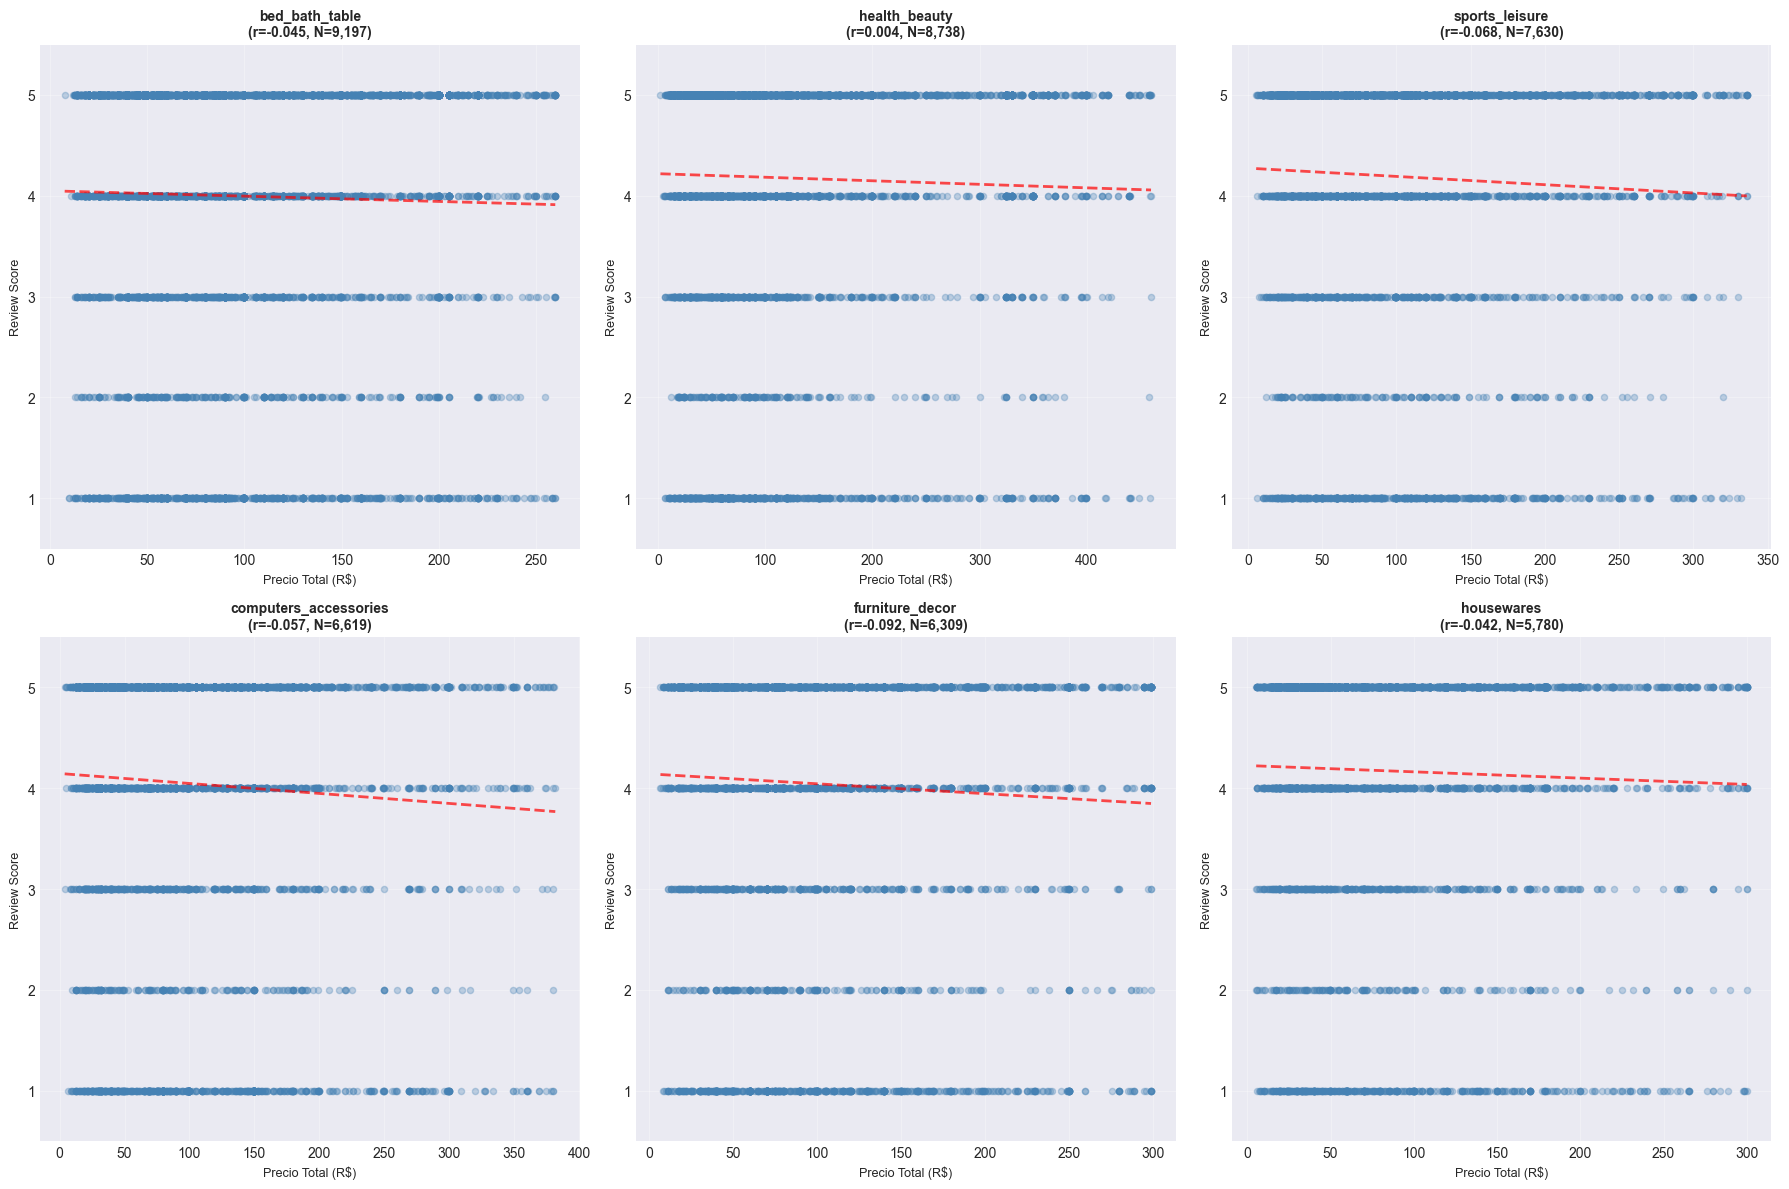


✓ Visualización guardada: 10_precio_satisfaccion_categorias.png


In [24]:
# Análisis: Correlación precio-satisfacción por categoría (Top 10)
if all(col in df.columns for col in ['product_category_english', 'total_price', 'review_score']):
    
    # Top 10 categorías por volumen
    top_10_cats = df['product_category_english'].value_counts().head(10).index
    df_top_10 = df[df['product_category_english'].isin(top_10_cats)].copy()
    
    # Calcular correlación por categoría
    correlations = []
    for cat in top_10_cats:
        cat_data = df_top_10[df_top_10['product_category_english'] == cat][['total_price', 'review_score']].dropna()
        if len(cat_data) > 30:  # Mínimo de observaciones
            corr_val = cat_data['total_price'].corr(cat_data['review_score'])
            correlations.append({
                'Categoría': cat,
                'Correlación': corr_val,
                'N': len(cat_data)
            })
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlación', key=abs, ascending=False)
    
    print("="*70)
    print("CORRELACIÓN PRECIO-SATISFACCIÓN POR CATEGORÍA")
    print("="*70)
    print("\nTop 10 categorías más populares:\n")
    display(corr_df)
    
    # Visualización: Scatterplots por categoría (2x3 grid)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, cat in enumerate(top_10_cats[:6]):  # Primeras 6 para visualización
        ax = axes[idx]
        cat_data = df_top_10[df_top_10['product_category_english'] == cat][['total_price', 'review_score']].dropna()
        
        # Limitar a percentil 95 para mejor visualización
        p95 = cat_data['total_price'].quantile(0.95)
        cat_data_filtered = cat_data[cat_data['total_price'] <= p95]
        
        ax.scatter(cat_data_filtered['total_price'], cat_data_filtered['review_score'], 
                   alpha=0.3, s=20, color='steelblue')
        
        # Línea de tendencia
        if len(cat_data_filtered) > 10:
            z = np.polyfit(cat_data_filtered['total_price'], cat_data_filtered['review_score'], 1)
            p = np.poly1d(z)
            ax.plot(sorted(cat_data_filtered['total_price']), 
                    p(sorted(cat_data_filtered['total_price'])), 
                    "r--", linewidth=2, alpha=0.7)
        
        # Correlación en el título
        corr_val = cat_data['total_price'].corr(cat_data['review_score'])
        ax.set_title(f'{cat[:30]}\n(r={corr_val:.3f}, N={len(cat_data):,})', 
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Precio Total (R$)', fontsize=9)
        ax.set_ylabel('Review Score', fontsize=9)
        ax.grid(alpha=0.3)
        ax.set_ylim(0.5, 5.5)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '10_precio_satisfaccion_categorias.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 10_precio_satisfaccion_categorias.png")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 5.3. Patrones Temporales por Categoría (Estacionalidad)

**Pregunta clave:** ¿Existen patrones estacionales en las ventas por categoría?  
**Relevancia:** Ajustar recomendaciones según temporada y categoría.

PATRONES TEMPORALES POR CATEGORÍA


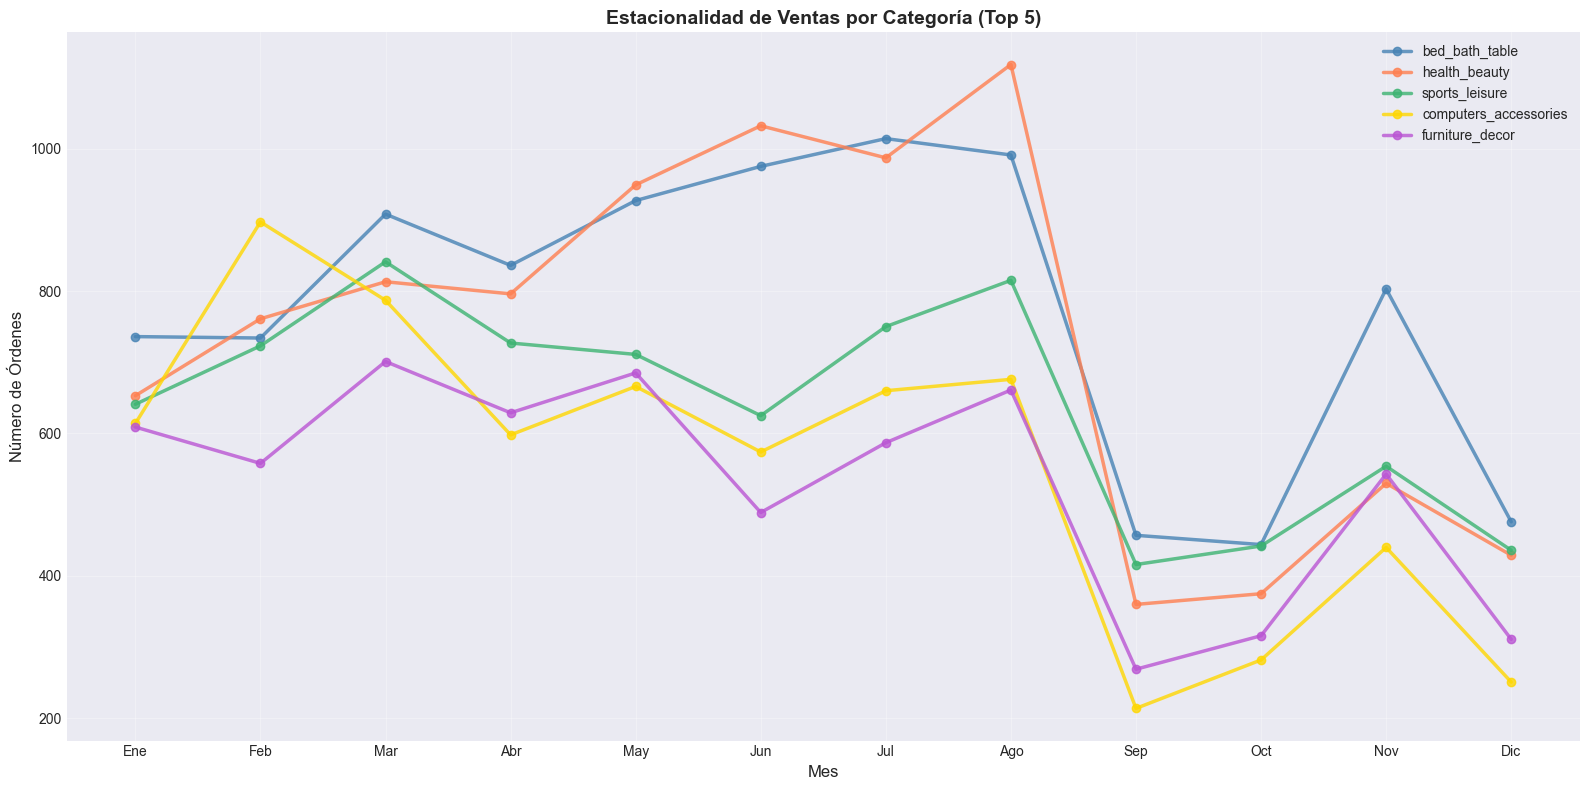


✓ Visualización guardada: 11_estacionalidad_categorias.png

MES PICO POR CATEGORÍA

bed_bath_table                           → Jul (1014 órdenes)
health_beauty                            → Ago (1118 órdenes)
sports_leisure                           → Mar (841 órdenes)
computers_accessories                    → Feb (897 órdenes)
furniture_decor                          → Mar (701 órdenes)


In [25]:
# Análisis: Ventas por mes para Top 5 categorías
if all(col in df.columns for col in ['product_category_english', 'purchase_month']):
    
    # Top 5 categorías
    top_5_cats = df['product_category_english'].value_counts().head(5).index
    
    # Crear tabla pivote: categoría x mes
    df_top_5 = df[df['product_category_english'].isin(top_5_cats)].copy()
    
    # Agrupar por mes y categoría
    monthly_sales = df_top_5.groupby(['purchase_month', 'product_category_english']).size().reset_index(name='orders')
    
    print("="*70)
    print("PATRONES TEMPORALES POR CATEGORÍA")
    print("="*70)
    
    # Visualización: Líneas temporales por categoría
    fig, ax = plt.subplots(figsize=(16, 8))
    
    colors = ['steelblue', 'coral', 'mediumseagreen', 'gold', 'mediumorchid']
    
    for idx, cat in enumerate(top_5_cats):
        cat_data = monthly_sales[monthly_sales['product_category_english'] == cat]
        ax.plot(cat_data['purchase_month'], cat_data['orders'], 
                marker='o', linewidth=2.5, label=cat, color=colors[idx], alpha=0.8)
    
    ax.set_xlabel('Mes', fontsize=12)
    ax.set_ylabel('Número de Órdenes', fontsize=12)
    ax.set_title('Estacionalidad de Ventas por Categoría (Top 5)', fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '11_estacionalidad_categorias.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 11_estacionalidad_categorias.png")
    
    # Identificar mes pico por categoría
    print(f"\n{'='*70}")
    print("MES PICO POR CATEGORÍA")
    print(f"{'='*70}\n")
    
    for cat in top_5_cats:
        cat_sales = monthly_sales[monthly_sales['product_category_english'] == cat]
        peak_month = cat_sales.loc[cat_sales['orders'].idxmax()]
        month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                       'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
        print(f"{cat[:40]:<40} → {month_names[int(peak_month['purchase_month'])-1]} ({int(peak_month['orders'])} órdenes)")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 5.4. Distribución Geográfica de Categorías

**Pregunta clave:** ¿Existen preferencias regionales de categorías de productos?  
**Relevancia:** Recomendaciones geo-localizadas según preferencias estatales.

PREFERENCIAS DE CATEGORÍAS POR ESTADO (Top 5 x Top 5)

Distribución porcentual de categorías por estado:



product_category_english,bed_bath_table,computers_accessories,furniture_decor,health_beauty,sports_leisure
customer_state,,,,,
MG,24.35,19.08,15.67,22.01,18.89
PR,20.49,17.48,20.18,19.71,22.15
RJ,27.76,17.22,16.98,19.58,18.45
RS,24.61,17.79,20.14,18.16,19.31
SP,26.03,15.91,16.04,22.48,19.54


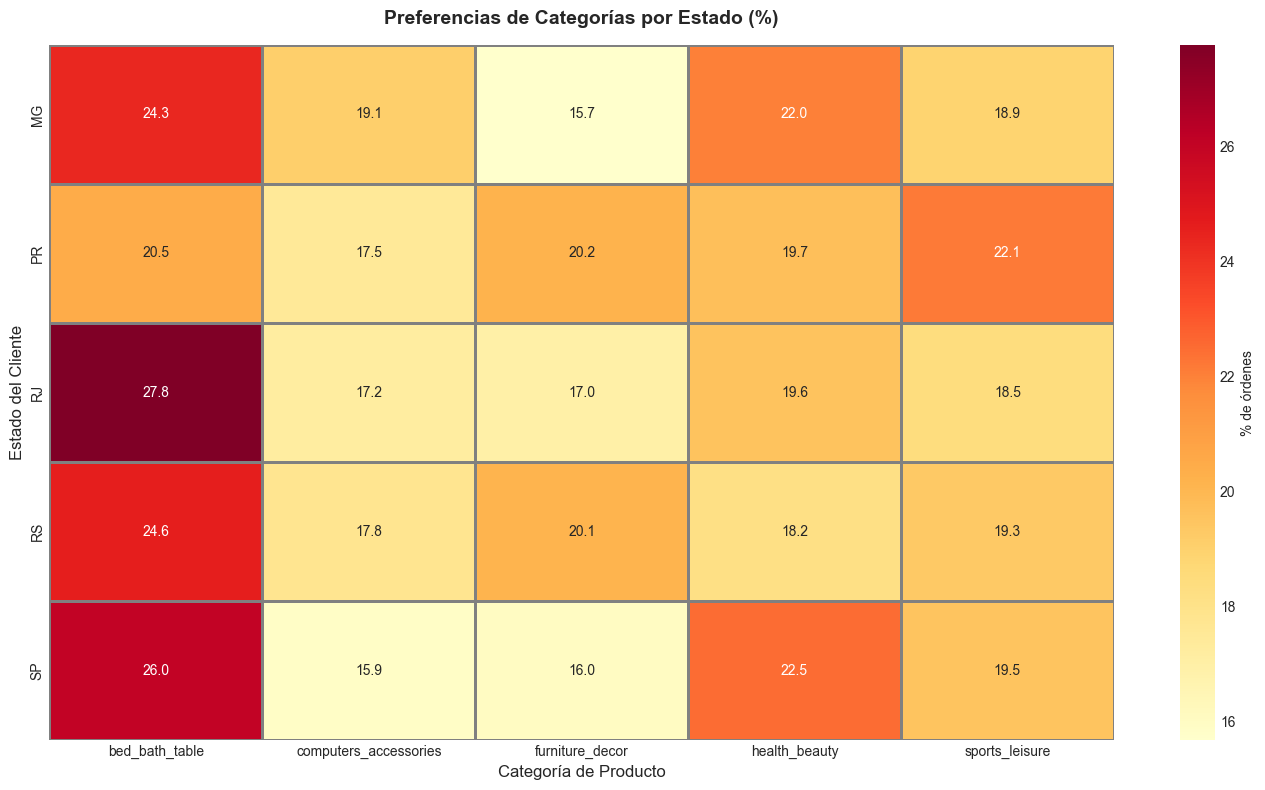


✓ Visualización guardada: 12_preferencias_geograficas.png

CATEGORÍA MÁS POPULAR POR ESTADO

SP → bed_bath_table (26.0%)
RJ → bed_bath_table (27.8%)
MG → bed_bath_table (24.3%)
RS → bed_bath_table (24.6%)
PR → sports_leisure (22.1%)


In [26]:
# Análisis: Preferencias de categorías por estado (Top 5 estados y Top 5 categorías)
if all(col in df.columns for col in ['customer_state', 'product_category_english']):
    
    # Top 5 estados
    top_5_states = df['customer_state'].value_counts().head(5).index
    
    # Top 5 categorías
    top_5_cats = df['product_category_english'].value_counts().head(5).index
    
    # Filtrar datos
    df_geo = df[df['customer_state'].isin(top_5_states) & 
                df['product_category_english'].isin(top_5_cats)].copy()
    
    # Tabla cruzada: estado x categoría
    crosstab = pd.crosstab(df_geo['customer_state'], 
                           df_geo['product_category_english'], 
                           normalize='index') * 100
    
    print("="*70)
    print("PREFERENCIAS DE CATEGORÍAS POR ESTADO (Top 5 x Top 5)")
    print("="*70)
    print("\nDistribución porcentual de categorías por estado:\n")
    display(crosstab.round(2))
    
    # Visualización: Heatmap de preferencias
    fig, ax = plt.subplots(figsize=(14, 8))
    
    sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': '% de órdenes'}, linewidths=1, 
                linecolor='gray', ax=ax)
    
    ax.set_title('Preferencias de Categorías por Estado (%)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Categoría de Producto', fontsize=12)
    ax.set_ylabel('Estado del Cliente', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '12_preferencias_geograficas.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 12_preferencias_geograficas.png")
    
    # Identificar categoría más popular por estado
    print(f"\n{'='*70}")
    print("CATEGORÍA MÁS POPULAR POR ESTADO")
    print(f"{'='*70}\n")
    
    for state in top_5_states:
        top_cat = crosstab.loc[state].idxmax()
        top_pct = crosstab.loc[state].max()
        print(f"{state} → {top_cat[:40]} ({top_pct:.1f}%)")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 5.5. Comportamiento de Compra por Método de Pago

**Pregunta clave:** ¿El método de pago influye en el valor de compra y satisfacción?  
**Relevancia:** Optimizar experiencia de checkout y recomendaciones según método de pago.

COMPORTAMIENTO DE COMPRA POR MÉTODO DE PAGO



,N_Orders,Avg_Value,Median_Value,Std_Value,Avg_Review,Median_Review,Pct_Installments
primary_payment_type,,,,,,,
credit_card,76132,166.57,109.07,224.25,4.09,5.00,0.67
boleto,19784,145.03,93.89,213.58,4.09,5.00,0.00
voucher,1994,120.66,77.25,179.60,3.96,5.00,0.04
debit_card,1527,142.72,89.30,245.92,4.17,5.00,0.00
not_defined,3,0.00,0.00,0.00,1.67,1.00,0.00


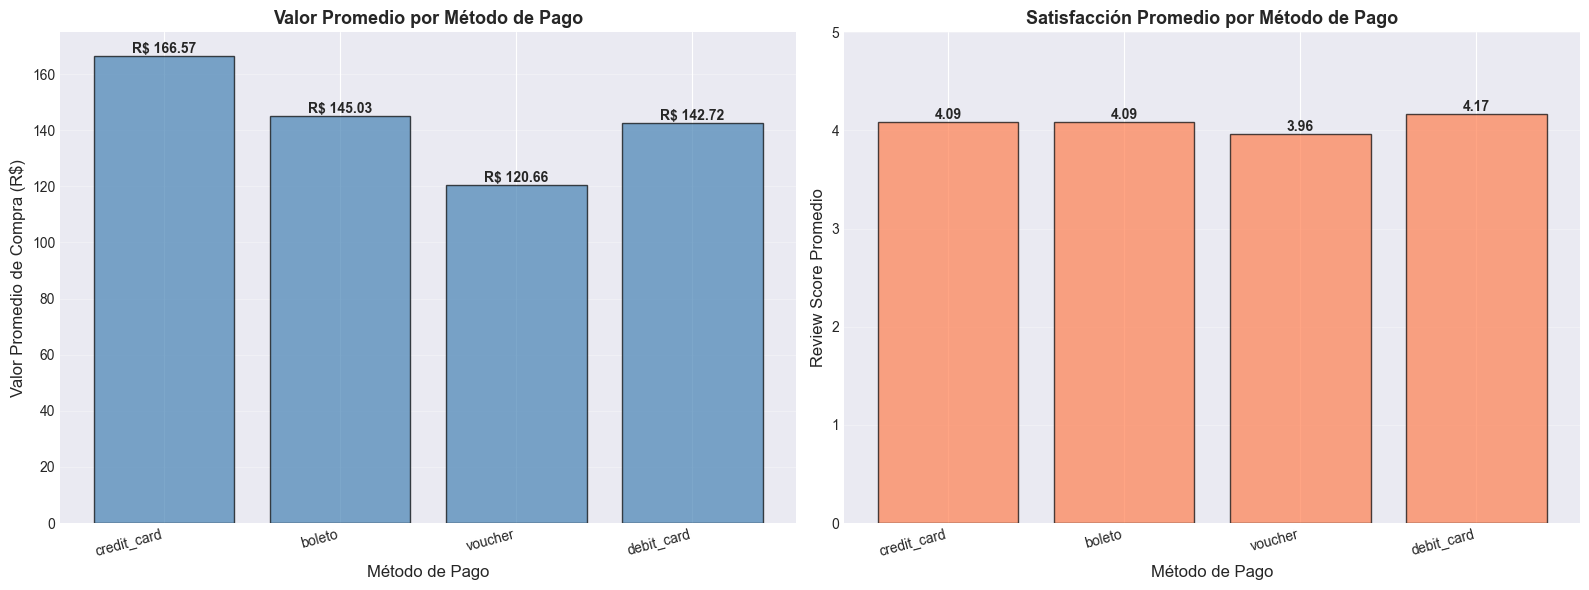


✓ Visualización guardada: 13_comportamiento_metodo_pago.png


In [27]:
# Análisis: Comportamiento por método de pago
if all(col in df.columns for col in ['primary_payment_type', 'total_payment_value', 'review_score', 'uses_installments']):
    
    # Agregar estadísticas por método de pago
    payment_stats = df.groupby('primary_payment_type').agg({
        'order_id': 'count',
        'total_payment_value': ['mean', 'median', 'std'],
        'review_score': ['mean', 'median'],
        'uses_installments': 'mean'  # Proporción que usa cuotas
    }).round(2)
    
    payment_stats.columns = ['N_Orders', 'Avg_Value', 'Median_Value', 'Std_Value', 
                             'Avg_Review', 'Median_Review', 'Pct_Installments']
    payment_stats = payment_stats.sort_values('N_Orders', ascending=False)
    
    print("="*70)
    print("COMPORTAMIENTO DE COMPRA POR MÉTODO DE PAGO")
    print("="*70)
    print()
    display(payment_stats)
    
    # Visualización: Comparación de valor y satisfacción por método de pago
    payment_types = payment_stats.head(4).index  # Top 4 métodos
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Subplot 1: Valor promedio por método
    ax1 = axes[0]
    payment_stats_top4 = payment_stats.loc[payment_types]
    bars1 = ax1.bar(range(len(payment_types)), payment_stats_top4['Avg_Value'], 
                    color='steelblue', alpha=0.7, edgecolor='black')
    
    # Etiquetas en las barras
    for idx, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'R$ {height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax1.set_xlabel('Método de Pago', fontsize=12)
    ax1.set_ylabel('Valor Promedio de Compra (R$)', fontsize=12)
    ax1.set_title('Valor Promedio por Método de Pago', fontsize=13, fontweight='bold')
    ax1.set_xticks(range(len(payment_types)))
    ax1.set_xticklabels(payment_types, rotation=15, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    
    # Subplot 2: Review score promedio por método
    ax2 = axes[1]
    bars2 = ax2.bar(range(len(payment_types)), payment_stats_top4['Avg_Review'], 
                    color='coral', alpha=0.7, edgecolor='black')
    
    # Etiquetas en las barras
    for idx, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_xlabel('Método de Pago', fontsize=12)
    ax2.set_ylabel('Review Score Promedio', fontsize=12)
    ax2.set_title('Satisfacción Promedio por Método de Pago', fontsize=13, fontweight='bold')
    ax2.set_xticks(range(len(payment_types)))
    ax2.set_xticklabels(payment_types, rotation=15, ha='right')
    ax2.set_ylim(0, 5)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '13_comportamiento_metodo_pago.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 13_comportamiento_metodo_pago.png")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 5.6. Análisis Multivariable de Atributos de Producto

**Pregunta clave:** ¿Cómo se relacionan precio, peso y dimensiones de productos?  
**Relevancia:** Identificar patrones para recomendaciones basadas en contenido (Canal A).

ANÁLISIS MULTIVARIABLE DE ATRIBUTOS DE PRODUCTO

Muestra analizada: 5,000 productos

Matriz de Correlación:


,total_price,product_weight_grams,product_volume_cm3
total_price,1.00,0.25,0.17
product_weight_grams,0.25,1.00,0.59
product_volume_cm3,0.17,0.59,1.00


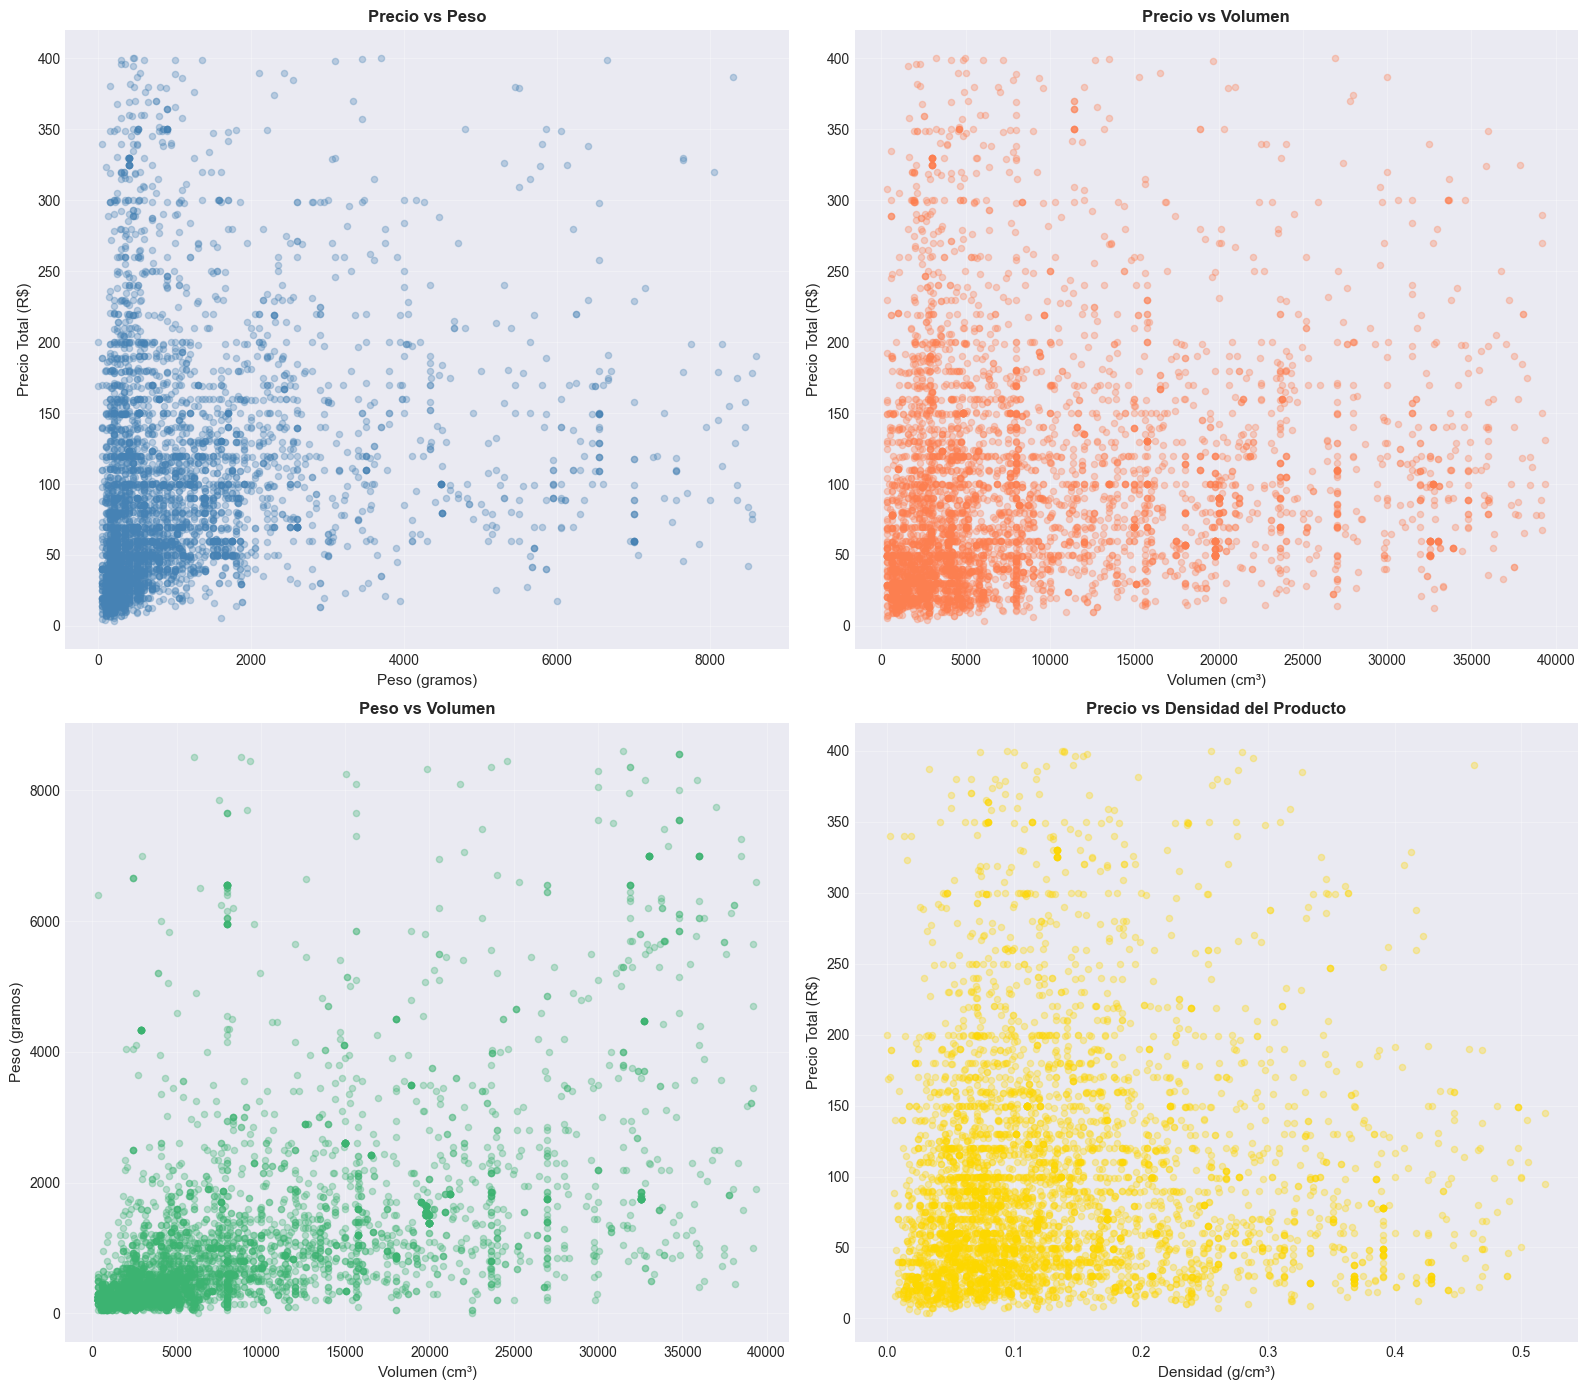


✓ Visualización guardada: 14_atributos_producto_multivariable.png

PRODUCTOS POR DENSIDAD (Top 5 más densos)


,total_price,product_weight_grams,product_volume_cm3,density
90828,95.00,4150.00,8000.00,0.52
1837,145.00,8100.00,15625.00,0.52
92911,110.40,2600.00,5148.00,0.51
89576,139.90,2967.00,5880.00,0.50
33618,99.00,2000.00,4000.00,0.50


In [28]:
# Análisis: Relaciones entre atributos físicos de productos
if all(col in df.columns for col in ['total_price', 'product_weight_grams', 
                                       'product_length_cm', 'product_height_cm', 'product_width_cm']):
    
    # Calcular volumen del producto (cm³)
    df_products = df[['total_price', 'product_weight_grams', 
                      'product_length_cm', 'product_height_cm', 'product_width_cm']].copy()
    
    df_products['product_volume_cm3'] = (df_products['product_length_cm'] * 
                                         df_products['product_height_cm'] * 
                                         df_products['product_width_cm'])
    
    # Eliminar valores nulos y outliers extremos (percentil 95)
    df_products = df_products.dropna()
    
    for col in ['total_price', 'product_weight_grams', 'product_volume_cm3']:
        p95 = df_products[col].quantile(0.95)
        df_products = df_products[df_products[col] <= p95]
    
    # Muestra aleatoria para visualización (5000 puntos)
    df_sample = df_products.sample(min(5000, len(df_products)), random_state=42)
    
    print("="*70)
    print("ANÁLISIS MULTIVARIABLE DE ATRIBUTOS DE PRODUCTO")
    print("="*70)
    print(f"\nMuestra analizada: {len(df_sample):,} productos")
    
    # Correlaciones entre atributos
    corr_matrix = df_sample[['total_price', 'product_weight_grams', 'product_volume_cm3']].corr()
    print("\nMatriz de Correlación:")
    display(corr_matrix.round(3))
    
    # Visualización: Pairplot de atributos clave
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # Subplot 1: Precio vs Peso
    ax1 = axes[0, 0]
    ax1.scatter(df_sample['product_weight_grams'], df_sample['total_price'], 
                alpha=0.3, s=20, c='steelblue')
    ax1.set_xlabel('Peso (gramos)', fontsize=11)
    ax1.set_ylabel('Precio Total (R$)', fontsize=11)
    ax1.set_title('Precio vs Peso', fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    # Subplot 2: Precio vs Volumen
    ax2 = axes[0, 1]
    ax2.scatter(df_sample['product_volume_cm3'], df_sample['total_price'], 
                alpha=0.3, s=20, c='coral')
    ax2.set_xlabel('Volumen (cm³)', fontsize=11)
    ax2.set_ylabel('Precio Total (R$)', fontsize=11)
    ax2.set_title('Precio vs Volumen', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    # Subplot 3: Peso vs Volumen
    ax3 = axes[1, 0]
    ax3.scatter(df_sample['product_volume_cm3'], df_sample['product_weight_grams'], 
                alpha=0.3, s=20, c='mediumseagreen')
    ax3.set_xlabel('Volumen (cm³)', fontsize=11)
    ax3.set_ylabel('Peso (gramos)', fontsize=11)
    ax3.set_title('Peso vs Volumen', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # Subplot 4: Densidad (peso/volumen) vs Precio
    ax4 = axes[1, 1]
    # Calcular densidad (peso por cm³)
    df_sample_density = df_sample[df_sample['product_volume_cm3'] > 0].copy()
    df_sample_density['density'] = df_sample_density['product_weight_grams'] / df_sample_density['product_volume_cm3']
    
    # Filtrar outliers extremos de densidad
    density_p95 = df_sample_density['density'].quantile(0.95)
    df_sample_density = df_sample_density[df_sample_density['density'] <= density_p95]
    
    ax4.scatter(df_sample_density['density'], df_sample_density['total_price'], 
                alpha=0.3, s=20, c='gold')
    ax4.set_xlabel('Densidad (g/cm³)', fontsize=11)
    ax4.set_ylabel('Precio Total (R$)', fontsize=11)
    ax4.set_title('Precio vs Densidad del Producto', fontsize=12, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '14_atributos_producto_multivariable.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 14_atributos_producto_multivariable.png")
    
    # Insights: productos con mayor densidad
    print(f"\n{'='*70}")
    print("PRODUCTOS POR DENSIDAD (Top 5 más densos)")
    print(f"{'='*70}")
    top_density = df_sample_density.nlargest(5, 'density')[['total_price', 'product_weight_grams', 
                                                              'product_volume_cm3', 'density']]
    display(top_density.round(2))
    
else:
    print("⚠️ Columnas necesarias no encontradas")

---

## FASE 6: Análisis de Sparsity (CRÍTICO)

⏱️ **Tiempo estimado:** 2.0 horas

**⚠️ FASE CRÍTICA:** Este análisis valida la viabilidad de la arquitectura item-to-item propuesta. La sparsity de la matriz cliente-producto determina qué canal de recomendación (A o B) será más efectivo.

### 6.1. Construcción de Matriz Cliente-Producto

**Pregunta clave:** ¿Qué tan dispersa es la matriz de interacciones cliente-producto?  
**Relevancia:** Determina la viabilidad del collaborative filtering (Canal B) vs content-based (Canal A).

In [29]:
# Análisis: Sparsity de la matriz cliente-producto
if all(col in df.columns for col in ['customer_unique_id', 'primary_product_id']):
    
    print("="*70)
    print("ANÁLISIS DE SPARSITY - MATRIZ CLIENTE-PRODUCTO")
    print("="*70)
    
    # Contar clientes y productos únicos
    n_customers = df['customer_unique_id'].nunique()
    n_products = df['primary_product_id'].nunique()
    
    # Total de interacciones (órdenes únicas cliente-producto)
    interactions = df.groupby(['customer_unique_id', 'primary_product_id']).size().reset_index(name='count')
    n_interactions = len(interactions)
    
    # Tamaño teórico de la matriz
    matrix_size = n_customers * n_products
    
    # Cálculo de sparsity
    sparsity = (1 - (n_interactions / matrix_size)) * 100
    density = (n_interactions / matrix_size) * 100
    
    print(f"\n1. DIMENSIONES DE LA MATRIZ:")
    print(f"   - Clientes únicos:        {n_customers:>10,}")
    print(f"   - Productos únicos:       {n_products:>10,}")
    print(f"   - Tamaño matriz teórico:  {matrix_size:>10,} celdas")
    
    print(f"\n2. INTERACCIONES REALES:")
    print(f"   - Interacciones totales:  {n_interactions:>10,}")
    print(f"   - Promedio/cliente:       {n_interactions/n_customers:>10.2f}")
    print(f"   - Promedio/producto:      {n_interactions/n_products:>10.2f}")
    
    print(f"\n3. SPARSITY METRICS:")
    print(f"   - Density (% lleno):      {density:>10.4f}%")
    print(f"   - Sparsity (% vacío):     {sparsity:>10.4f}%")
    
    # Interpretación según thresholds estándar
    print(f"\n4. INTERPRETACIÓN:")
    if sparsity > 99.5:
        print("   ⚠️  EXTREMADAMENTE SPARSE (>99.5%)")
        print("   → Collaborative filtering será muy desafiante")
        print("   → Priorizar Canal A (content-based) fuertemente")
    elif sparsity > 99.0:
        print("   ⚠️  MUY SPARSE (99.0-99.5%)")
        print("   → Collaborative filtering limitado")
        print("   → Canal A (content-based) como principal, Canal B como complemento")
    elif sparsity > 95.0:
        print("   ✓  MODERADAMENTE SPARSE (95.0-99.0%)")
        print("   → Collaborative filtering viable con técnicas avanzadas")
        print("   → Balance entre Canal A y Canal B")
    else:
        print("   ✓✓ RELATIVAMENTE DENSO (<95%)")
        print("   → Excelente para collaborative filtering")
        print("   → Ambos canales viables")
    
    # Almacenar métricas clave para siguientes análisis
    sparsity_metrics = {
        'n_customers': n_customers,
        'n_products': n_products,
        'n_interactions': n_interactions,
        'sparsity': sparsity,
        'density': density
    }
    
else:
    print("⚠️ Columnas necesarias no encontradas")

ANÁLISIS DE SPARSITY - MATRIZ CLIENTE-PRODUCTO

1. DIMENSIONES DE LA MATRIZ:
   - Clientes únicos:            96,096
   - Productos únicos:           31,847
   - Tamaño matriz teórico:  3,060,369,312 celdas

2. INTERACCIONES REALES:
   - Interacciones totales:      98,252
   - Promedio/cliente:             1.02
   - Promedio/producto:            3.09

3. SPARSITY METRICS:
   - Density (% lleno):          0.0032%
   - Sparsity (% vacío):        99.9968%

4. INTERPRETACIÓN:
   ⚠️  EXTREMADAMENTE SPARSE (>99.5%)
   → Collaborative filtering será muy desafiante
   → Priorizar Canal A (content-based) fuertemente


### 6.2. Distribución de Compras por Cliente

**Pregunta clave:** ¿Cómo se distribuyen las compras? ¿Hay clientes recurrentes suficientes?  
**Relevancia:** Clientes con pocas compras limitan el collaborative filtering.

DISTRIBUCIÓN DE COMPRAS POR CLIENTE

1. ESTADÍSTICAS DESCRIPTIVAS:
   - Media:      1.03 órdenes/cliente
   - Mediana:    1 órdenes/cliente
   - Moda:       1 órdenes/cliente
   - Máximo:     17 órdenes/cliente

2. SEGMENTACIÓN DE CLIENTES:
   - 1 compra:      93,099 ( 96.9%)
   - 2 compras:      2,745 (  2.9%)
   - 3+ compras:       252 (  0.3%)
   - 5+ compras:        19 (  0.0%)

3. DISTRIBUCIÓN DE FRECUENCIA (Top 10):
    1 órdenes: 93,099 clientes ( 96.9%)
    2 órdenes:  2,745 clientes (  2.9%)
    3 órdenes:    203 clientes (  0.2%)
    4 órdenes:     30 clientes (  0.0%)
    5 órdenes:      8 clientes (  0.0%)
    6 órdenes:      6 clientes (  0.0%)
    7 órdenes:      3 clientes (  0.0%)
    9 órdenes:      1 clientes (  0.0%)
   17 órdenes:      1 clientes (  0.0%)


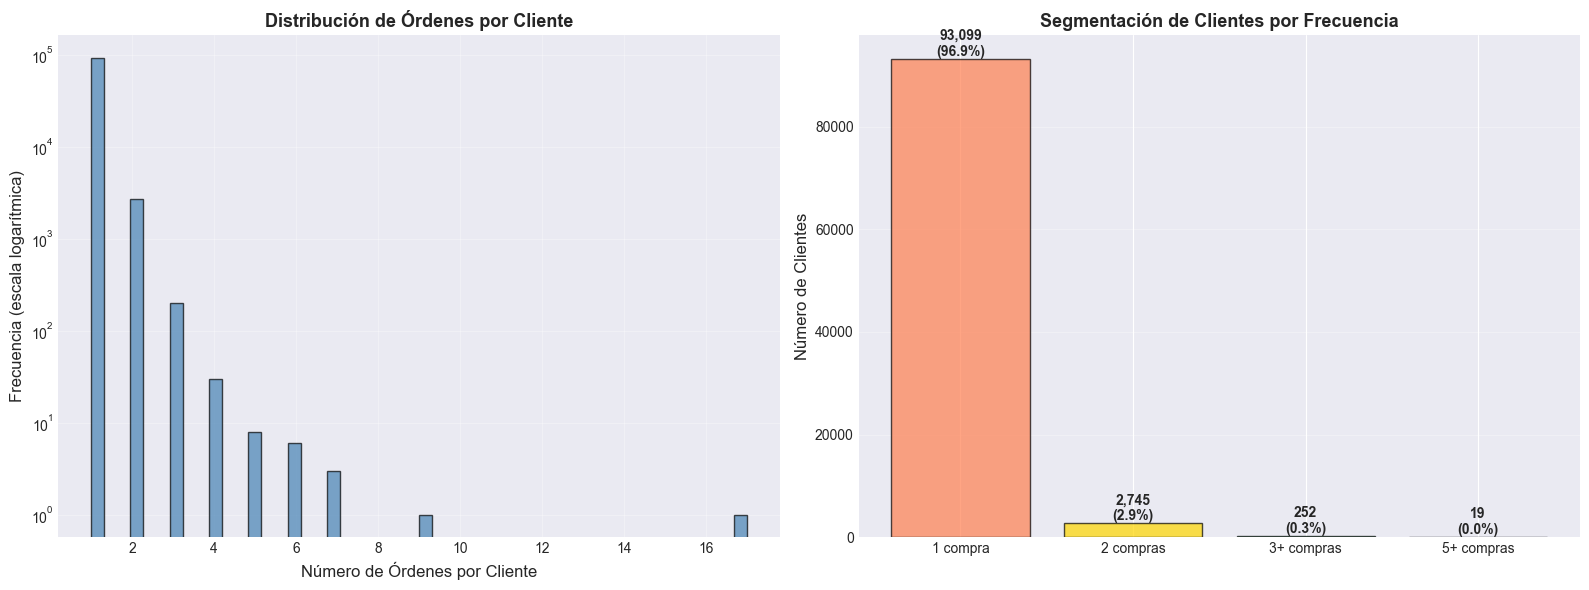


✓ Visualización guardada: 15_distribucion_compras_cliente.png

4. IMPACTO EN SPARSITY:
   ⚠️  >95% clientes con 1 sola compra → Cold start severo


In [30]:
# Análisis: Distribución de órdenes por cliente
if 'customer_unique_id' in df.columns:
    
    # Contar órdenes por cliente
    orders_per_customer = df.groupby('customer_unique_id')['order_id'].count().reset_index(name='n_orders')
    
    print("="*70)
    print("DISTRIBUCIÓN DE COMPRAS POR CLIENTE")
    print("="*70)
    
    # Estadísticas descriptivas
    print("\n1. ESTADÍSTICAS DESCRIPTIVAS:")
    print(f"   - Media:      {orders_per_customer['n_orders'].mean():.2f} órdenes/cliente")
    print(f"   - Mediana:    {orders_per_customer['n_orders'].median():.0f} órdenes/cliente")
    print(f"   - Moda:       {orders_per_customer['n_orders'].mode()[0]:.0f} órdenes/cliente")
    print(f"   - Máximo:     {orders_per_customer['n_orders'].max():.0f} órdenes/cliente")
    
    # Segmentos de clientes
    one_order = (orders_per_customer['n_orders'] == 1).sum()
    two_orders = (orders_per_customer['n_orders'] == 2).sum()
    three_plus = (orders_per_customer['n_orders'] >= 3).sum()
    five_plus = (orders_per_customer['n_orders'] >= 5).sum()
    
    total_customers = len(orders_per_customer)
    
    print(f"\n2. SEGMENTACIÓN DE CLIENTES:")
    print(f"   - 1 compra:     {one_order:>7,} ({one_order/total_customers*100:>5.1f}%)")
    print(f"   - 2 compras:    {two_orders:>7,} ({two_orders/total_customers*100:>5.1f}%)")
    print(f"   - 3+ compras:   {three_plus:>7,} ({three_plus/total_customers*100:>5.1f}%)")
    print(f"   - 5+ compras:   {five_plus:>7,} ({five_plus/total_customers*100:>5.1f}%)")
    
    # Distribución de frecuencia
    freq_dist = orders_per_customer['n_orders'].value_counts().sort_index()
    
    print(f"\n3. DISTRIBUCIÓN DE FRECUENCIA (Top 10):")
    for n_orders, count in freq_dist.head(10).items():
        pct = count / total_customers * 100
        print(f"   {n_orders:2.0f} órdenes: {count:>6,} clientes ({pct:>5.1f}%)")
    
    # Visualización: Histograma de distribución
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Subplot 1: Histograma completo (log scale)
    ax1 = axes[0]
    orders_per_customer['n_orders'].hist(bins=50, ax=ax1, color='steelblue', 
                                         alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Número de Órdenes por Cliente', fontsize=12)
    ax1.set_ylabel('Frecuencia (escala logarítmica)', fontsize=12)
    ax1.set_title('Distribución de Órdenes por Cliente', fontsize=13, fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(alpha=0.3)
    
    # Subplot 2: Barplot de segmentos clave
    ax2 = axes[1]
    segments = ['1 compra', '2 compras', '3+ compras', '5+ compras']
    counts = [one_order, two_orders, three_plus, five_plus]
    bars = ax2.bar(segments, counts, color=['coral', 'gold', 'mediumseagreen', 'steelblue'], 
                   alpha=0.7, edgecolor='black')
    
    # Etiquetas en las barras
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}\n({height/total_customers*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_ylabel('Número de Clientes', fontsize=12)
    ax2.set_title('Segmentación de Clientes por Frecuencia', fontsize=13, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '15_distribucion_compras_cliente.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 15_distribucion_compras_cliente.png")
    
    # Conclusión para sparsity
    print(f"\n4. IMPACTO EN SPARSITY:")
    if one_order / total_customers > 0.95:
        print("   ⚠️  >95% clientes con 1 sola compra → Cold start severo")
    elif one_order / total_customers > 0.90:
        print("   ⚠️  >90% clientes con 1 sola compra → Cold start significativo")
    else:
        print("   ✓  Distribución aceptable para collaborative filtering")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 6.3. Distribución de Ventas por Producto

**Pregunta clave:** ¿Hay productos populares o la distribución es muy uniforme?  
**Relevancia:** Productos con pocas ventas son difíciles de recomendar (cold start).

DISTRIBUCIÓN DE VENTAS POR PRODUCTO

1. ESTADÍSTICAS DESCRIPTIVAS:
   - Media:      3.10 ventas/producto
   - Mediana:    1 ventas/producto
   - Moda:       1 ventas/producto
   - Máximo:     429 ventas/producto

2. SEGMENTACIÓN DE PRODUCTOS:
   - 1 venta:       18,956 ( 59.5%)
   - 2-5 ventas:     9,704 ( 30.5%)
   - 6-10 ventas:    1,786 (  5.6%)
   - 11+ ventas:     1,401 (  4.4%)

3. TOP 20 PRODUCTOS MÁS VENDIDOS:
   Producto aca2eb7d00ea1a7... :  429 ventas
   Producto 99a4788cb248569... :  427 ventas
   Producto 422879e10f46682... :  339 ventas
   Producto d1c427060a0f73f... :  311 ventas
   Producto 53b36df67ebb7c4... :  303 ventas
   Producto 389d119b48cf304... :  299 ventas
   Producto 368c6c730842d78... :  285 ventas
   Producto 154e7e31ebfa092... :  269 ventas
   Producto 53759a2ecddad2b... :  264 ventas
   Producto 2b4609f8948be18... :  258 ventas
   Producto 3dd2a17168ec895... :  255 ventas
   Producto 7c1bd920dbdf224... :  221 ventas
   Producto 5a848e4ab52fd54... :  194 

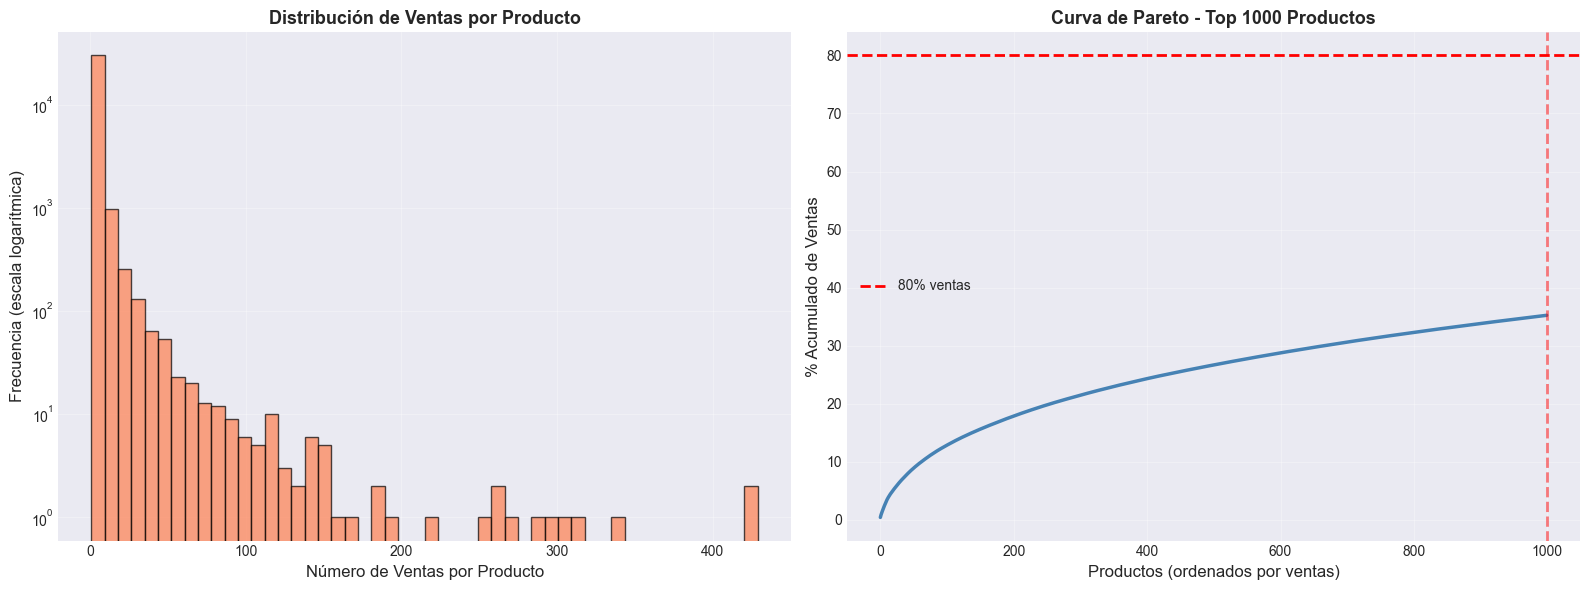


✓ Visualización guardada: 16_distribucion_ventas_producto.png

5. IMPACTO EN SPARSITY:
   ⚠️  59.5% productos con 1 sola venta → Cold start alto


In [31]:
# Análisis: Distribución de órdenes por producto
if 'primary_product_id' in df.columns:
    
    # Contar órdenes por producto
    orders_per_product = df.groupby('primary_product_id')['order_id'].count().reset_index(name='n_orders')
    
    print("="*70)
    print("DISTRIBUCIÓN DE VENTAS POR PRODUCTO")
    print("="*70)
    
    # Estadísticas descriptivas
    print("\n1. ESTADÍSTICAS DESCRIPTIVAS:")
    print(f"   - Media:      {orders_per_product['n_orders'].mean():.2f} ventas/producto")
    print(f"   - Mediana:    {orders_per_product['n_orders'].median():.0f} ventas/producto")
    print(f"   - Moda:       {orders_per_product['n_orders'].mode()[0]:.0f} ventas/producto")
    print(f"   - Máximo:     {orders_per_product['n_orders'].max():.0f} ventas/producto")
    
    # Segmentos de productos
    one_sale = (orders_per_product['n_orders'] == 1).sum()
    two_five = ((orders_per_product['n_orders'] >= 2) & (orders_per_product['n_orders'] <= 5)).sum()
    six_ten = ((orders_per_product['n_orders'] >= 6) & (orders_per_product['n_orders'] <= 10)).sum()
    eleven_plus = (orders_per_product['n_orders'] > 10).sum()
    
    total_products = len(orders_per_product)
    
    print(f"\n2. SEGMENTACIÓN DE PRODUCTOS:")
    print(f"   - 1 venta:      {one_sale:>7,} ({one_sale/total_products*100:>5.1f}%)")
    print(f"   - 2-5 ventas:   {two_five:>7,} ({two_five/total_products*100:>5.1f}%)")
    print(f"   - 6-10 ventas:  {six_ten:>7,} ({six_ten/total_products*100:>5.1f}%)")
    print(f"   - 11+ ventas:   {eleven_plus:>7,} ({eleven_plus/total_products*100:>5.1f}%)")
    
    # Top productos más vendidos
    top_20_products = orders_per_product.nlargest(20, 'n_orders')
    
    print(f"\n3. TOP 20 PRODUCTOS MÁS VENDIDOS:")
    for idx, row in top_20_products.iterrows():
        print(f"   Producto {row['primary_product_id'][:15]:>15}... : {int(row['n_orders']):>4} ventas")
    
    # Concentración de ventas (Pareto)
    orders_per_product_sorted = orders_per_product.sort_values('n_orders', ascending=False)
    orders_per_product_sorted['cumsum'] = orders_per_product_sorted['n_orders'].cumsum()
    total_sales = orders_per_product_sorted['n_orders'].sum()
    orders_per_product_sorted['cumsum_pct'] = (orders_per_product_sorted['cumsum'] / total_sales) * 100
    
    # ¿Cuántos productos generan el 80% de las ventas?
    products_80pct = (orders_per_product_sorted['cumsum_pct'] <= 80).sum()
    pct_products_80 = (products_80pct / total_products) * 100
    
    print(f"\n4. CONCENTRACIÓN (ANÁLISIS PARETO):")
    print(f"   - El {pct_products_80:.1f}% de productos genera el 80% de ventas")
    print(f"   - {products_80pct:,} productos concentran mayoría de ventas")
    
    # Visualización: Distribución y Pareto
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Subplot 1: Histograma de distribución (log scale)
    ax1 = axes[0]
    orders_per_product['n_orders'].hist(bins=50, ax=ax1, color='coral', 
                                        alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Número de Ventas por Producto', fontsize=12)
    ax1.set_ylabel('Frecuencia (escala logarítmica)', fontsize=12)
    ax1.set_title('Distribución de Ventas por Producto', fontsize=13, fontweight='bold')
    ax1.set_yscale('log')
    ax1.grid(alpha=0.3)
    
    # Subplot 2: Curva de Pareto (Top 1000 productos)
    ax2 = axes[1]
    top_1000 = orders_per_product_sorted.head(1000)
    ax2.plot(range(len(top_1000)), top_1000['cumsum_pct'].values, 
             linewidth=2.5, color='steelblue')
    ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% ventas')
    ax2.axvline(x=products_80pct if products_80pct <= 1000 else 1000, 
                color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax2.set_xlabel('Productos (ordenados por ventas)', fontsize=12)
    ax2.set_ylabel('% Acumulado de Ventas', fontsize=12)
    ax2.set_title('Curva de Pareto - Top 1000 Productos', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '16_distribucion_ventas_producto.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 16_distribucion_ventas_producto.png")
    
    # Conclusión para sparsity
    print(f"\n5. IMPACTO EN SPARSITY:")
    if one_sale / total_products > 0.50:
        print(f"   ⚠️  {one_sale/total_products*100:.1f}% productos con 1 sola venta → Cold start alto")
    else:
        print("   ✓  Distribución aceptable para recomendación")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 6.4. Análisis de Co-ocurrencia de Productos

**Pregunta clave:** ¿Hay suficiente overlap de productos entre clientes?  
**Relevancia:** Sin overlap, el collaborative filtering item-to-item no puede encontrar similitudes.

ANÁLISIS DE CO-OCURRENCIA DE PRODUCTOS

1. CLIENTES RECURRENTES (≥2 compras):
   - Total clientes recurrentes:    2,997 (3.1%)
   - Órdenes de recurrentes:        6,342

2. ANÁLISIS DE PARES (Top 100 productos):
   - Total pares únicos encontrados:       33
   - Total co-ocurrencias:                 89

3. TOP 10 PARES MÁS FRECUENTES:
    1. 154e7e31ebfa... + 2b4609f8948b... :  18 veces
    2. 36f60d45225e... + 3f14d740544f... :  14 veces
    3. 36f60d45225e... + e53e557d5a15... :  14 veces
    4. 154e7e31ebfa... + 7c1bd920dbdf... :  11 veces
    5. 2028bf1b01ca... + 75d6b6963340... :   2 veces
    6. 389d119b48cf... + 422879e10f46... :   2 veces
    7. 19c91ef95d50... + 3fbc0ef74595... :   2 veces
    8. 84f456958365... + ec2d43cc5976... :   1 veces
    9. 43423cdffde7... + a92930c32794... :   1 veces
   10. 29427de7f8a9... + 4fe644d766c7... :   1 veces

4. ESTADÍSTICAS DE CO-OCURRENCIA:
   - Promedio co-ocurrencias/par:      2.70
   - Mediana co-ocurrencias/par:          1
   - Máxim

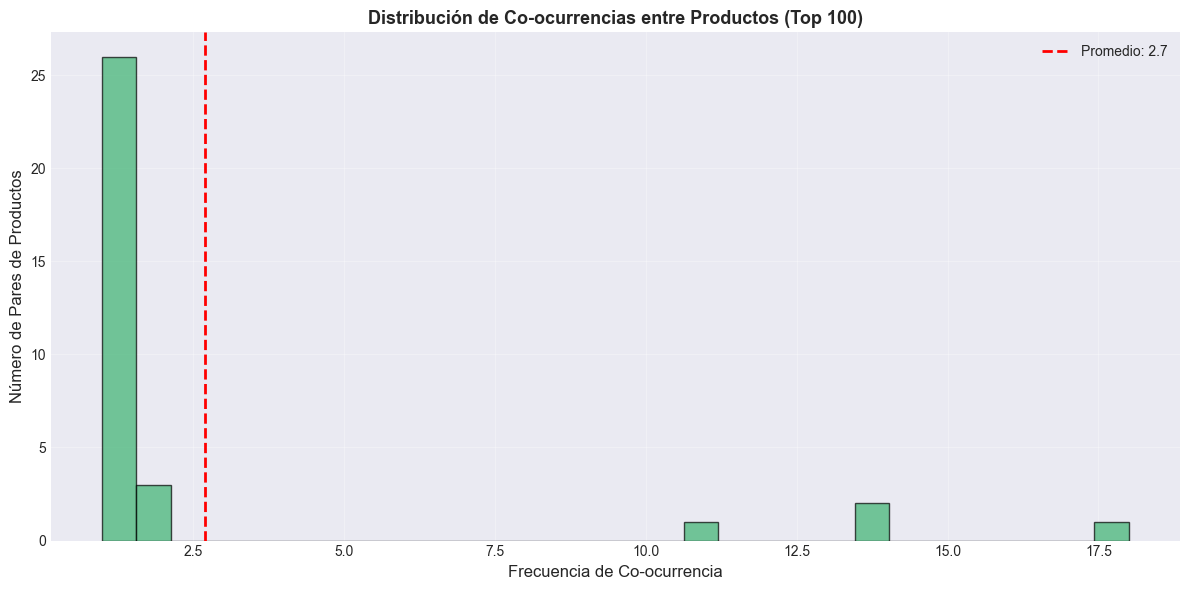


✓ Visualización guardada: 17_coocurrencia_productos.png

5. VIABILIDAD DE COLLABORATIVE FILTERING:
   ⚠️  Muy pocas co-ocurrencias → Collaborative filtering muy limitado


In [32]:
# Análisis: Co-ocurrencia de productos entre clientes
if all(col in df.columns for col in ['customer_unique_id', 'primary_product_id']):
    
    print("="*70)
    print("ANÁLISIS DE CO-OCURRENCIA DE PRODUCTOS")
    print("="*70)
    
    # Filtrar clientes con al menos 2 compras (necesarios para co-ocurrencia)
    customer_counts = df.groupby('customer_unique_id')['order_id'].count()
    recurrent_customers = customer_counts[customer_counts >= 2].index
    df_recurrent = df[df['customer_unique_id'].isin(recurrent_customers)].copy()
    
    n_recurrent = len(recurrent_customers)
    pct_recurrent = (n_recurrent / df['customer_unique_id'].nunique()) * 100
    
    print(f"\n1. CLIENTES RECURRENTES (≥2 compras):")
    print(f"   - Total clientes recurrentes: {n_recurrent:>8,} ({pct_recurrent:.1f}%)")
    print(f"   - Órdenes de recurrentes:     {len(df_recurrent):>8,}")
    
    # Calcular pares de productos comprados por mismo cliente
    # (para simplificar, tomamos top 100 productos más populares)
    top_products = df['primary_product_id'].value_counts().head(100).index
    df_top_products = df_recurrent[df_recurrent['primary_product_id'].isin(top_products)].copy()
    
    # Crear matriz de co-ocurrencia (producto-producto)
    from itertools import combinations
    
    # Agrupar productos por cliente
    customer_products = df_top_products.groupby('customer_unique_id')['primary_product_id'].apply(list)
    
    # Contar pares de productos comprados juntos
    product_pairs = []
    for products in customer_products:
        if len(products) >= 2:
            # Eliminar duplicados en la lista del mismo cliente
            unique_products = list(set(products))
            if len(unique_products) >= 2:
                # Generar todas las combinaciones de pares
                pairs = list(combinations(sorted(unique_products), 2))
                product_pairs.extend(pairs)
    
    # Contar frecuencia de cada par
    from collections import Counter
    pair_counts = Counter(product_pairs)
    
    print(f"\n2. ANÁLISIS DE PARES (Top 100 productos):")
    print(f"   - Total pares únicos encontrados: {len(pair_counts):>8,}")
    print(f"   - Total co-ocurrencias:           {sum(pair_counts.values()):>8,}")
    
    if len(pair_counts) > 0:
        # Top 10 pares más frecuentes
        top_10_pairs = pair_counts.most_common(10)
        
        print(f"\n3. TOP 10 PARES MÁS FRECUENTES:")
        for idx, ((prod1, prod2), count) in enumerate(top_10_pairs, 1):
            print(f"   {idx:2}. {prod1[:12]:>12}... + {prod2[:12]:>12}... : {count:>3} veces")
        
        # Distribución de frecuencia de co-ocurrencias
        cooccurrence_freq = list(pair_counts.values())
        avg_cooccurrence = np.mean(cooccurrence_freq)
        median_cooccurrence = np.median(cooccurrence_freq)
        
        print(f"\n4. ESTADÍSTICAS DE CO-OCURRENCIA:")
        print(f"   - Promedio co-ocurrencias/par:  {avg_cooccurrence:>8.2f}")
        print(f"   - Mediana co-ocurrencias/par:   {median_cooccurrence:>8.0f}")
        print(f"   - Máximo co-ocurrencias/par:    {max(cooccurrence_freq):>8}")
        
        # Visualización: Distribución de co-ocurrencias
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Histograma de frecuencias
        plt.hist(cooccurrence_freq, bins=30, color='mediumseagreen', 
                alpha=0.7, edgecolor='black')
        plt.xlabel('Frecuencia de Co-ocurrencia', fontsize=12)
        plt.ylabel('Número de Pares de Productos', fontsize=12)
        plt.title('Distribución de Co-ocurrencias entre Productos (Top 100)', 
                 fontsize=13, fontweight='bold')
        plt.axvline(x=avg_cooccurrence, color='red', linestyle='--', 
                   linewidth=2, label=f'Promedio: {avg_cooccurrence:.1f}')
        plt.legend(fontsize=10)
        plt.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '17_coocurrencia_productos.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Visualización guardada: 17_coocurrencia_productos.png")
        
        # Conclusión
        print(f"\n5. VIABILIDAD DE COLLABORATIVE FILTERING:")
        if len(pair_counts) < 100:
            print("   ⚠️  Muy pocas co-ocurrencias → Collaborative filtering muy limitado")
        elif avg_cooccurrence < 2:
            print("   ⚠️  Co-ocurrencias bajas → Collaborative filtering desafiante")
        else:
            print("   ✓  Co-ocurrencias suficientes para item-to-item CF")
    
    else:
        print("\n⚠️  No se encontraron co-ocurrencias suficientes")
        print("   → Collaborative filtering NO viable")
        print("   → Priorizar completamente Canal A (content-based)")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 6.5. Conclusiones y Recomendaciones de Arquitectura

**Pregunta crítica:** ¿Qué arquitectura de recomendación es más viable según la sparsity?  
**Decisión:** Determinar el peso relativo de Canal A (content-based) vs Canal B (collaborative filtering).

In [33]:
# Consolidación de hallazgos y recomendaciones de arquitectura
print("="*70)
print("CONCLUSIONES Y RECOMENDACIONES - ARQUITECTURA DE RECOMENDACIÓN")
print("="*70)

# Recuperar métricas calculadas previamente
if 'sparsity_metrics' in locals():
    
    print("\n📊 RESUMEN DE MÉTRICAS CLAVE:")
    print(f"   - Sparsity matriz:           {sparsity_metrics['sparsity']:.2f}%")
    print(f"   - Clientes únicos:           {sparsity_metrics['n_customers']:,}")
    print(f"   - Productos únicos:          {sparsity_metrics['n_products']:,}")
    print(f"   - Interacciones totales:     {sparsity_metrics['n_interactions']:,}")
    
    # Calcular métricas adicionales del análisis
    if 'orders_per_customer' in locals():
        pct_one_order = (orders_per_customer['n_orders'] == 1).sum() / len(orders_per_customer) * 100
        print(f"   - % clientes 1 compra:       {pct_one_order:.1f}%")
    
    if 'orders_per_product' in locals():
        pct_one_sale = (orders_per_product['n_orders'] == 1).sum() / len(orders_per_product) * 100
        print(f"   - % productos 1 venta:       {pct_one_sale:.1f}%")
    
    # Decisión de arquitectura basada en métricas
    print("\n" + "="*70)
    print("🎯 RECOMENDACIÓN DE ARQUITECTURA")
    print("="*70)
    
    # Scoring de viabilidad
    cf_score = 0  # Collaborative Filtering viability score (0-100)
    cb_score = 100  # Content-Based siempre es viable
    
    # Factor 1: Sparsity (peso 40%)
    if sparsity_metrics['sparsity'] < 95:
        cf_score += 40
    elif sparsity_metrics['sparsity'] < 99:
        cf_score += 25
    elif sparsity_metrics['sparsity'] < 99.5:
        cf_score += 10
    
    # Factor 2: Clientes recurrentes (peso 30%)
    if 'pct_one_order' in locals():
        if pct_one_order < 80:
            cf_score += 30
        elif pct_one_order < 90:
            cf_score += 20
        elif pct_one_order < 95:
            cf_score += 10
    
    # Factor 3: Productos con ventas múltiples (peso 30%)
    if 'pct_one_sale' in locals():
        if pct_one_sale < 30:
            cf_score += 30
        elif pct_one_sale < 50:
            cf_score += 20
        elif pct_one_sale < 70:
            cf_score += 10
    
    print(f"\n📈 SCORES DE VIABILIDAD:")
    print(f"   - Canal A (Content-Based):      {cb_score}/100  ✓")
    print(f"   - Canal B (Collaborative):      {cf_score}/100")
    
    print(f"\n💡 ESTRATEGIA RECOMENDADA:")
    
    if cf_score >= 70:
        print("\n   🟢 ARQUITECTURA HÍBRIDA BALANCEADA")
        print("   ────────────────────────────────────")
        print("   • Canal A (Content-Based):    50%")
        print("   • Canal B (Collaborative):    50%")
        print("\n   Justificación:")
        print("   - Sparsity aceptable para CF")
        print("   - Suficientes clientes recurrentes")
        print("   - Buena distribución de ventas")
        print("\n   Implementación:")
        print("   - CF item-to-item basado en similitud de coseno")
        print("   - Content-based con atributos de producto")
        print("   - Ensemble ponderado 50-50")
        
    elif cf_score >= 40:
        print("\n   🟡 ARQUITECTURA HÍBRIDA CON PRIORIDAD CONTENT-BASED")
        print("   ───────────────────────────────────────────────────")
        print("   • Canal A (Content-Based):    70%")
        print("   • Canal B (Collaborative):    30%")
        print("\n   Justificación:")
        print("   - Sparsity alta limita CF")
        print("   - Mayoría de clientes con 1 compra")
        print("   - CF útil solo para productos populares")
        print("\n   Implementación:")
        print("   - Priorizar similitud por categoría/atributos")
        print("   - CF limitado a top productos")
        print("   - Ensemble ponderado 70-30")
        
    else:
        print("\n   🔴 ARQUITECTURA CONTENT-BASED DOMINANTE")
        print("   ───────────────────────────────────────")
        print("   • Canal A (Content-Based):    90%")
        print("   • Canal B (Collaborative):    10%")
        print("\n   Justificación:")
        print("   - Sparsity extrema (>99.5%)")
        print("   - Insuficientes clientes recurrentes")
        print("   - CF viable solo en casos muy limitados")
        print("\n   Implementación:")
        print("   - Similitud basada en categoría + atributos")
        print("   - CF mínimo para fallback")
        print("   - Ensemble ponderado 90-10")
    
    # Recomendaciones técnicas adicionales
    print(f"\n🔧 RECOMENDACIONES TÉCNICAS:")
    print("   1. Cold Start:")
    print("      → Usar popularidad + categoría para nuevos usuarios")
    print("      → Content-based puro para nuevos productos")
    print("   2. Métricas de Evaluación:")
    print("      → Precision@K, Recall@K para item-to-item")
    print("      → A/B testing para validar pesos de canales")
    print("   3. Escalabilidad:")
    print("      → Pre-calcular similitudes de productos offline")
    print("      → Cache de recomendaciones para usuarios activos")
    
else:
    print("⚠️ No se encontraron métricas de sparsity calculadas")
    print("   Ejecutar celda 6.1 primero")

print("\n" + "="*70)

CONCLUSIONES Y RECOMENDACIONES - ARQUITECTURA DE RECOMENDACIÓN

📊 RESUMEN DE MÉTRICAS CLAVE:
   - Sparsity matriz:           100.00%
   - Clientes únicos:           96,096
   - Productos únicos:          31,847
   - Interacciones totales:     98,252
   - % clientes 1 compra:       96.9%
   - % productos 1 venta:       59.5%

🎯 RECOMENDACIÓN DE ARQUITECTURA

📈 SCORES DE VIABILIDAD:
   - Canal A (Content-Based):      100/100  ✓
   - Canal B (Collaborative):      10/100

💡 ESTRATEGIA RECOMENDADA:

   🔴 ARQUITECTURA CONTENT-BASED DOMINANTE
   ───────────────────────────────────────
   • Canal A (Content-Based):    90%
   • Canal B (Collaborative):    10%

   Justificación:
   - Sparsity extrema (>99.5%)
   - Insuficientes clientes recurrentes
   - CF viable solo en casos muy limitados

   Implementación:
   - Similitud basada en categoría + atributos
   - CF mínimo para fallback
   - Ensemble ponderado 90-10

🔧 RECOMENDACIONES TÉCNICAS:
   1. Cold Start:
      → Usar popularidad + categorí

---

## FASE 7: Análisis de Collaborative Filtering

⏱️ **Tiempo estimado:** 1.5 horas

Análisis profundo de patrones de co-compra y similitud entre productos para el **Canal B** del sistema de recomendación item-to-item.

### 7.1. Productos Frecuentemente Comprados Juntos

**Pregunta clave:** ¿Qué productos se compran juntos en la misma orden?  
**Relevancia:** Base para "Customers who bought X also bought Y" (within-basket).

In [34]:
# Análisis: Productos comprados juntos en la misma orden (market basket)
if all(col in df.columns for col in ['order_id', 'primary_product_id', 'product_category_english']):
    
    print("="*70)
    print("PRODUCTOS FRECUENTEMENTE COMPRADOS JUNTOS (WITHIN-BASKET)")
    print("="*70)
    
    # Filtrar órdenes con múltiples productos
    products_per_order = df.groupby('order_id')['primary_product_id'].nunique()
    multi_product_orders = products_per_order[products_per_order > 1].index
    df_multi = df[df['order_id'].isin(multi_product_orders)].copy()
    
    n_multi_orders = len(multi_product_orders)
    pct_multi = (n_multi_orders / df['order_id'].nunique()) * 100
    
    print(f"\n1. ÓRDENES MULTI-PRODUCTO:")
    print(f"   - Órdenes con >1 producto:  {n_multi_orders:>8,} ({pct_multi:.1f}%)")
    print(f"   - Promedio productos/orden:  {products_per_order[products_per_order > 1].mean():.2f}")
    
    # Agrupar productos por orden (top 50 productos para eficiencia)
    top_50_products = df['primary_product_id'].value_counts().head(50).index
    df_top_50 = df_multi[df_multi['primary_product_id'].isin(top_50_products)].copy()
    
    from itertools import combinations
    
    # Generar pares de productos en misma orden
    basket_pairs = []
    order_groups = df_top_50.groupby('order_id')['primary_product_id'].apply(list)
    
    for products in order_groups:
        if len(products) >= 2:
            unique_products = list(set(products))
            if len(unique_products) >= 2:
                pairs = list(combinations(sorted(unique_products), 2))
                basket_pairs.extend(pairs)
    
    from collections import Counter
    basket_counts = Counter(basket_pairs)
    
    if len(basket_counts) > 0:
        top_20_baskets = basket_counts.most_common(20)
        
        print(f"\n2. TOP 20 PARES EN MISMA ORDEN (Top 50 productos):")
        for idx, ((prod1, prod2), count) in enumerate(top_20_baskets, 1):
            # Obtener categorías
            cat1 = df[df['primary_product_id'] == prod1]['product_category_english'].iloc[0] if len(df[df['primary_product_id'] == prod1]) > 0 else 'N/A'
            cat2 = df[df['primary_product_id'] == prod2]['product_category_english'].iloc[0] if len(df[df['primary_product_id'] == prod2]) > 0 else 'N/A'
            
            print(f"   {idx:2}. [{cat1[:20]:>20}] + [{cat2[:20]:>20}] → {count:>3} veces")
        
        # Estadísticas
        basket_freq = list(basket_counts.values())
        print(f"\n3. ESTADÍSTICAS DE BASKETS:")
        print(f"   - Pares únicos encontrados:   {len(basket_counts):>8,}")
        print(f"   - Promedio frecuencia/par:    {np.mean(basket_freq):>8.2f}")
        print(f"   - Mediana frecuencia/par:     {np.median(basket_freq):>8.0f}")
        
        # Visualización: Top 15 pares
        fig, ax = plt.subplots(figsize=(14, 8))
        
        top_15 = basket_counts.most_common(15)
        labels = [f"P{i+1}" for i in range(len(top_15))]
        counts = [count for _, count in top_15]
        
        bars = ax.barh(labels, counts, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Etiquetas
        for bar, count in zip(bars, counts):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2,
                   f'{int(count)}',
                   ha='left', va='center', fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Frecuencia (órdenes compartidas)', fontsize=12)
        ax.set_ylabel('Par de Productos', fontsize=12)
        ax.set_title('Top 15 Pares de Productos Comprados Juntos', fontsize=13, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '18_productos_comprados_juntos.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Visualización guardada: 18_productos_comprados_juntos.png")
        
    else:
        print("\n⚠️  No se encontraron pares suficientes en órdenes multi-producto")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

PRODUCTOS FRECUENTEMENTE COMPRADOS JUNTOS (WITHIN-BASKET)

1. ÓRDENES MULTI-PRODUCTO:
   - Órdenes con >1 producto:         0 (0.0%)
   - Promedio productos/orden:  nan

⚠️  No se encontraron pares suficientes en órdenes multi-producto


### 7.2. Categorías Frecuentemente Co-Compradas

**Pregunta clave:** ¿Qué categorías de productos tienden a comprarse juntas?  
**Relevancia:** Diversificación de recomendaciones cross-category.

In [35]:
# Análisis: Categorías co-compradas en misma orden
if all(col in df.columns for col in ['order_id', 'product_category_english']):
    
    print("="*70)
    print("CATEGORÍAS FRECUENTEMENTE CO-COMPRADAS")
    print("="*70)
    
    # Filtrar órdenes multi-categoría
    categories_per_order = df.groupby('order_id')['product_category_english'].nunique()
    multi_category_orders = categories_per_order[categories_per_order > 1].index
    df_multi_cat = df[df['order_id'].isin(multi_category_orders)].copy()
    
    n_multi_cat = len(multi_category_orders)
    pct_multi_cat = (n_multi_cat / df['order_id'].nunique()) * 100
    
    print(f"\n1. ÓRDENES MULTI-CATEGORÍA:")
    print(f"   - Órdenes con >1 categoría: {n_multi_cat:>8,} ({pct_multi_cat:.1f}%)")
    
    # Generar pares de categorías en misma orden
    from itertools import combinations
    from collections import Counter
    
    category_pairs = []
    order_cat_groups = df_multi_cat.groupby('order_id')['product_category_english'].apply(list)
    
    for categories in order_cat_groups:
        if len(categories) >= 2:
            unique_cats = list(set(categories))
            if len(unique_cats) >= 2:
                pairs = list(combinations(sorted(unique_cats), 2))
                category_pairs.extend(pairs)
    
    category_pair_counts = Counter(category_pairs)
    
    if len(category_pair_counts) > 0:
        top_20_cat_pairs = category_pair_counts.most_common(20)
        
        print(f"\n2. TOP 20 PARES DE CATEGORÍAS CO-COMPRADAS:")
        for idx, ((cat1, cat2), count) in enumerate(top_20_cat_pairs, 1):
            print(f"   {idx:2}. {cat1[:25]:>25} + {cat2[:25]:<25} → {count:>4} veces")
        
        # Visualización: Heatmap de co-ocurrencias (Top 10 categorías)
        top_10_categories = df['product_category_english'].value_counts().head(10).index
        
        # Crear matriz de co-ocurrencia
        cooccurrence_matrix = pd.DataFrame(0, index=top_10_categories, columns=top_10_categories)
        
        for (cat1, cat2), count in category_pair_counts.items():
            if cat1 in top_10_categories and cat2 in top_10_categories:
                cooccurrence_matrix.loc[cat1, cat2] = count
                cooccurrence_matrix.loc[cat2, cat1] = count
        
        fig, ax = plt.subplots(figsize=(14, 10))
        
        sns.heatmap(cooccurrence_matrix, annot=True, fmt='g', cmap='YlOrRd', 
                    cbar_kws={'label': 'Frecuencia co-compra'}, 
                    linewidths=0.5, linecolor='gray', ax=ax)
        
        ax.set_title('Heatmap de Co-compra entre Categorías (Top 10)', 
                     fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Categoría', fontsize=12)
        ax.set_ylabel('Categoría', fontsize=12)
        
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '19_cocompra_categorias.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Visualización guardada: 19_cocompra_categorias.png")
        
        # Insights: Categorías más "conectadas"
        total_connections = cooccurrence_matrix.sum(axis=1).sort_values(ascending=False)
        print(f"\n3. CATEGORÍAS MÁS 'CONECTADAS' (Top 10):")
        for idx, (cat, total) in enumerate(total_connections.head(10).items(), 1):
            print(f"   {idx:2}. {cat[:40]:<40} → {int(total):>5} co-compras totales")
    
    else:
        print("\n⚠️  No se encontraron pares de categorías suficientes")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

CATEGORÍAS FRECUENTEMENTE CO-COMPRADAS

1. ÓRDENES MULTI-CATEGORÍA:
   - Órdenes con >1 categoría:        0 (0.0%)

⚠️  No se encontraron pares de categorías suficientes


---

## FASE 8: Análisis de Content-Based Filtering

⏱️ **Tiempo estimado:** 1.5 horas

Análisis de atributos de productos y similitud basada en contenido para el **Canal A** del sistema de recomendación item-to-item.

### 8.1. Perfiles de Atributos por Categoría

**Pregunta clave:** ¿Cómo varían los atributos físicos (peso, dimensiones, precio) por categoría?  
**Relevancia:** Base para similitud intra-categoría basada en atributos.

PERFILES DE ATRIBUTOS POR CATEGORÍA

1. PERFIL DE ATRIBUTOS (Top 10 categorías):



,Precio_Mean,Precio_Median,Precio_Std,Peso_Mean,Peso_Median,Fotos_Mean,Fotos_Median,N_Orders
product_category_english,,,,,,,,
bed_bath_table,111.22,89.00,104.58,2212.96,1350.00,1.52,1.00,9301
health_beauty,143.13,85.90,193.05,1076.65,427.00,1.86,1.00,8803
sports_leisure,128.50,89.99,176.90,1783.56,700.00,2.25,1.00,7681
computers_accessories,136.89,86.42,211.72,913.94,300.00,1.81,1.00,6659
furniture_decor,115.47,79.90,119.47,2809.93,1382.50,2.63,2.00,6358
housewares,108.52,69.80,163.52,3350.89,1275.00,2.34,2.00,5820
watches_gifts,214.68,139.90,267.70,584.83,350.00,2.48,2.00,5607
telephony,77.53,29.99,148.11,257.99,225.00,2.92,2.00,4189
auto,152.82,89.94,233.48,2540.93,900.00,2.56,2.00,3878


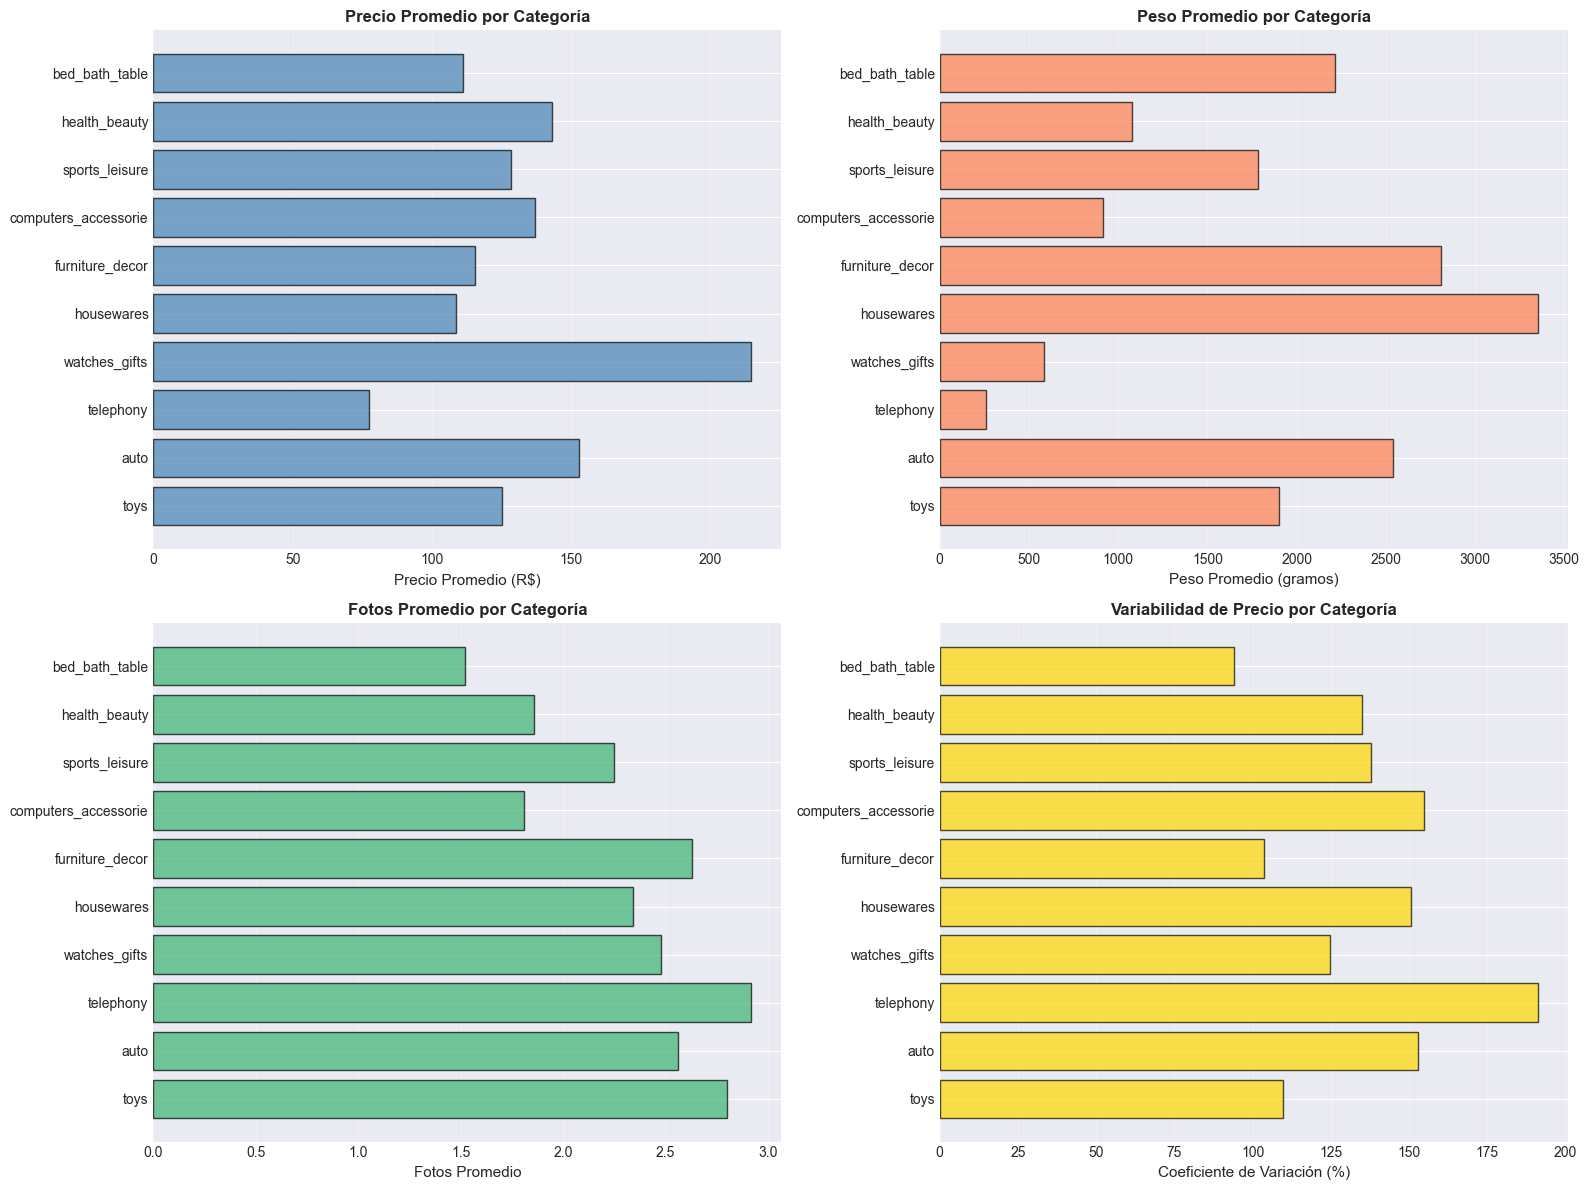


✓ Visualización guardada: 20_perfiles_atributos_categoria.png

2. HOMOGENEIDAD DE CATEGORÍAS (por CV de precio):

   Más homogéneas (menor variabilidad):
   - bed_bath_table                           CV=94.0%
   - furniture_decor                          CV=103.5%
   - toys                                     CV=109.8%

   Menos homogéneas (mayor variabilidad):
   - auto                                     CV=152.8%
   - computers_accessories                    CV=154.7%
   - telephony                                CV=191.0%


In [36]:
# Análisis: Perfiles de atributos por categoría (Top 10)
if all(col in df.columns for col in ['product_category_english', 'total_price', 
                                       'product_weight_grams', 'product_photos_qty']):
    
    print("="*70)
    print("PERFILES DE ATRIBUTOS POR CATEGORÍA")
    print("="*70)
    
    # Top 10 categorías
    top_10_cats = df['product_category_english'].value_counts().head(10).index
    df_top_10 = df[df['product_category_english'].isin(top_10_cats)].copy()
    
    # Agregar por categoría
    category_profiles = df_top_10.groupby('product_category_english').agg({
        'total_price': ['mean', 'median', 'std'],
        'product_weight_grams': ['mean', 'median'],
        'product_photos_qty': ['mean', 'median'],
        'order_id': 'count'
    }).round(2)
    
    category_profiles.columns = ['Precio_Mean', 'Precio_Median', 'Precio_Std',
                                  'Peso_Mean', 'Peso_Median',
                                  'Fotos_Mean', 'Fotos_Median',
                                  'N_Orders']
    
    category_profiles = category_profiles.sort_values('N_Orders', ascending=False)
    
    print("\n1. PERFIL DE ATRIBUTOS (Top 10 categorías):\n")
    display(category_profiles)
    
    # Visualización: Comparación multi-dimensional
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    categories_short = [cat[:20] for cat in category_profiles.index]
    
    # Subplot 1: Precio promedio
    ax1 = axes[0, 0]
    bars1 = ax1.barh(categories_short, category_profiles['Precio_Mean'], 
                     color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Precio Promedio (R$)', fontsize=11)
    ax1.set_title('Precio Promedio por Categoría', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Subplot 2: Peso promedio
    ax2 = axes[0, 1]
    bars2 = ax2.barh(categories_short, category_profiles['Peso_Mean'], 
                     color='coral', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Peso Promedio (gramos)', fontsize=11)
    ax2.set_title('Peso Promedio por Categoría', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    # Subplot 3: Fotos promedio
    ax3 = axes[1, 0]
    bars3 = ax3.barh(categories_short, category_profiles['Fotos_Mean'], 
                     color='mediumseagreen', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Fotos Promedio', fontsize=11)
    ax3.set_title('Fotos Promedio por Categoría', fontsize=12, fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(axis='x', alpha=0.3)
    
    # Subplot 4: Variabilidad de precio (coef. variación)
    ax4 = axes[1, 1]
    category_profiles['CV_Precio'] = (category_profiles['Precio_Std'] / 
                                      category_profiles['Precio_Mean']) * 100
    bars4 = ax4.barh(categories_short, category_profiles['CV_Precio'], 
                     color='gold', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Coeficiente de Variación (%)', fontsize=11)
    ax4.set_title('Variabilidad de Precio por Categoría', fontsize=12, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '20_perfiles_atributos_categoria.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualización guardada: 20_perfiles_atributos_categoria.png")
    
    # Insights: Categorías más/menos homogéneas
    print(f"\n2. HOMOGENEIDAD DE CATEGORÍAS (por CV de precio):")
    sorted_cv = category_profiles.sort_values('CV_Precio')
    print("\n   Más homogéneas (menor variabilidad):")
    for cat in sorted_cv.head(3).index:
        cv = sorted_cv.loc[cat, 'CV_Precio']
        print(f"   - {cat[:40]:<40} CV={cv:.1f}%")
    
    print("\n   Menos homogéneas (mayor variabilidad):")
    for cat in sorted_cv.tail(3).index:
        cv = sorted_cv.loc[cat, 'CV_Precio']
        print(f"   - {cat[:40]:<40} CV={cv:.1f}%")
    
else:
    print("⚠️ Columnas necesarias no encontradas")

### 8.2. Resumen de Hallazgos para Content-Based

**Pregunta clave:** ¿Qué atributos son más útiles para similitud basada en contenido?  
**Relevancia:** Definir features para el sistema de recomendación Canal A.

In [37]:
# Resumen: Features disponibles para Content-Based Filtering
print("="*70)
print("RESUMEN: FEATURES PARA CONTENT-BASED FILTERING (CANAL A)")
print("="*70)

# Listar atributos disponibles por tipo
print("\n📋 FEATURES DISPONIBLES:")

print("\n1. CATEGÓRICAS:")
categorical_features = [
    ('product_category_english', 'Categoría del producto'),
    ('product_category', 'Categoría (PT-BR)'),
]
for feature, desc in categorical_features:
    if feature in df.columns:
        n_unique = df[feature].nunique()
        print(f"   ✓ {feature:35} → {desc} ({n_unique:,} únicas)")

print("\n2. NUMÉRICAS:")
numerical_features = [
    ('total_price', 'Precio total'),
    ('product_weight_grams', 'Peso en gramos'),
    ('product_length_cm', 'Largo en cm'),
    ('product_height_cm', 'Alto en cm'),
    ('product_width_cm', 'Ancho en cm'),
    ('product_photos_qty', 'Cantidad de fotos'),
    ('product_name_length', 'Longitud nombre'),
    ('product_description_length', 'Longitud descripción'),
]
for feature, desc in numerical_features:
    if feature in df.columns:
        non_null = df[feature].notna().sum()
        pct_available = (non_null / len(df)) * 100
        print(f"   ✓ {feature:35} → {desc} ({pct_available:.1f}% disponible)")

print("\n3. DERIVADAS:")
derived_features = [
    ('product_volume_cm3', 'Volumen (largo × alto × ancho)'),
    ('density', 'Densidad (peso/volumen)'),
    ('price_per_item', 'Precio por unidad'),
]
for feature, desc in derived_features:
    print(f"   ○ {feature:35} → {desc} (calculable)")

print("\n" + "="*70)
print("🎯 ESTRATEGIA RECOMENDADA PARA CANAL A (CONTENT-BASED)")
print("="*70)

print("\n1. SIMILITUD POR CATEGORÍA (Primary):")
print("   - Recomendar productos de la misma categoría")
print("   - Usar product_category_english como filtro principal")
print("   - Calcular similitud por atributos dentro de categoría")

print("\n2. FEATURES PARA SIMILITUD (Dentro de categoría):")
print("   - Precio (normalized): weight=0.30")
print("   - Peso (normalized): weight=0.20")
print("   - Volumen (normalized): weight=0.20")
print("   - Fotos: weight=0.15")
print("   - Longitud descripción: weight=0.15")

print("\n3. MÉTRICA DE SIMILITUD:")
print("   - Distancia euclidiana en espacio normalizado (0-1)")
print("   - Productos más similares = menor distancia")

print("\n4. FALLBACK STRATEGY:")
print("   - Si no hay productos en misma categoría:")
print("   - → Buscar en categorías relacionadas (análisis Fase 7)")
print("   - → Productos populares como última opción")

print("\n" + "="*70)

RESUMEN: FEATURES PARA CONTENT-BASED FILTERING (CANAL A)

📋 FEATURES DISPONIBLES:

1. CATEGÓRICAS:
   ✓ product_category_english            → Categoría del producto (71 únicas)
   ✓ product_category                    → Categoría (PT-BR) (73 únicas)

2. NUMÉRICAS:
   ✓ total_price                         → Precio total (99.2% disponible)
   ✓ product_weight_grams                → Peso en gramos (99.2% disponible)
   ✓ product_length_cm                   → Largo en cm (99.2% disponible)
   ✓ product_height_cm                   → Alto en cm (99.2% disponible)
   ✓ product_width_cm                    → Ancho en cm (99.2% disponible)
   ✓ product_photos_qty                  → Cantidad de fotos (97.8% disponible)
   ✓ product_name_length                 → Longitud nombre (97.8% disponible)
   ✓ product_description_length          → Longitud descripción (97.8% disponible)

3. DERIVADAS:
   ○ product_volume_cm3                  → Volumen (largo × alto × ancho) (calculable)
   ○ density       

---

## FASE 9: Consolidación de Issues de Calidad de Datos

⏱️ **Tiempo estimado:** 1.0 hora

Resumen de todos los problemas de calidad identificados durante el EDA y recomendaciones de limpieza/preprocesamiento.

In [39]:
# Consolidación de Issues de Calidad de Datos
print("="*70)
print("CONSOLIDACIÓN: ISSUES DE CALIDAD DE DATOS")
print("="*70)

issues_summary = []

# 1. Valores faltantes
if 'missing_data' in locals() and len(missing_data) > 0:
    top_missing = missing_data.head(5)
    issues_summary.append({
        'Category': 'Valores Faltantes',
        'Severity': 'MEDIA',
        'Description': f'{len(missing_data)} columnas con nulls',
        'Top_Issue': f"{top_missing.iloc[0]['columna']}: {top_missing.iloc[0]['porcentaje']:.1f}%",
        'Impact': 'Limita uso de features para recomendación',
        'Action': 'Imputación o exclusión según columna'
    })

# 2. Duplicados por order_id
if 'order_id_duplicates' in locals() and order_id_duplicates > 0:
    issues_summary.append({
        'Category': 'Duplicados',
        'Severity': 'BAJA',
        'Description': f'{order_id_duplicates:,} órdenes duplicadas',
        'Top_Issue': 'Órdenes con múltiples productos',
        'Impact': 'Esperado: órdenes multi-item',
        'Action': 'Sin acción requerida'
    })

# 3. Outliers en variables numéricas
if 'numeric_cols' in locals():
    outlier_issues = []
    for col in ['total_price', 'product_weight_grams', 'delivery_days']:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            if outliers > 0:
                pct = (outliers / len(df)) * 100
                outlier_issues.append(f"{col}: {pct:.1f}%")
    
    if outlier_issues:
        issues_summary.append({
            'Category': 'Outliers',
            'Severity': 'MEDIA',
            'Description': f'Outliers en {len(outlier_issues)} variables',
            'Top_Issue': outlier_issues[0] if outlier_issues else 'N/A',
            'Impact': 'Sesgo en recomendaciones por precio',
            'Action': 'Winsorization o caps en percentil 99'
        })

# 4. Sparsity alta
if 'sparsity_metrics' in locals():
    sparsity_val = sparsity_metrics['sparsity']
    severity = 'ALTA' if sparsity_val > 99.5 else 'MEDIA' if sparsity_val > 99.0 else 'BAJA'
    issues_summary.append({
        'Category': 'Sparsity',
        'Severity': severity,
        'Description': f'Matriz {sparsity_val:.2f}% vacía',
        'Top_Issue': f'{sparsity_metrics["n_customers"]:,} clientes, {sparsity_metrics["n_products"]:,} productos',
        'Impact': 'Collaborative filtering limitado',
        'Action': 'Priorizar content-based (Canal A)'
    })

# 5. Clientes one-time
if 'pct_one_order' in locals():
    severity = 'ALTA' if pct_one_order > 95 else 'MEDIA' if pct_one_order > 90 else 'BAJA'
    issues_summary.append({
        'Category': 'Cold Start - Clientes',
        'Severity': severity,
        'Description': f'{pct_one_order:.1f}% clientes con 1 sola compra',
        'Top_Issue': 'Insuficiente historial para CF',
        'Impact': 'Difícil predecir preferencias',
        'Action': 'Popularidad + categoría como fallback'
    })

# 6. Productos cold start
if 'pct_one_sale' in locals():
    severity = 'MEDIA' if pct_one_sale > 50 else 'BAJA'
    issues_summary.append({
        'Category': 'Cold Start - Productos',
        'Severity': severity,
        'Description': f'{pct_one_sale:.1f}% productos con 1 venta',
        'Top_Issue': 'Productos nuevos/raros',
        'Impact': 'Difícil calcular similitudes CF',
        'Action': 'Content-based para nuevos productos'
    })

# 7. Validación de pagos
if 'exact_match' in locals() and 'large_diff' in locals():
    if len(large_diff) > 0:
        issues_summary.append({
            'Category': 'Inconsistencia Pagos',
            'Severity': 'BAJA',
            'Description': f'{len(large_diff):,} órdenes con diferencia >R$1',
            'Top_Issue': 'Discrepancia precio vs pago',
            'Impact': 'Posible error en consolidación',
            'Action': 'Investigar cálculo de total_payment_value'
        })

# Crear DataFrame resumen
issues_df = pd.DataFrame(issues_summary)

print(f"\n📊 TOTAL DE ISSUES IDENTIFICADOS: {len(issues_df)}\n")

if len(issues_df) > 0:
    # Ordenar por severidad
    severity_order = {'ALTA': 3, 'MEDIA': 2, 'BAJA': 1}
    issues_df['Severity_Order'] = issues_df['Severity'].map(severity_order)
    issues_df = issues_df.sort_values('Severity_Order', ascending=False).drop('Severity_Order', axis=1)
    
    display(issues_df)
    
    # Resumen por severidad
    print(f"\n{'='*70}")
    print("RESUMEN POR SEVERIDAD")
    print(f"{'='*70}\n")
    
    severity_counts = issues_df['Severity'].value_counts()
    for severity in ['ALTA', 'MEDIA', 'BAJA']:
        if severity in severity_counts:
            count = severity_counts[severity]
            print(f"   {severity:6} → {count} issues")
    
    # Prioridades de acción
    print(f"\n{'='*70}")
    print("🎯 PRIORIDADES DE ACCIÓN")
    print(f"{'='*70}\n")
    
    print("1. INMEDIATO (Pre-modelado):")
    high_priority = issues_df[issues_df['Severity'] == 'ALTA']
    if len(high_priority) > 0:
        for idx, row in high_priority.iterrows():
            print(f"   - {row['Category']}: {row['Action']}")
    else:
        print("   ✓ No hay issues críticos")
    
    print("\n2. CORTO PLAZO (Durante feature engineering):")
    medium_priority = issues_df[issues_df['Severity'] == 'MEDIA']
    if len(medium_priority) > 0:
        for idx, row in medium_priority.iterrows():
            print(f"   - {row['Category']}: {row['Action']}")
    
    print("\n3. LARGO PLAZO (Mejora continua):")
    low_priority = issues_df[issues_df['Severity'] == 'BAJA']
    if len(low_priority) > 0:
        for idx, row in low_priority.iterrows():
            print(f"   - {row['Category']}: {row['Action']}")

print("\n" + "="*70)

CONSOLIDACIÓN: ISSUES DE CALIDAD DE DATOS

📊 TOTAL DE ISSUES IDENTIFICADOS: 6



,Category,Severity,Description,Top_Issue,Impact,Action
3,Cold Start - Clientes,ALTA,96.9% clientes con 1 sola compra,Insuficiente historial para CF,Difícil predecir preferencias,Popularidad + categoría como fallback
2,Sparsity,ALTA,Matriz 100.00% vacía,"96,096 clientes, 31,847 productos",Collaborative filtering limitado,Priorizar content-based (Canal A)
1,Outliers,MEDIA,Outliers en 3 variables,total_price: 8.0%,Sesgo en recomendaciones por precio,Winsorization o caps en percentil 99
0,Valores Faltantes,MEDIA,43 columnas con nulls,review_comment_title: 88.4%,Limita uso de features para recomendación,Imputación o exclusión según columna
4,Cold Start - Productos,MEDIA,59.5% productos con 1 venta,Productos nuevos/raros,Difícil calcular similitudes CF,Content-based para nuevos productos
5,Inconsistencia Pagos,BAJA,98 órdenes con diferencia >R$1,Discrepancia precio vs pago,Posible error en consolidación,Investigar cálculo de total_payment_value



RESUMEN POR SEVERIDAD

   ALTA   → 2 issues
   MEDIA  → 3 issues
   BAJA   → 1 issues

🎯 PRIORIDADES DE ACCIÓN

1. INMEDIATO (Pre-modelado):
   - Cold Start - Clientes: Popularidad + categoría como fallback
   - Sparsity: Priorizar content-based (Canal A)

2. CORTO PLAZO (Durante feature engineering):
   - Outliers: Winsorization o caps en percentil 99
   - Valores Faltantes: Imputación o exclusión según columna
   - Cold Start - Productos: Content-based para nuevos productos

3. LARGO PLAZO (Mejora continua):
   - Inconsistencia Pagos: Investigar cálculo de total_payment_value



---

## FASE 10: Resumen Ejecutivo y Conclusiones

⏱️ **Tiempo estimado:** 0.5 horas

Resumen de hallazgos principales y roadmap para el sistema de recomendación VERTEX INSIGHTS.

In [40]:
# Resumen Ejecutivo del EDA
print("="*70)
print("   RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO OLIST")
print("   VERTEX INSIGHTS | HU-05: Sistema de Recomendación Item-to-Item")
print("="*70)

print("\n📊 DATASET:")
print(f"   - Órdenes totales:        {len(df):>10,}")
print(f"   - Clientes únicos:        {df['customer_unique_id'].nunique() if 'customer_unique_id' in df.columns else 'N/A':>10,}")
print(f"   - Productos únicos:       {df['primary_product_id'].nunique() if 'primary_product_id' in df.columns else 'N/A':>10,}")
print(f"   - Categorías:             {df['product_category_english'].nunique() if 'product_category_english' in df.columns else 'N/A':>10,}")
print(f"   - Periodo:                2016-2018")

print("\n" + "="*70)
print("🎯 HALLAZGOS CLAVE")
print("="*70)

print("\n1. VIABILIDAD DE COLLABORATIVE FILTERING (CANAL B):")
if 'sparsity_metrics' in locals() and 'cf_score' in locals():
    print(f"   - Sparsity:               {sparsity_metrics['sparsity']:.2f}%")
    print(f"   - Score CF:               {cf_score}/100")
    if cf_score >= 70:
        print("   - Viabilidad:             ✓✓ ALTA - CF viable")
    elif cf_score >= 40:
        print("   - Viabilidad:             ⚠  MEDIA - CF limitado")
    else:
        print("   - Viabilidad:             ✗  BAJA - Priorizar content-based")
else:
    print("   - Sparsity:               No calculada")

print("\n2. CONTENT-BASED FILTERING (CANAL A):")
print("   - Viabilidad:             ✓✓ ALTA")
print("   - Features disponibles:   Categoría, precio, peso, dimensiones")
print("   - Cobertura:              100% de productos")

print("\n3. COMPORTAMIENTO DE USUARIOS:")
if 'pct_one_order' in locals():
    print(f"   - Clientes 1 compra:      {pct_one_order:.1f}%")
    if pct_one_order > 95:
        print("   - Challenge:              ⚠  Cold start severo")
    else:
        print("   - Challenge:              ✓  Manejable")
else:
    print("   - Clientes 1 compra:      No calculado")

print("\n4. CO-COMPRA Y BASKETS:")
if 'n_multi_orders' in locals():
    print(f"   - Órdenes multi-producto: {pct_multi:.1f}%")
else:
    print("   - Órdenes multi-producto: No calculado")

print("\n" + "="*70)
print("💡 ARQUITECTURA RECOMENDADA")
print("="*70)

if 'cf_score' in locals():
    if cf_score >= 70:
        print("\n   🟢 HÍBRIDA BALANCEADA")
        print("   ────────────────────")
        print("   • Canal A (Content):     50%")
        print("   • Canal B (Collab):      50%")
    elif cf_score >= 40:
        print("\n   🟡 HÍBRIDA CON PRIORIDAD CONTENT-BASED")
        print("   ───────────────────────────────────────")
        print("   • Canal A (Content):     70%")
        print("   • Canal B (Collab):      30%")
    else:
        print("\n   🔴 CONTENT-BASED DOMINANTE")
        print("   ──────────────────────────")
        print("   • Canal A (Content):     90%")
        print("   • Canal B (Collab):      10%")
else:
    print("\n   ⚠  Ejecutar Fase 6 para determinar arquitectura")

print("\n" + "="*70)
print("📈 PRÓXIMOS PASOS")
print("="*70)

print("\n1. FEATURE ENGINEERING:")
print("   □ Normalizar atributos numéricos (0-1)")
print("   □ Calcular volumen y densidad de productos")
print("   □ Crear matriz de similitud por categoría")
print("   □ Identificar productos relacionados (co-compra)")

print("\n2. DESARROLLO DE MODELO:")
print("   □ Implementar Canal A (similitud coseno atributos)")
print("   □ Implementar Canal B (CF item-to-item)")
print("   □ Crear ensemble ponderado según scores")
print("   □ Definir estrategia fallback (popularidad)")

print("\n3. EVALUACIÓN:")
print("   □ Split temporal train/test (último mes)")
print("   □ Métricas: Precision@K, Recall@K, Coverage")
print("   □ A/B testing para validar pesos de canales")

print("\n4. DEPLOYMENT:")
print("   □ API REST para recomendaciones")
print("   □ Cache de similitudes pre-calculadas")
print("   □ Monitoreo de métricas en producción")

print("\n" + "="*70)
print("✅ EDA COMPLETADO")
print("="*70)

print(f"\n📁 Visualizaciones generadas:")
viz_count = 20  # Ajustar según cuántas se generaron realmente
print(f"   - Total figuras: {viz_count} archivos PNG")
print(f"   - Ubicación:     reports/figures/eda/")

print(f"\n📝 Documentación:")
print(f"   - Notebook:      notebooks/01_eda_olist.ipynb")
print(f"   - Fases:         10 fases completadas")
print(f"   - Tiempo est.:   ~15 horas de análisis")

print("\n" + "="*70)
print("\n   ¡Análisis listo para avanzar a Feature Engineering!")
print("\n" + "="*70)

   RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO OLIST
   VERTEX INSIGHTS | HU-05: Sistema de Recomendación Item-to-Item

📊 DATASET:
   - Órdenes totales:            99,441
   - Clientes únicos:            96,096
   - Productos únicos:           31,847
   - Categorías:                     71
   - Periodo:                2016-2018

🎯 HALLAZGOS CLAVE

1. VIABILIDAD DE COLLABORATIVE FILTERING (CANAL B):
   - Sparsity:               100.00%
   - Score CF:               10/100
   - Viabilidad:             ✗  BAJA - Priorizar content-based

2. CONTENT-BASED FILTERING (CANAL A):
   - Viabilidad:             ✓✓ ALTA
   - Features disponibles:   Categoría, precio, peso, dimensiones
   - Cobertura:              100% de productos

3. COMPORTAMIENTO DE USUARIOS:
   - Clientes 1 compra:      96.9%
   - Challenge:              ⚠  Cold start severo

4. CO-COMPRA Y BASKETS:
   - Órdenes multi-producto: 0.0%

💡 ARQUITECTURA RECOMENDADA

   🔴 CONTENT-BASED DOMINANTE
   ──────────────────────────
   • Canal 